In [ ]:
from typing import Sequence
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import flax.linen as nn
import numpy as np
import matplotlib.pyplot as plt
import optax
from flax.nnx import split, merge
import yaml
from pathlib import Path

from lhf import *

path = Path("../configs/config.yaml")
with path.open("r") as f:
    config = yaml.safe_load(f)

logger = Logger(
    log_dir="../logs/new_run",
    config=config
)

key = jax.random.PRNGKey(config["seed"])

In [ ]:
base_p = TaskParams(
    alpha = config["base_manifold"]["alpha"],
    beta = config["base_manifold"]["beta"],
    gamma = config["base_manifold"]["gamma"]
)

target_p = TaskParams(
    alpha = config["target_manifold"]["alpha"],
    beta = config["target_manifold"]["beta"],
    gamma = config["target_manifold"]["gamma"]
)

task_vis = ManifoldVisualizer(ylim=(-1,5))

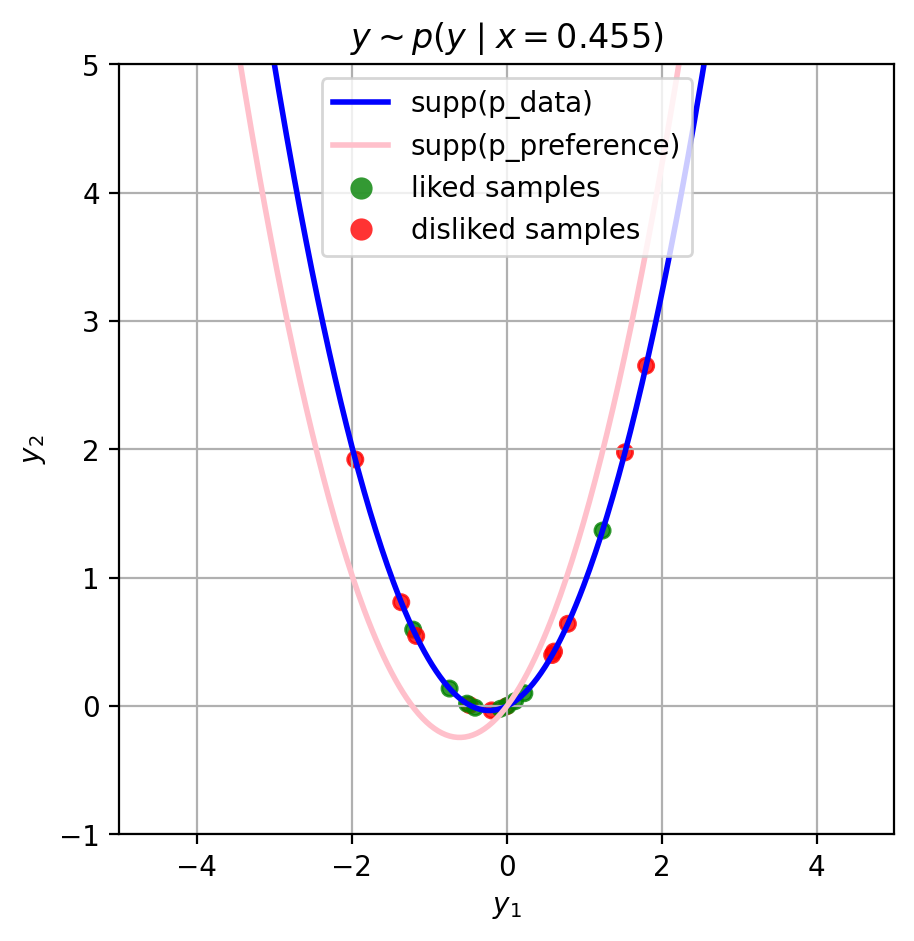

In [ ]:
n_queries = config["n_queries"]
n_internal = config["n_internal"]
m = config["m"]
tau = config["tau"]

(
    key,
    x_key,
    y_key,
    l_key
) = jax.random.split(key, 4)

x = jax.random.uniform(x_key, shape=(n_internal,1), minval=-1, maxval=1)
xs = jnp.broadcast_to(
    x[:,None,:],
    (n_internal, m, 1)
)   # (B,m,1)

logger.log_data(np.array(xs), "xs.npy")

vmapped_sample_manifold = jax.vmap(
    sample_manifold,
    in_axes=(0,1,None,None,None),
    out_axes=1
)
y_keys = jax.random.split(y_key, (m,))
ys = vmapped_sample_manifold(
    y_keys,
    xs,
    base_p.alpha,
    base_p.beta,
    base_p.gamma,
)   # (B,m,2)

gt_logits = logpdf_labels(
    xs,
    ys,
    alpha=target_p.alpha,
    beta=target_p.beta,
    gamma=target_p.gamma,
    tau=tau
)
# Sample labels
gt_labels = jax.random.categorical(
    l_key,
    gt_logits,
    axis=-1
)

fig = task_vis.visualize(
    xs[0,0,0],
    ys[0],
    base_manifold=base_p,
    target_manifold=target_p,
    labels=gt_labels[0]
)
logger.log_data(fig, Path("base") / "vis.png")

In [ ]:
num_iter = config["num_iter"]

# Logging:
gt_u_history = []
y_history = []
ys_tot = None
x_tot = None
l_tot = None
l_history = []

# Step 1: Pre-training
pre_train_epochs = config["pre_train_epochs"]
pre_train_lr = config["pre_train_lr"]
clip_norm = config["clip_norm"]
pre_train_batch_dim = config["pre_train_batch_dim"]
sigma_y_0 = config["sigma_y_0"]
sigma_y_T = config["sigma_y_T"]

(
    key,
    x_key,
    y_key,
    init_key,
    ys_key
) = jax.random.split(key, 5)

pre_train_features = config["pre_train_features"]
pre_train_n_features = len(pre_train_features)
d_z=config["d_z"]
d_y=config["d_y"]

encoder_mlp = MLP(
    features=pre_train_features,
    output_dim=d_z + (d_z*(d_z+1)) // 2,
    kernel_inits=[jax.nn.initializers.normal(1e-2)] * pre_train_n_features,
    bias_inits=[jax.nn.initializers.zeros] * pre_train_n_features
)
decoder_mlp = MLP(
    features=pre_train_features,
    output_dim=d_y,
    kernel_inits=[jax.nn.initializers.normal(1e-2)] * pre_train_n_features,
    bias_inits=[jax.nn.initializers.zeros] * pre_train_n_features
)

gen_model = ConditionalVAE(
    encoder=encoder_mlp,
    decoder=decoder_mlp,
    d_z=d_z,
    d_y=d_y
)
x_batch = xs[:pre_train_batch_dim,0]  # (B,1)
y_batch = ys[:pre_train_batch_dim,0]  # (B,2)

xz_batch = jnp.concatenate(
    [x_batch, jnp.zeros((pre_train_batch_dim,1))],
    axis=-1
)
xy_batch = jnp.concatenate(
    [x_batch, y_batch],
    axis=-1
)

vae_params = {
    "encoder": encoder_mlp.init(init_key, xy_batch),
    "decoder": decoder_mlp.init(init_key, xz_batch)
}
logger.log_data(vae_params, "base/vae_params.npz")

def pre_train_loss_fn(params, step, key, x, y):
        return -jnp.mean(
            gen_model.elbo(
                params,
                x,
                y,
                key,
                sigma_y=sigma_y_0 + (sigma_y_T - sigma_y_0)*(step+1)/pre_train_epochs,
            )
        )

@jax.jit
def pre_train_step(params, step, opt_state, key, x, y):
    loss, grads = jax.value_and_grad(pre_train_loss_fn)(params, step, key, x, y)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def sample_many(params, key, x, m):
    keys = jax.random.split(key, m)
    return jax.vmap(
        lambda k: gen_model.sample(
            params,
            x,                     # (B, 1)
            k,
            sigma_y=sigma_y_T,
            deterministic=False,
        ),
        out_axes=1,
    )(keys)

# Step 2: Learn preference model
pref_lr = config["pref_lr"]
pref_batch_dim = config["pref_batch_dim"]
pref_train_epochs = config["pref_train_epochs"]

(
    key,
    init_key,
    l_key,
    gt_l_key
) = jax.random.split(key, 4)

mlp = MLP(
    features=config["pref_model_features"],
    output_dim=1
)

init_batch = jnp.zeros((pref_batch_dim, m, 2))
pref_params = {
    "y2_fn": mlp.init(init_key, init_batch),
}
logger.log_data(pref_params, "base/pref_params.npz")

y2_learned = lambda p, x, y1: mlp.apply(p, jnp.concatenate([x,y1], axis=2))

pref_model = PrefModel(
    y2_fn = y2_learned
)

def pref_nll(params, x, y, labels):
    logpdf = pref_model.logpdf(params, x, y, tau=tau)      # (B, m, 2)

    # Gather log-probabilities of the observed labels
    logp = jnp.take_along_axis(
        logpdf,
        labels[..., None],     # (B, m, 1)
        axis=-1,
    )[..., 0]                  # (B, m)

    return -jnp.mean(logp)

@jax.jit
def pref_train_step(params, opt_state, x, y, labels):
    loss, grads = jax.value_and_grad(pref_nll)(
        params,
        x,
        y,
        labels,
    )
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# Step 3: Improve VAE
align_lr = config["align_lr"]
align_batch_dim = config["align_batch_dim"]
align_epochs = config["align_epochs"]
beta = config["beta"]

def avg_u(params, key, y2_params, x, sigma_y):
    y = gen_model.sample(
        params,
        x,
        key,
        sigma_y=sigma_y,
        deterministic=False
    )      # (B, m, 2)

    y1 = y[:, None, 0][...,None]
    y2 = y[:, None, 1][...,None]
    y2_hat = y2_learned(y2_params, x[:, None, :], y1)
    u = -(y2 - y2_hat)**2

    return jnp.mean(u)

def kl_div(params, base_vae_params, key, x, sigma_y):
    kl = gen_model.d_kl(
        params,
        base_vae_params,
        x,
        key,
        sigma_y=sigma_y
    )

    return jnp.mean(kl)

def disp(params, x, key, n_z=8):
    d = gen_model.dispersion(
        params,
        x,
        key,
        n_z=n_z
    )
    return jnp.mean(d)

@jax.jit
def align_loss(params, base_vae_params, y2_params, key, x, sigma_y):
    u_bar = avg_u(
        params,
        key, 
        y2_params,
        x,
        sigma_y
    )
    kl = kl_div(
        params,
        base_vae_params,
        key,
        x,
        sigma_y
    )
    if config["use_dispersion_loss"]:
        gamma = config["gamma"]
        dispersion = disp(
            params,
            x,
            key,
            n_z=config["disp_samples"]
        )
        loss = -u_bar + beta * kl - gamma * jnp.log(dispersion)
    else:
        loss = -u_bar + beta * kl

    return loss

@jax.jit
def align_train_step(params, base_vae_params, y2_params, opt_state, key, x, sigma_y):
    loss, grads = jax.value_and_grad(align_loss)(
        params,
        base_vae_params,
        y2_params,
        key,
        x,
        sigma_y
    )
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

vmapped_vae_sample = jax.vmap(
    gen_model.sample,
    in_axes=(None, 1, 0),
    out_axes=1
)

[1/4000] -ELBO = 3.1325700283050537
[2/4000] -ELBO = 3.132033586502075
[3/4000] -ELBO = 3.131451368331909
[4/4000] -ELBO = 3.130791187286377
[5/4000] -ELBO = 3.129995584487915
[6/4000] -ELBO = 3.1290056705474854
[7/4000] -ELBO = 3.1278607845306396
[8/4000] -ELBO = 3.126481771469116
[9/4000] -ELBO = 3.1248409748077393
[10/4000] -ELBO = 3.1229631900787354
[11/4000] -ELBO = 3.1207785606384277
[12/4000] -ELBO = 3.118242025375366
[13/4000] -ELBO = 3.1154046058654785
[14/4000] -ELBO = 3.1120619773864746
[15/4000] -ELBO = 3.1084835529327393
[16/4000] -ELBO = 3.104551076889038
[17/4000] -ELBO = 3.1001369953155518
[18/4000] -ELBO = 3.0953526496887207
[19/4000] -ELBO = 3.0902795791625977
[20/4000] -ELBO = 3.084679126739502
[21/4000] -ELBO = 3.0789389610290527
[22/4000] -ELBO = 3.0730457305908203
[23/4000] -ELBO = 3.0674617290496826
[24/4000] -ELBO = 3.061933994293213
[25/4000] -ELBO = 3.056514024734497
[26/4000] -ELBO = 3.0518951416015625
[27/4000] -ELBO = 3.048356533050537
[28/4000] -ELBO = 3.0

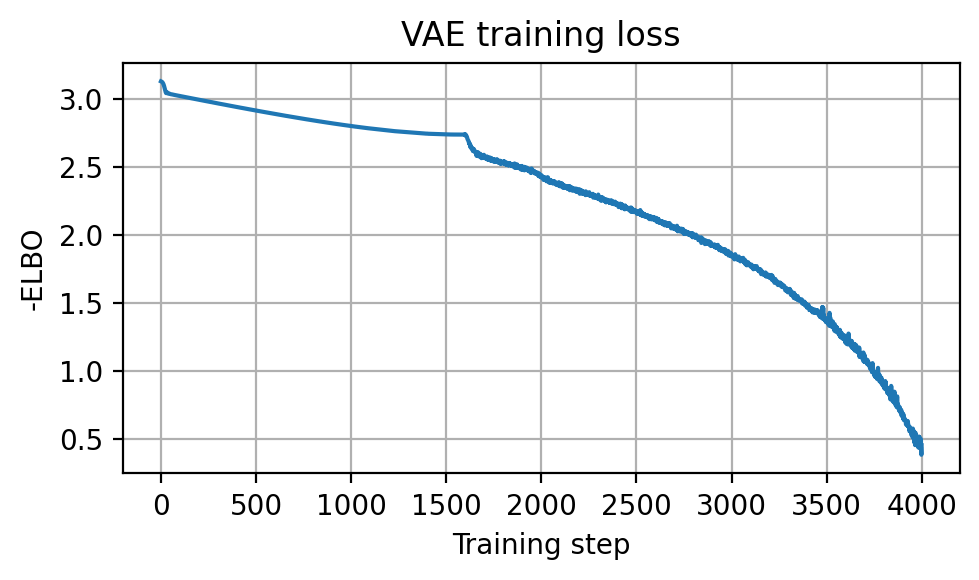

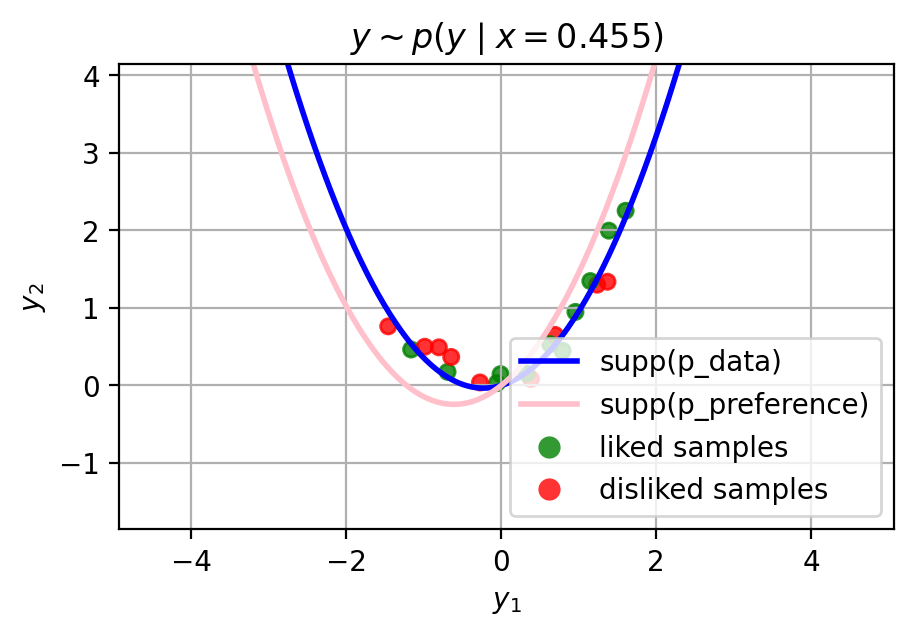

[1/2000] NLL = 0.9773
[2/2000] NLL = 0.8141
[3/2000] NLL = 0.7830
[4/2000] NLL = 0.7678
[5/2000] NLL = 0.7328
[6/2000] NLL = 0.7222
[7/2000] NLL = 0.7256
[8/2000] NLL = 0.7163
[9/2000] NLL = 0.7339
[10/2000] NLL = 0.7182
[11/2000] NLL = 0.7256
[12/2000] NLL = 0.7189
[13/2000] NLL = 0.7208
[14/2000] NLL = 0.7054
[15/2000] NLL = 0.7079
[16/2000] NLL = 0.7088
[17/2000] NLL = 0.7095
[18/2000] NLL = 0.7057
[19/2000] NLL = 0.7029
[20/2000] NLL = 0.7005
[21/2000] NLL = 0.7016
[22/2000] NLL = 0.7032
[23/2000] NLL = 0.7129
[24/2000] NLL = 0.7029
[25/2000] NLL = 0.7014
[26/2000] NLL = 0.7070
[27/2000] NLL = 0.7112
[28/2000] NLL = 0.7050
[29/2000] NLL = 0.6983
[30/2000] NLL = 0.6941
[31/2000] NLL = 0.6919
[32/2000] NLL = 0.7016
[33/2000] NLL = 0.7052
[34/2000] NLL = 0.6983
[35/2000] NLL = 0.6961
[36/2000] NLL = 0.6973
[37/2000] NLL = 0.6968
[38/2000] NLL = 0.6960
[39/2000] NLL = 0.7018
[40/2000] NLL = 0.7036
[41/2000] NLL = 0.6958
[42/2000] NLL = 0.6973
[43/2000] NLL = 0.6953
[44/2000] NLL = 0.70

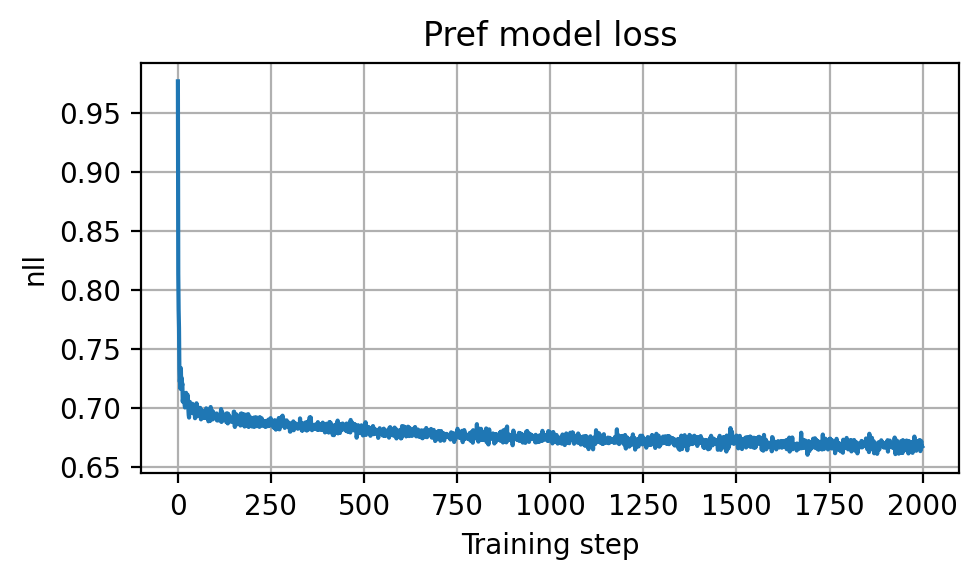

Dataset composition (likes/dislikes):   0.5055999755859375 / 0.4944000244140625
ACC(learned vs GT):   0.9319499731063843 / 0.5170199871063232


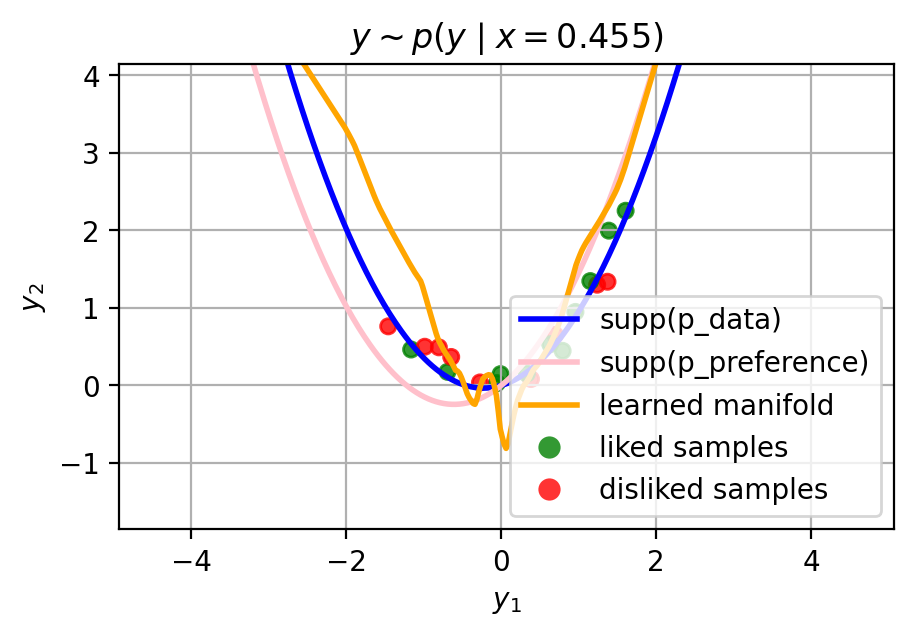

[1/1000] loss = -6.0229
[2/1000] loss = -8.4268
[3/1000] loss = -10.9175
[4/1000] loss = -13.2669
[5/1000] loss = -15.5020
[6/1000] loss = -17.5137
[7/1000] loss = -19.7663
[8/1000] loss = -21.5655
[9/1000] loss = -23.2987
[10/1000] loss = -24.6957
[11/1000] loss = -26.1272
[12/1000] loss = -27.5273
[13/1000] loss = -28.5957
[14/1000] loss = -29.6166
[15/1000] loss = -30.4319
[16/1000] loss = -30.8050
[17/1000] loss = -31.1677
[18/1000] loss = -31.0244
[19/1000] loss = -31.3477
[20/1000] loss = -31.6963
[21/1000] loss = -31.6051
[22/1000] loss = -31.9970
[23/1000] loss = -32.6825
[24/1000] loss = -32.4457
[25/1000] loss = -32.7383
[26/1000] loss = -33.5379
[27/1000] loss = -34.0417
[28/1000] loss = -33.7893
[29/1000] loss = -34.7378
[30/1000] loss = -34.9738
[31/1000] loss = -34.6918
[32/1000] loss = -35.4689
[33/1000] loss = -34.8861
[34/1000] loss = -35.2642
[35/1000] loss = -36.0540
[36/1000] loss = -35.5892
[37/1000] loss = -35.0547
[38/1000] loss = -35.5258
[39/1000] loss = -35.99

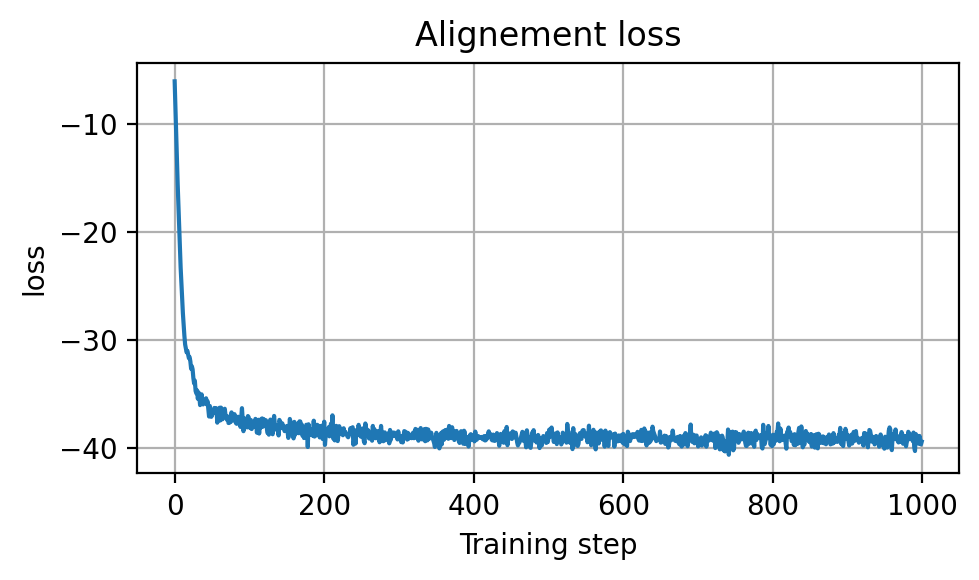

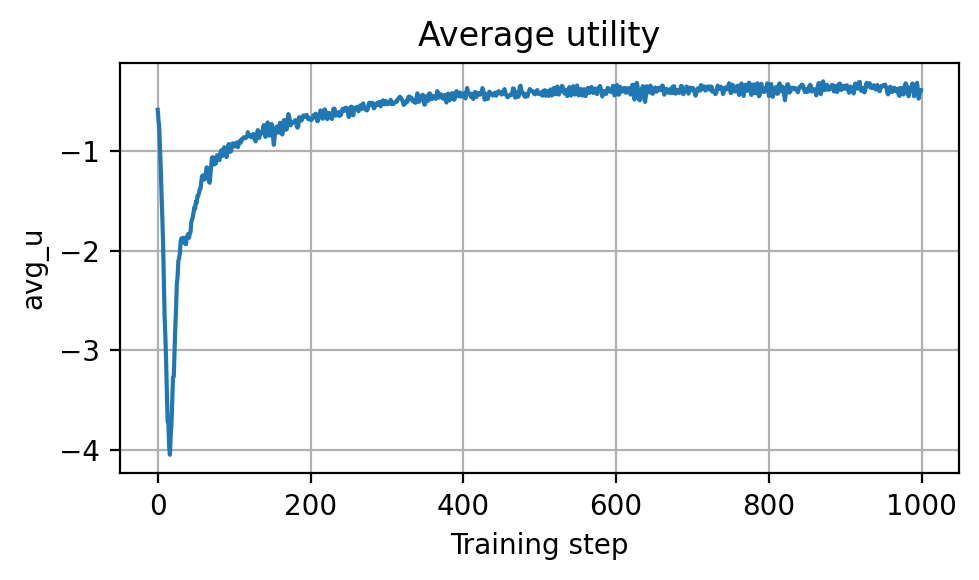

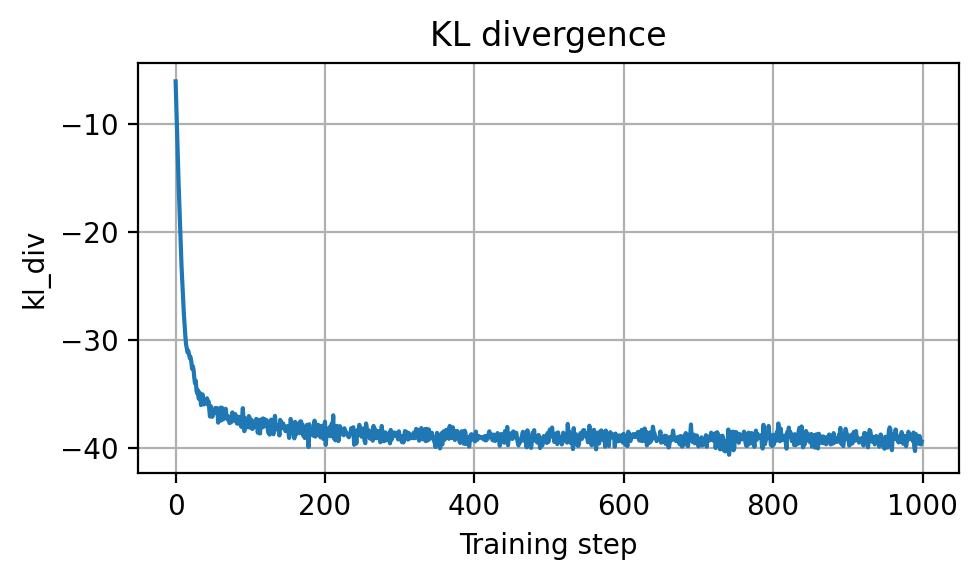

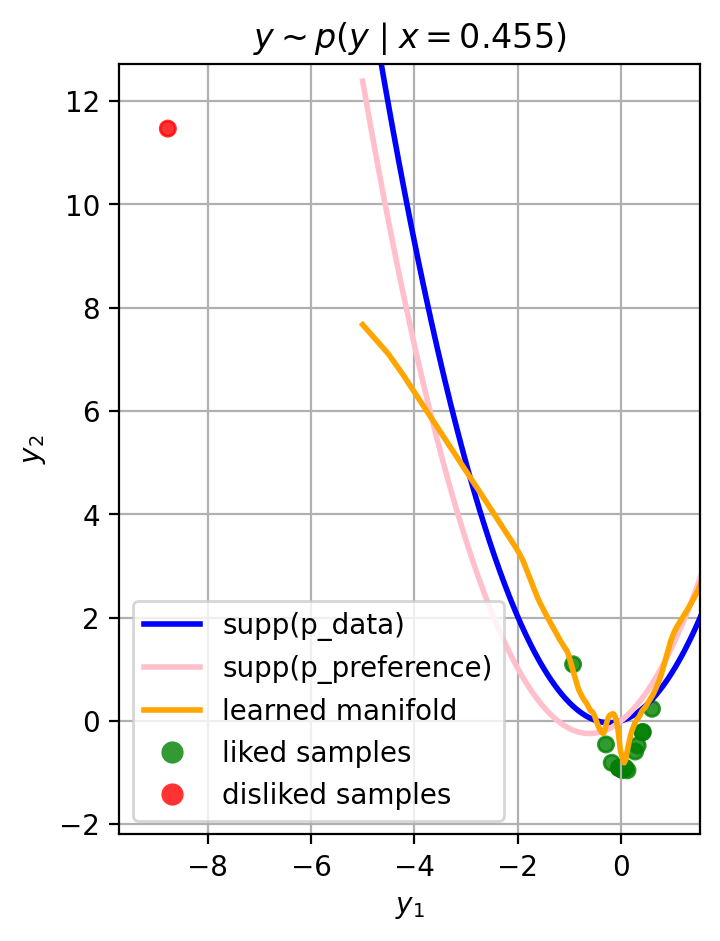

[1/4000] -ELBO = 201.8950958251953
[2/4000] -ELBO = 143.99867248535156
[3/4000] -ELBO = 101.83899688720703
[4/4000] -ELBO = 72.17645263671875
[5/4000] -ELBO = 51.95060348510742
[6/4000] -ELBO = 38.315059661865234
[7/4000] -ELBO = 29.224306106567383
[8/4000] -ELBO = 23.097116470336914
[9/4000] -ELBO = 18.916866302490234
[10/4000] -ELBO = 16.141969680786133
[11/4000] -ELBO = 14.064647674560547
[12/4000] -ELBO = 12.249795913696289
[13/4000] -ELBO = 10.656362533569336
[14/4000] -ELBO = 9.471460342407227
[15/4000] -ELBO = 9.008221626281738
[16/4000] -ELBO = 9.09957504272461
[17/4000] -ELBO = 9.41248607635498
[18/4000] -ELBO = 9.518099784851074
[19/4000] -ELBO = 9.380742073059082
[20/4000] -ELBO = 9.018287658691406
[21/4000] -ELBO = 8.572591781616211
[22/4000] -ELBO = 8.127554893493652
[23/4000] -ELBO = 7.7759294509887695
[24/4000] -ELBO = 7.448313236236572
[25/4000] -ELBO = 7.113375663757324
[26/4000] -ELBO = 6.814039707183838
[27/4000] -ELBO = 6.560369491577148
[28/4000] -ELBO = 6.35792779

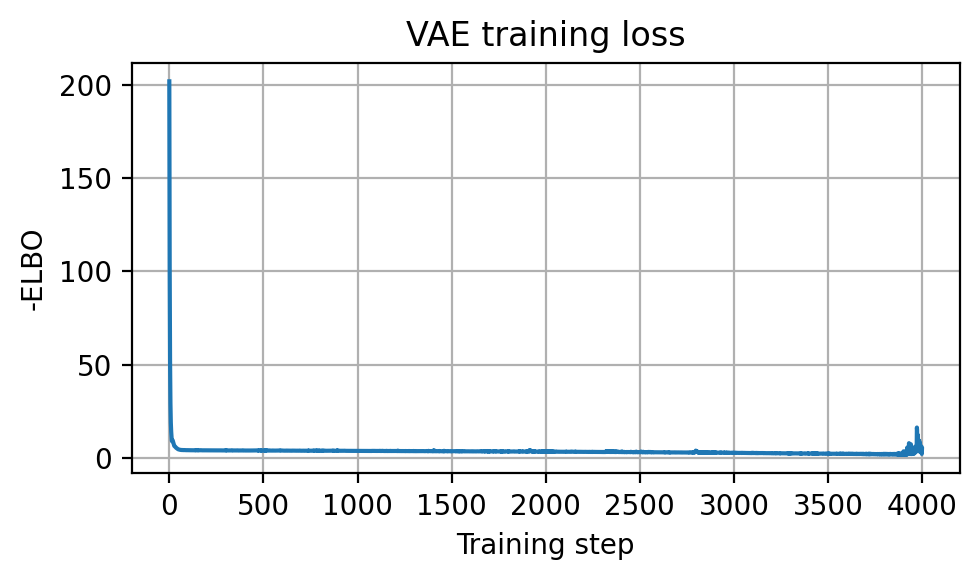

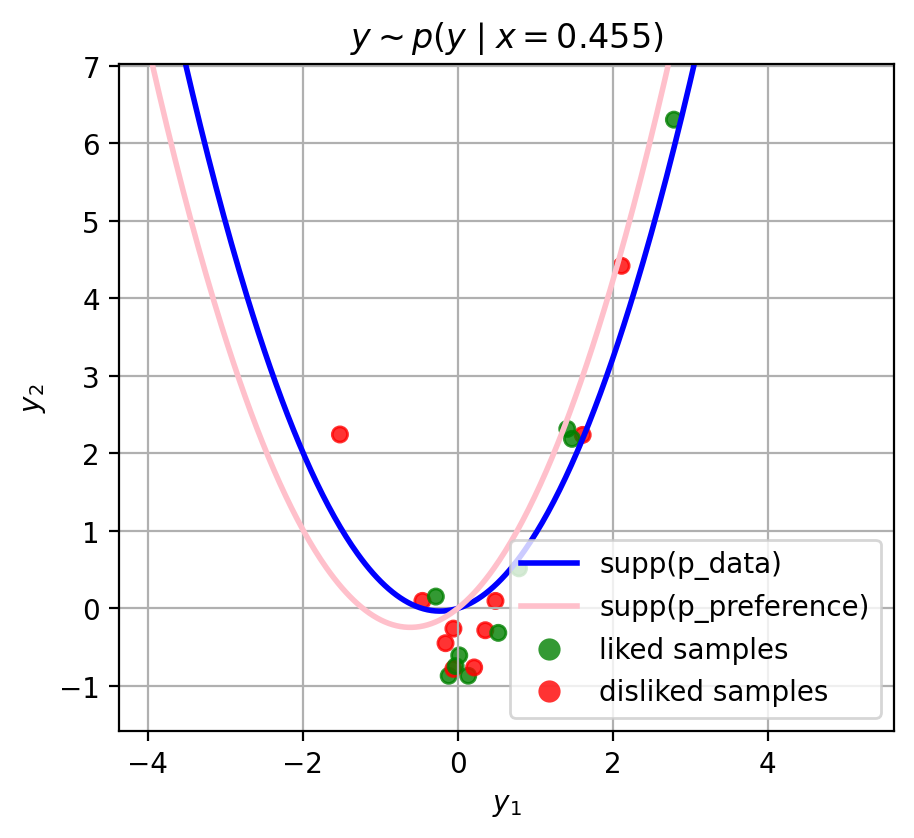

[1/2000] NLL = 0.6998
[2/2000] NLL = 0.6699
[3/2000] NLL = 0.8213
[4/2000] NLL = 0.6705
[5/2000] NLL = 0.6475
[6/2000] NLL = 0.6986
[7/2000] NLL = 0.6951
[8/2000] NLL = 0.6703
[9/2000] NLL = 0.6225
[10/2000] NLL = 0.6290
[11/2000] NLL = 0.6612
[12/2000] NLL = 0.6127
[13/2000] NLL = 0.5895
[14/2000] NLL = 0.5967
[15/2000] NLL = 0.5914
[16/2000] NLL = 0.5879
[17/2000] NLL = 0.6069
[18/2000] NLL = 0.5851
[19/2000] NLL = 0.5982
[20/2000] NLL = 0.5851
[21/2000] NLL = 0.5656
[22/2000] NLL = 0.6031
[23/2000] NLL = 0.5908
[24/2000] NLL = 0.5772
[25/2000] NLL = 0.5905
[26/2000] NLL = 0.5854
[27/2000] NLL = 0.5613
[28/2000] NLL = 0.5661
[29/2000] NLL = 0.5970
[30/2000] NLL = 0.5664
[31/2000] NLL = 0.5437
[32/2000] NLL = 0.5542
[33/2000] NLL = 0.5708
[34/2000] NLL = 0.5436
[35/2000] NLL = 0.5763
[36/2000] NLL = 0.5592
[37/2000] NLL = 0.5349
[38/2000] NLL = 0.5399
[39/2000] NLL = 0.5660
[40/2000] NLL = 0.5301
[41/2000] NLL = 0.5968
[42/2000] NLL = 0.5473
[43/2000] NLL = 0.5757
[44/2000] NLL = 0.58

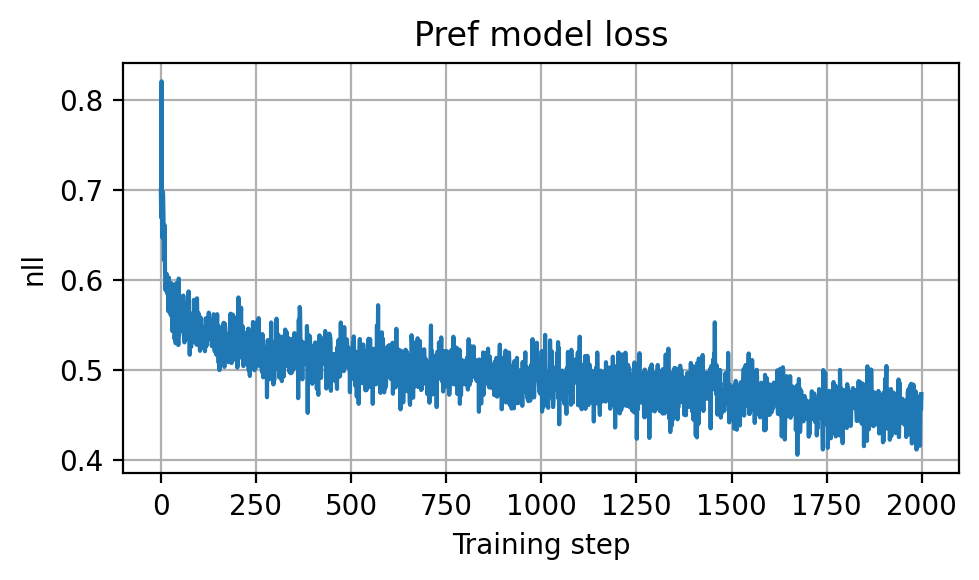

Dataset composition (likes/dislikes):   0.7807999849319458 / 0.2192000150680542
ACC(learned vs GT):   0.9511950016021729 / 0.885919988155365


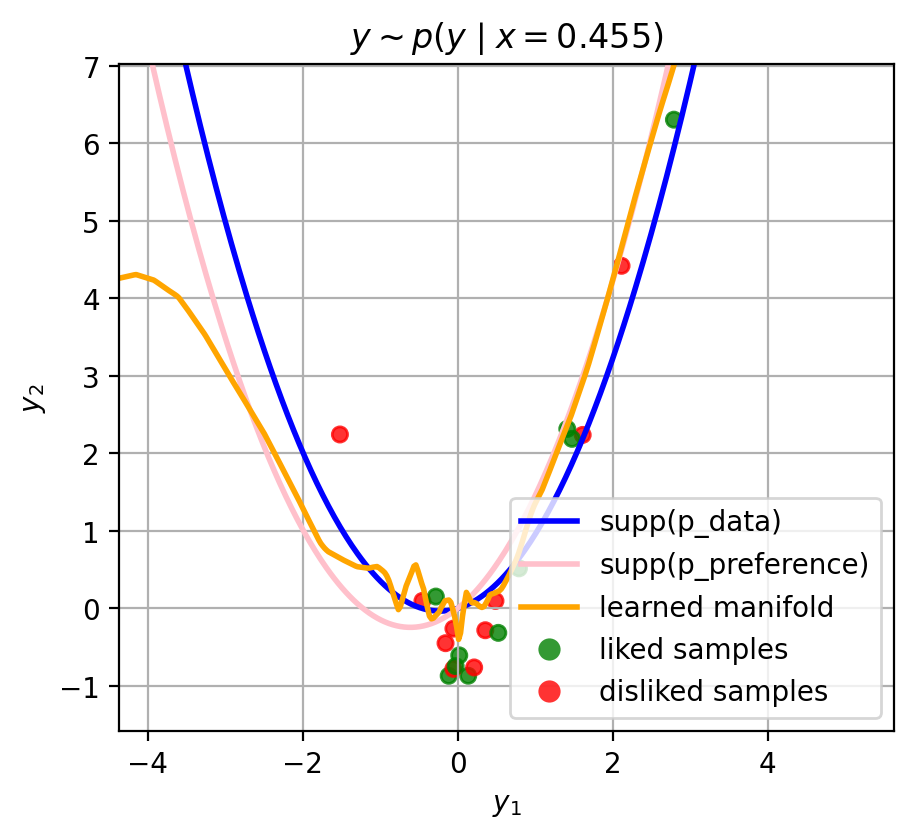

[1/1000] loss = -27.9077
[2/1000] loss = -31.3351
[3/1000] loss = -33.6497
[4/1000] loss = -36.8417
[5/1000] loss = -38.4898
[6/1000] loss = -39.7189
[7/1000] loss = -41.0191
[8/1000] loss = -41.9583
[9/1000] loss = -41.7095
[10/1000] loss = -42.4894
[11/1000] loss = -42.7675
[12/1000] loss = -43.2142
[13/1000] loss = -43.6669
[14/1000] loss = -43.7851
[15/1000] loss = -44.6388
[16/1000] loss = -44.3974
[17/1000] loss = -44.7586
[18/1000] loss = -45.1394
[19/1000] loss = -45.7640
[20/1000] loss = -45.5476
[21/1000] loss = -45.7709
[22/1000] loss = -45.8353
[23/1000] loss = -46.5128
[24/1000] loss = -46.1631
[25/1000] loss = -46.6309
[26/1000] loss = -46.3682
[27/1000] loss = -46.8739
[28/1000] loss = -47.2006
[29/1000] loss = -46.9391
[30/1000] loss = -47.0179
[31/1000] loss = -46.8243
[32/1000] loss = -47.3245
[33/1000] loss = -47.5697
[34/1000] loss = -47.3393
[35/1000] loss = -47.8330
[36/1000] loss = -47.3811
[37/1000] loss = -48.3286
[38/1000] loss = -47.4617
[39/1000] loss = -47.

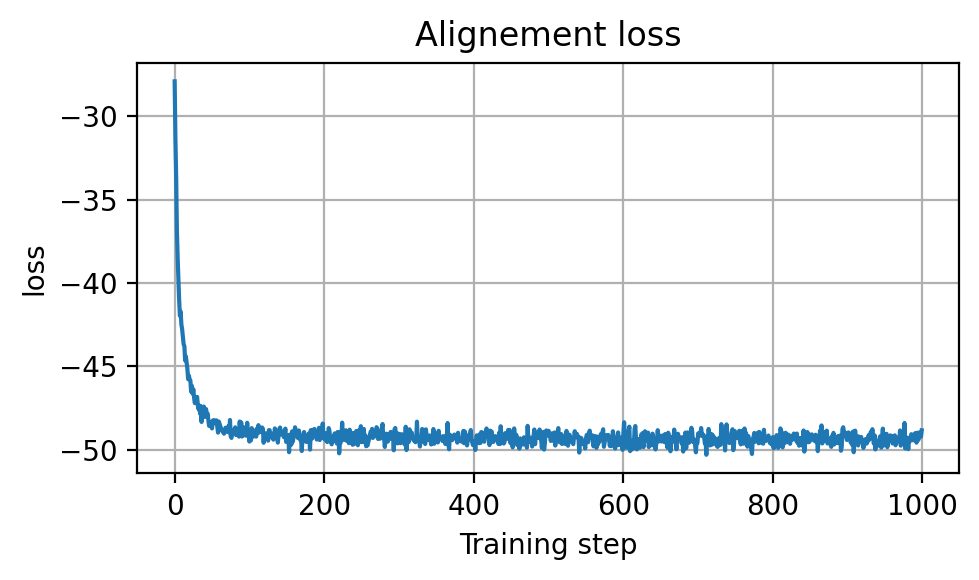

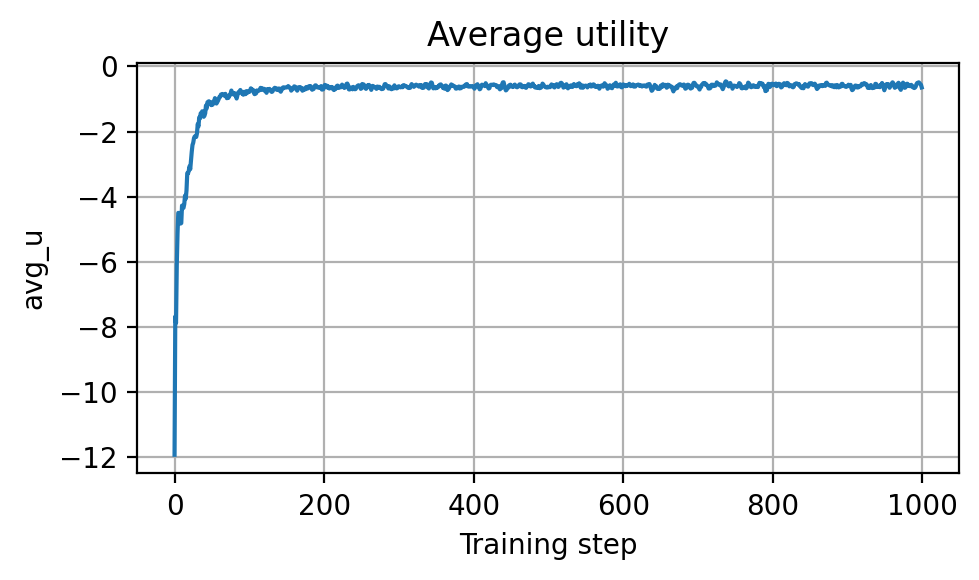

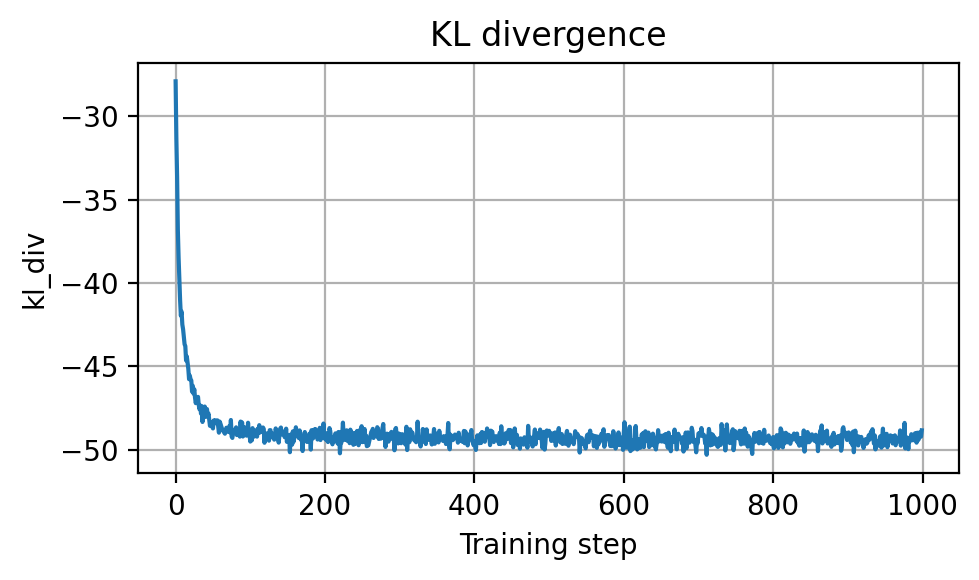

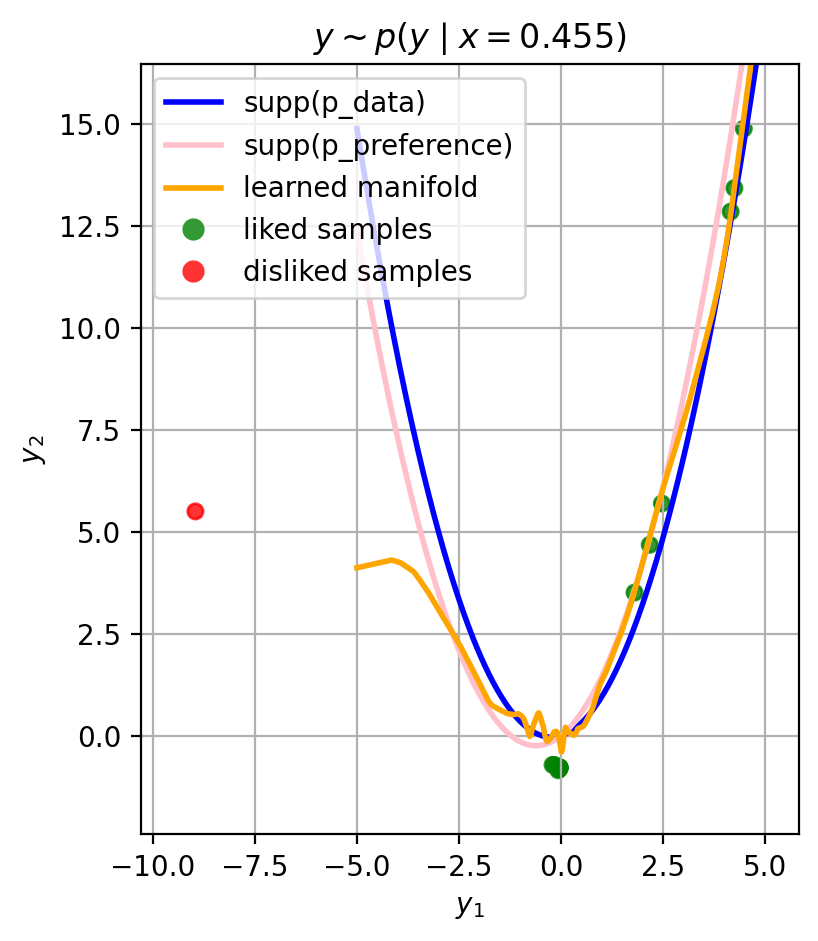

[1/4000] -ELBO = 9.466646194458008
[2/4000] -ELBO = 6.832829475402832
[3/4000] -ELBO = 6.591865539550781
[4/4000] -ELBO = 5.983461380004883
[5/4000] -ELBO = 6.102846145629883
[6/4000] -ELBO = 5.992883205413818
[7/4000] -ELBO = 5.661438465118408
[8/4000] -ELBO = 5.618255138397217
[9/4000] -ELBO = 5.648289203643799
[10/4000] -ELBO = 5.435245990753174
[11/4000] -ELBO = 5.191523551940918
[12/4000] -ELBO = 5.155431747436523
[13/4000] -ELBO = 5.115370273590088
[14/4000] -ELBO = 5.014638900756836
[15/4000] -ELBO = 4.967611789703369
[16/4000] -ELBO = 5.044198036193848
[17/4000] -ELBO = 4.905287265777588
[18/4000] -ELBO = 4.828004837036133
[19/4000] -ELBO = 4.7956156730651855
[20/4000] -ELBO = 4.765964031219482
[21/4000] -ELBO = 4.795892238616943
[22/4000] -ELBO = 4.757325649261475
[23/4000] -ELBO = 4.730400085449219
[24/4000] -ELBO = 4.704421520233154
[25/4000] -ELBO = 4.676976680755615
[26/4000] -ELBO = 4.663125038146973
[27/4000] -ELBO = 4.637765407562256
[28/4000] -ELBO = 4.611911773681641


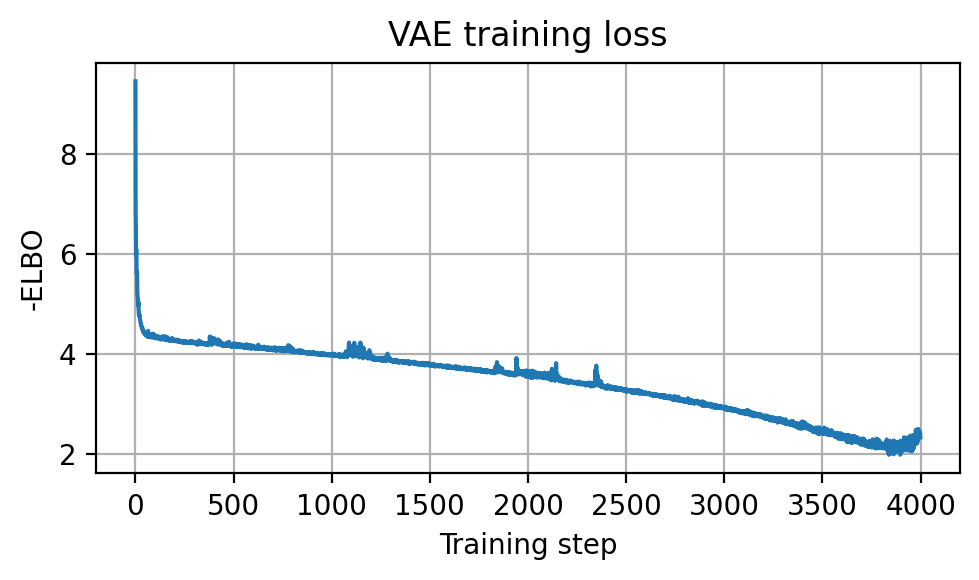

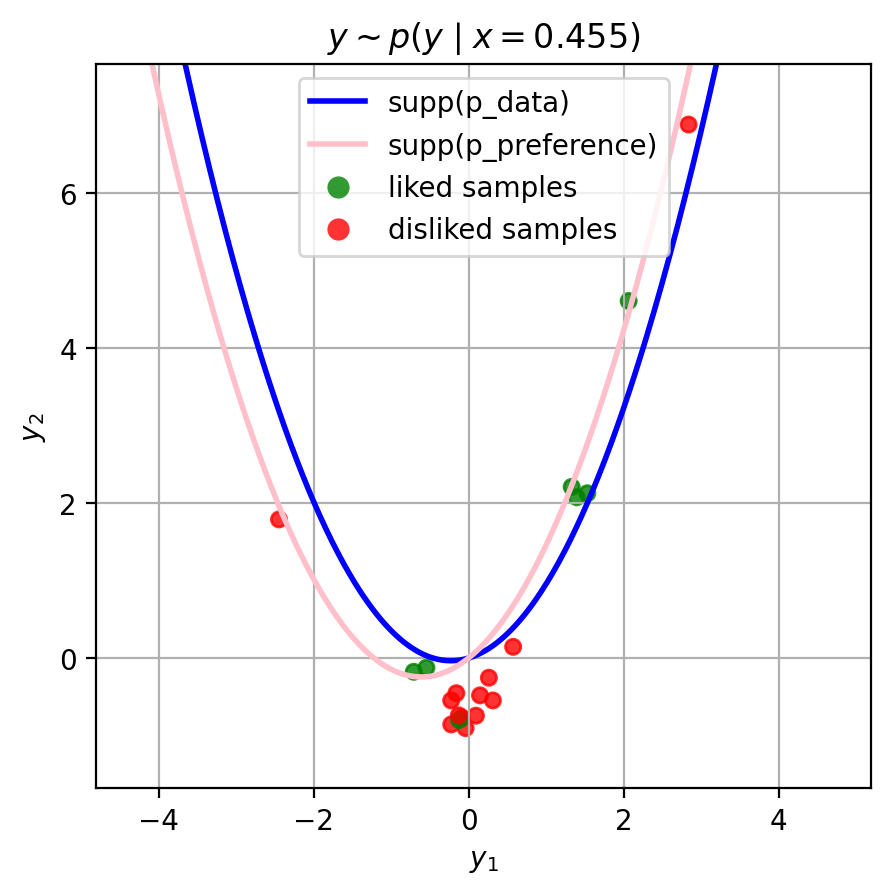

[1/2000] NLL = 0.5156
[2/2000] NLL = 0.8382
[3/2000] NLL = 0.5412
[4/2000] NLL = 0.4953
[5/2000] NLL = 0.5194
[6/2000] NLL = 0.5822
[7/2000] NLL = 0.5403
[8/2000] NLL = 0.5380
[9/2000] NLL = 0.4946
[10/2000] NLL = 0.4814
[11/2000] NLL = 0.5129
[12/2000] NLL = 0.4667
[13/2000] NLL = 0.5475
[14/2000] NLL = 0.4746
[15/2000] NLL = 0.5475
[16/2000] NLL = 0.5320
[17/2000] NLL = 0.5330
[18/2000] NLL = 0.5208
[19/2000] NLL = 0.5012
[20/2000] NLL = 0.5079
[21/2000] NLL = 0.4878
[22/2000] NLL = 0.4600
[23/2000] NLL = 0.4631
[24/2000] NLL = 0.4591
[25/2000] NLL = 0.4904
[26/2000] NLL = 0.5227
[27/2000] NLL = 0.4696
[28/2000] NLL = 0.4840
[29/2000] NLL = 0.5101
[30/2000] NLL = 0.4749
[31/2000] NLL = 0.5144
[32/2000] NLL = 0.4515
[33/2000] NLL = 0.4509
[34/2000] NLL = 0.4301
[35/2000] NLL = 0.4640
[36/2000] NLL = 0.4869
[37/2000] NLL = 0.4405
[38/2000] NLL = 0.5173
[39/2000] NLL = 0.4290
[40/2000] NLL = 0.4881
[41/2000] NLL = 0.4554
[42/2000] NLL = 0.4793
[43/2000] NLL = 0.4649
[44/2000] NLL = 0.44

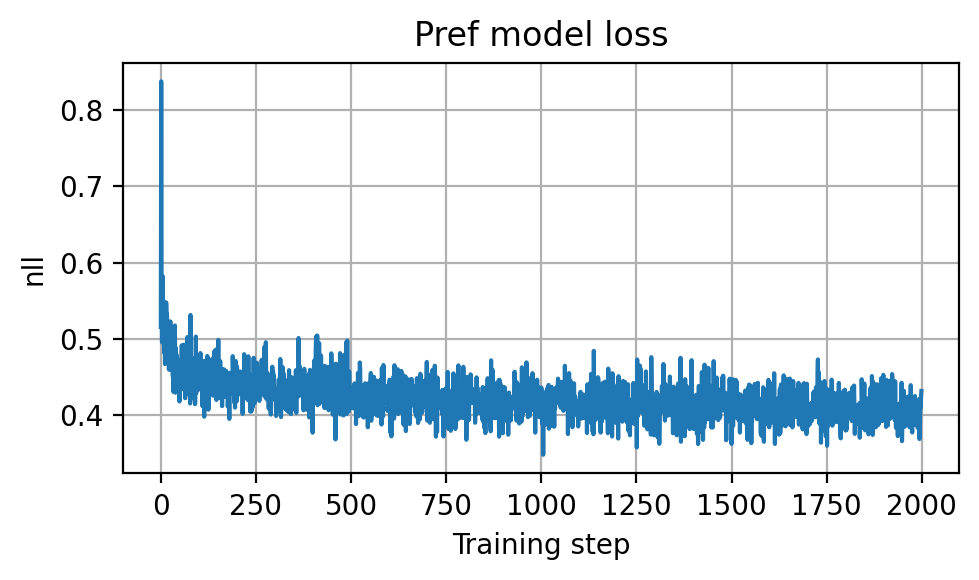

Dataset composition (likes/dislikes):   0.7271949648857117 / 0.27280503511428833
ACC(learned vs GT):   0.905834972858429 / 0.8564899563789368


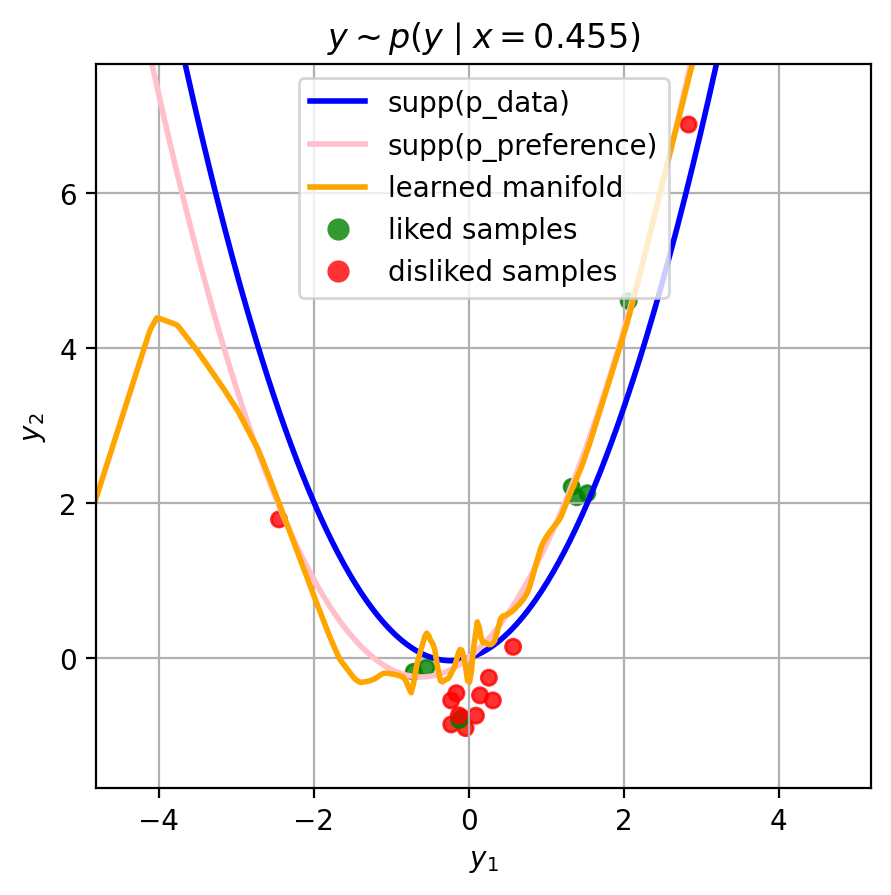

[1/1000] loss = -44.9436
[2/1000] loss = -49.0814
[3/1000] loss = -50.8588
[4/1000] loss = -51.4829
[5/1000] loss = -52.3382
[6/1000] loss = -53.2988
[7/1000] loss = -53.4557
[8/1000] loss = -54.3040
[9/1000] loss = -54.4371
[10/1000] loss = -54.5771
[11/1000] loss = -54.4551
[12/1000] loss = -54.6095
[13/1000] loss = -54.7832
[14/1000] loss = -55.0190
[15/1000] loss = -55.3763
[16/1000] loss = -55.4509
[17/1000] loss = -55.6540
[18/1000] loss = -55.7442
[19/1000] loss = -56.2026
[20/1000] loss = -56.0193
[21/1000] loss = -55.7747
[22/1000] loss = -55.9844
[23/1000] loss = -56.1359
[24/1000] loss = -55.9407
[25/1000] loss = -56.1362
[26/1000] loss = -56.2742
[27/1000] loss = -56.1384
[28/1000] loss = -56.3000
[29/1000] loss = -56.2650
[30/1000] loss = -56.0267
[31/1000] loss = -56.4420
[32/1000] loss = -56.3817
[33/1000] loss = -56.1136
[34/1000] loss = -56.7482
[35/1000] loss = -56.1391
[36/1000] loss = -56.3860
[37/1000] loss = -56.4370
[38/1000] loss = -56.5117
[39/1000] loss = -56.

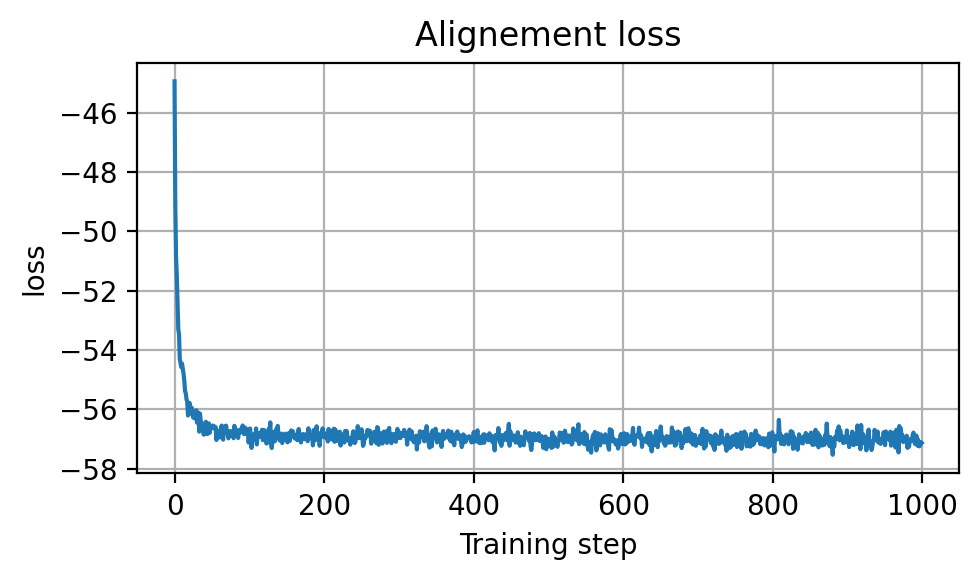

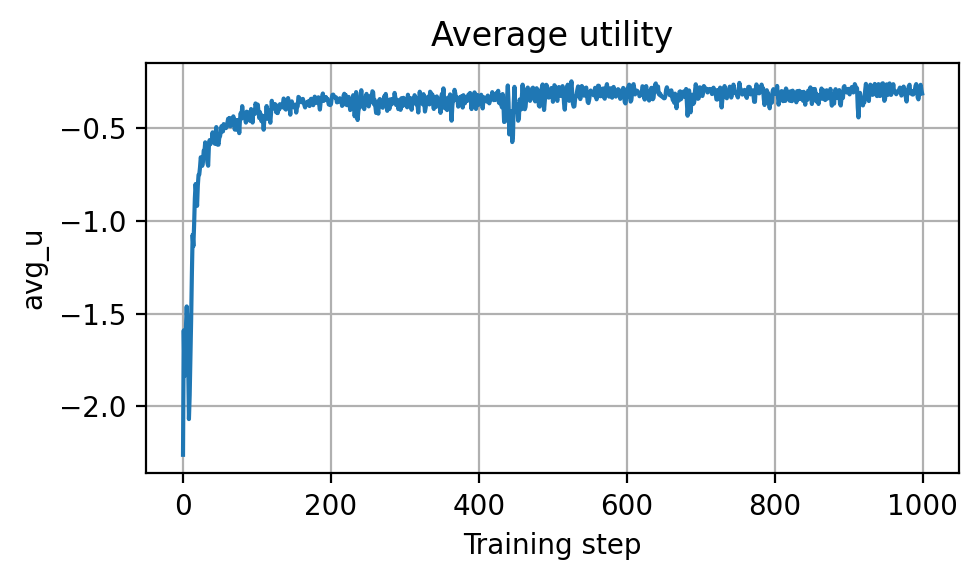

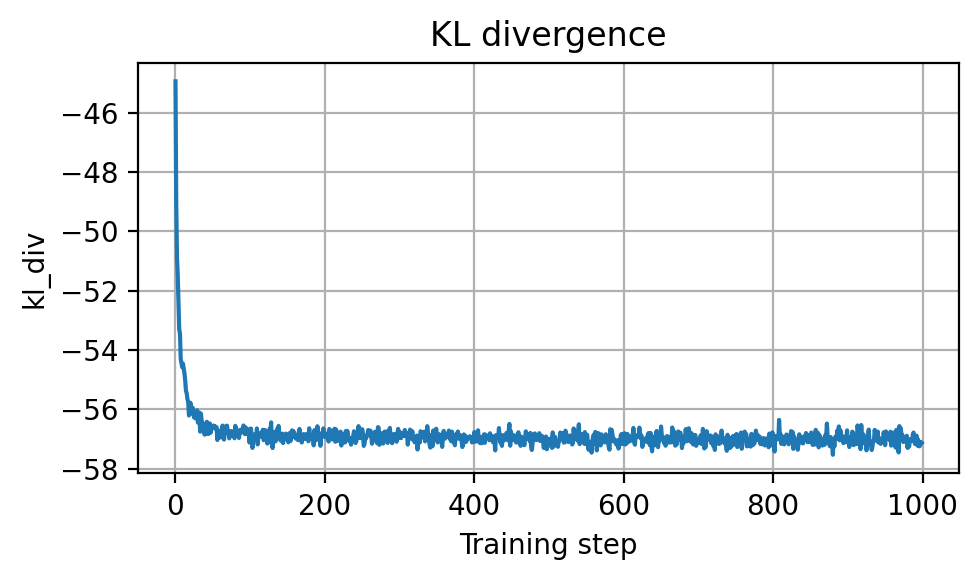

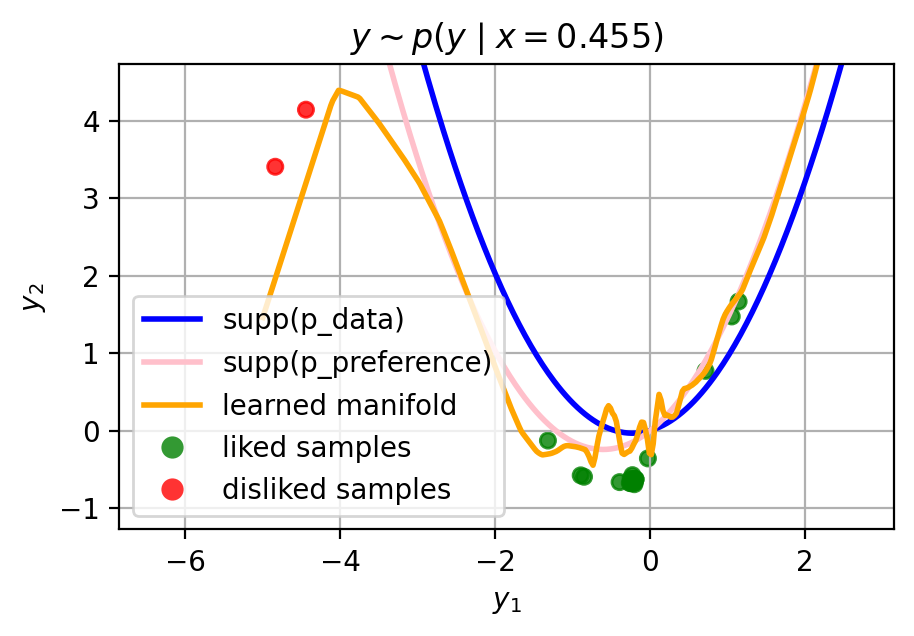

[1/4000] -ELBO = 9.29487419128418
[2/4000] -ELBO = 6.154139518737793
[3/4000] -ELBO = 6.968558311462402
[4/4000] -ELBO = 7.230602264404297
[5/4000] -ELBO = 6.617627143859863
[6/4000] -ELBO = 5.822787284851074
[7/4000] -ELBO = 5.696011543273926
[8/4000] -ELBO = 5.814146041870117
[9/4000] -ELBO = 5.710248947143555
[10/4000] -ELBO = 5.398060321807861
[11/4000] -ELBO = 5.203310966491699
[12/4000] -ELBO = 5.317391395568848
[13/4000] -ELBO = 5.312696933746338
[14/4000] -ELBO = 5.137282848358154
[15/4000] -ELBO = 5.005234241485596
[16/4000] -ELBO = 5.029853820800781
[17/4000] -ELBO = 5.073669910430908
[18/4000] -ELBO = 4.982529640197754
[19/4000] -ELBO = 4.861180305480957
[20/4000] -ELBO = 4.874094009399414
[21/4000] -ELBO = 4.928922176361084
[22/4000] -ELBO = 4.993592262268066
[23/4000] -ELBO = 4.851245403289795
[24/4000] -ELBO = 4.797752380371094
[25/4000] -ELBO = 4.778414249420166
[26/4000] -ELBO = 4.7359771728515625
[27/4000] -ELBO = 4.711890697479248
[28/4000] -ELBO = 4.694889068603516
[

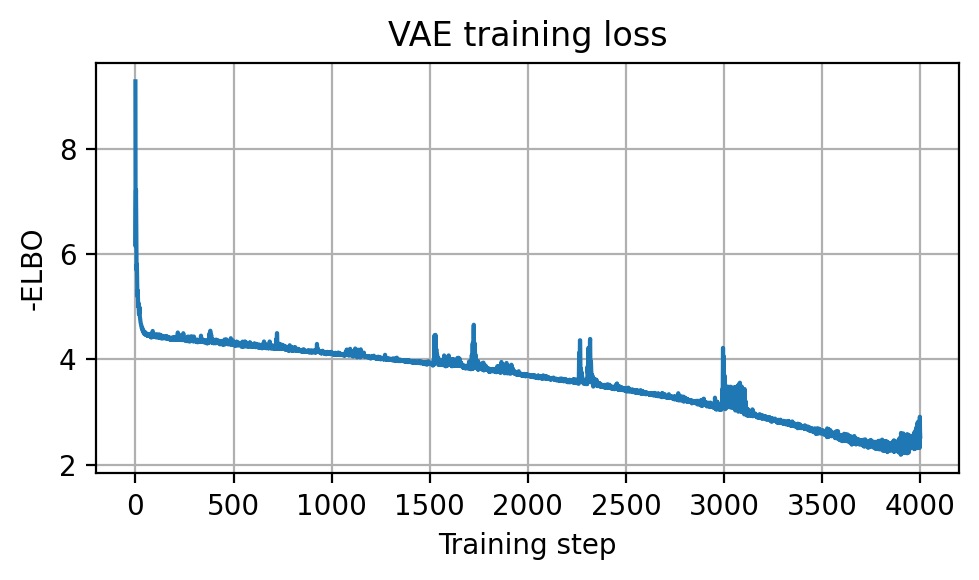

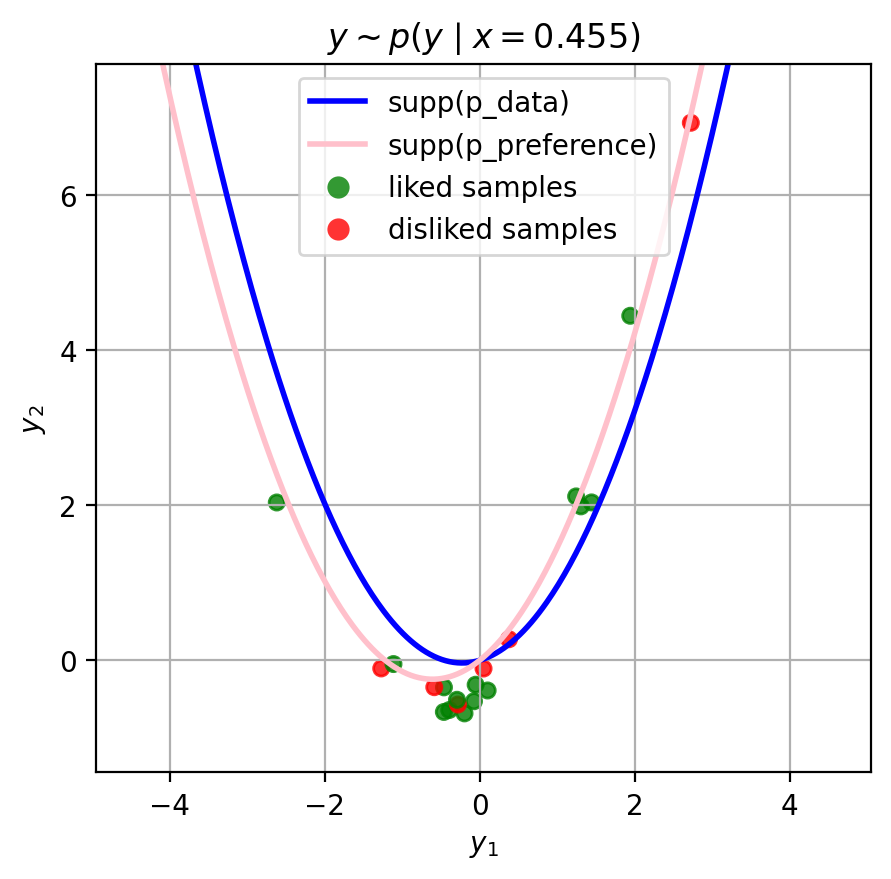

[1/2000] NLL = 0.4801
[2/2000] NLL = 1.4844
[3/2000] NLL = 0.7291
[4/2000] NLL = 0.5030
[5/2000] NLL = 0.5787
[6/2000] NLL = 0.5172
[7/2000] NLL = 0.5281
[8/2000] NLL = 0.5374
[9/2000] NLL = 0.5026
[10/2000] NLL = 0.4958
[11/2000] NLL = 0.5039
[12/2000] NLL = 0.5114
[13/2000] NLL = 0.4637
[14/2000] NLL = 0.4448
[15/2000] NLL = 0.4668
[16/2000] NLL = 0.4611
[17/2000] NLL = 0.4486
[18/2000] NLL = 0.4543
[19/2000] NLL = 0.4589
[20/2000] NLL = 0.4385
[21/2000] NLL = 0.4761
[22/2000] NLL = 0.4567
[23/2000] NLL = 0.4608
[24/2000] NLL = 0.4732
[25/2000] NLL = 0.4745
[26/2000] NLL = 0.4567
[27/2000] NLL = 0.4475
[28/2000] NLL = 0.4576
[29/2000] NLL = 0.4818
[30/2000] NLL = 0.4195
[31/2000] NLL = 0.4655
[32/2000] NLL = 0.4707
[33/2000] NLL = 0.4614
[34/2000] NLL = 0.4528
[35/2000] NLL = 0.4778
[36/2000] NLL = 0.4219
[37/2000] NLL = 0.4925
[38/2000] NLL = 0.4497
[39/2000] NLL = 0.4883
[40/2000] NLL = 0.4873
[41/2000] NLL = 0.4164
[42/2000] NLL = 0.4455
[43/2000] NLL = 0.4874
[44/2000] NLL = 0.44

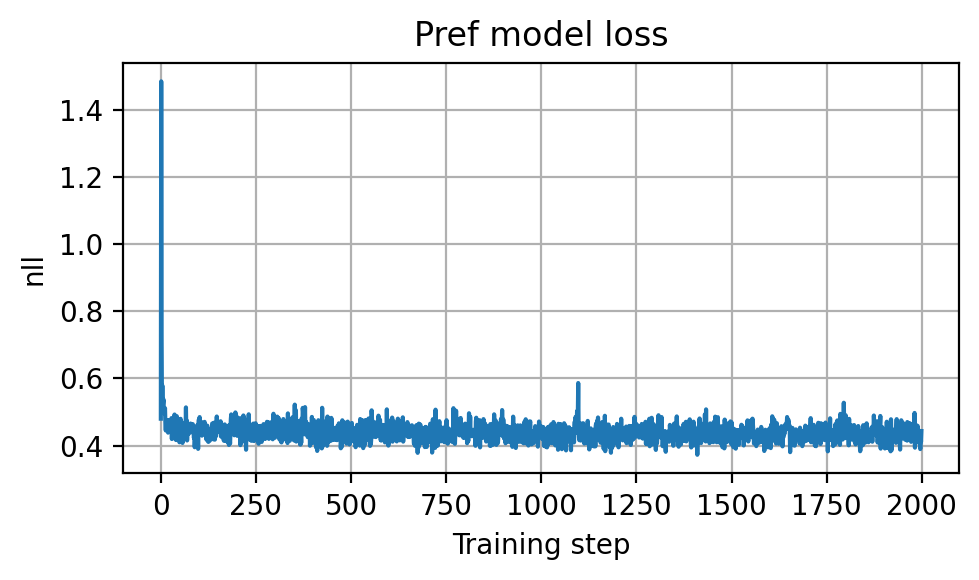

Dataset composition (likes/dislikes):   0.6946699619293213 / 0.3053300380706787
ACC(learned vs GT):   0.8199449777603149 / 0.7993999719619751


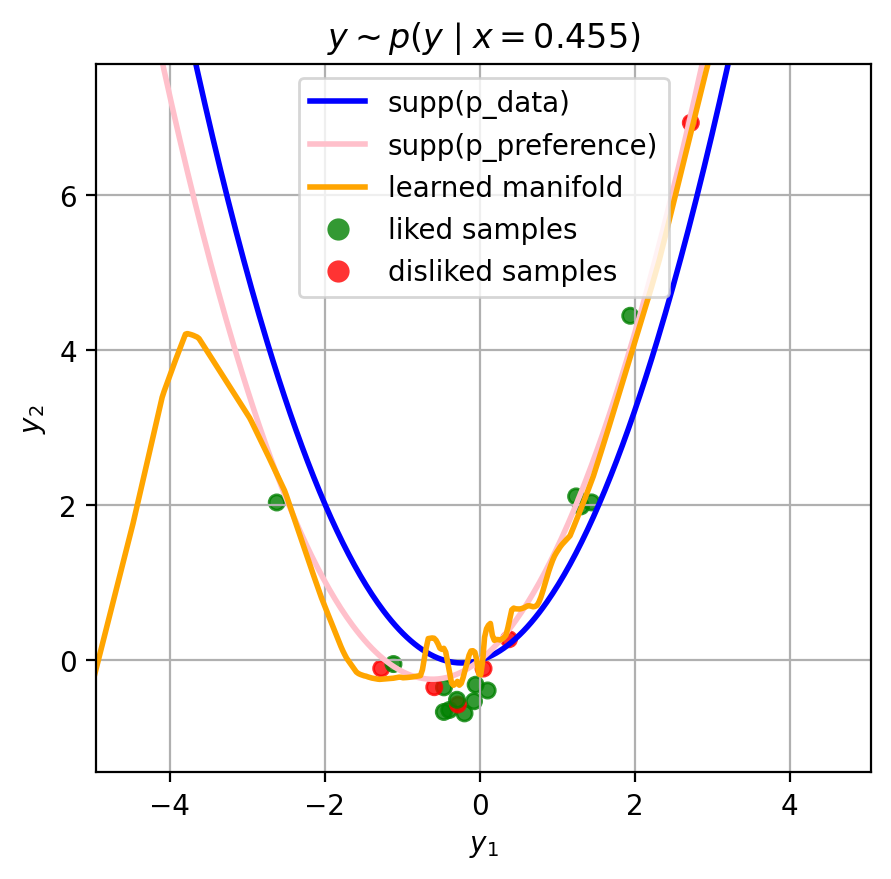

[1/1000] loss = -56.2475
[2/1000] loss = -57.8438
[3/1000] loss = -58.8386
[4/1000] loss = -59.8833
[5/1000] loss = -60.4691
[6/1000] loss = -61.0539
[7/1000] loss = -61.2883
[8/1000] loss = -61.4419
[9/1000] loss = -61.8300
[10/1000] loss = -61.8393
[11/1000] loss = -61.8863
[12/1000] loss = -61.9754
[13/1000] loss = -62.2135
[14/1000] loss = -62.0281
[15/1000] loss = -62.3117
[16/1000] loss = -62.2499
[17/1000] loss = -62.5189
[18/1000] loss = -62.5854
[19/1000] loss = -62.3958
[20/1000] loss = -62.3849
[21/1000] loss = -62.3648
[22/1000] loss = -62.4423
[23/1000] loss = -62.6528
[24/1000] loss = -62.7065
[25/1000] loss = -62.3250
[26/1000] loss = -62.5643
[27/1000] loss = -62.4897
[28/1000] loss = -62.6157
[29/1000] loss = -62.5984
[30/1000] loss = -62.7289
[31/1000] loss = -62.8310
[32/1000] loss = -62.8067
[33/1000] loss = -62.7718
[34/1000] loss = -62.7708
[35/1000] loss = -62.6701
[36/1000] loss = -62.6158
[37/1000] loss = -62.8232
[38/1000] loss = -62.4452
[39/1000] loss = -62.

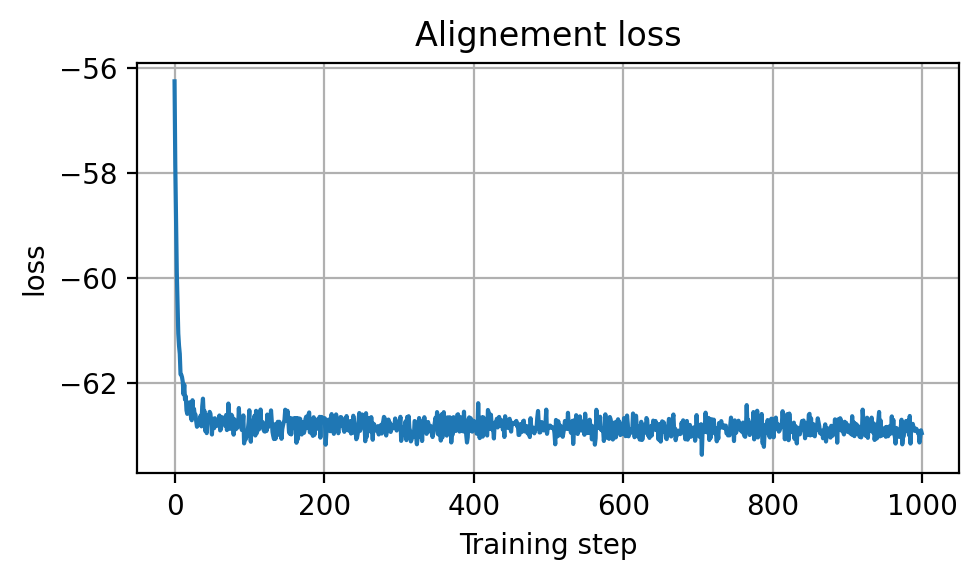

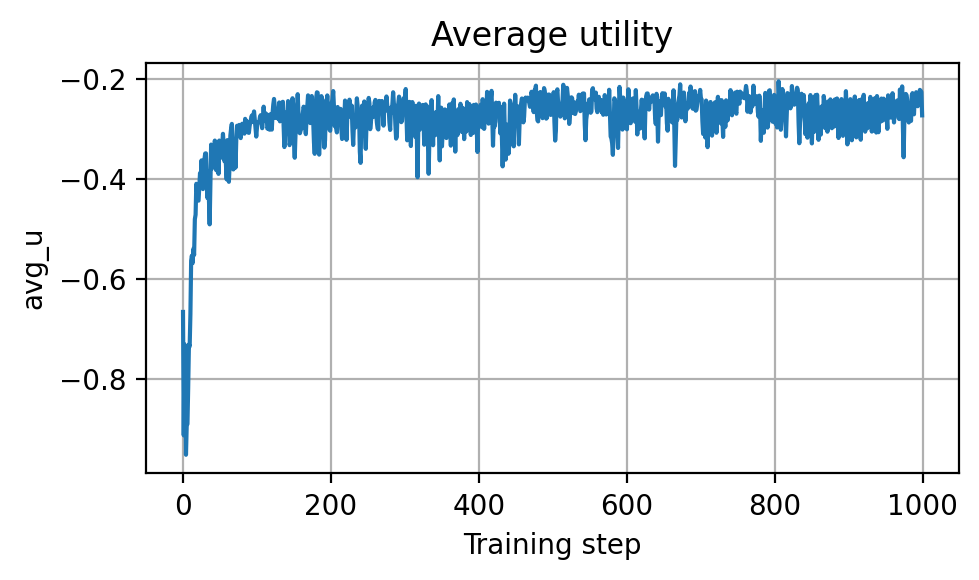

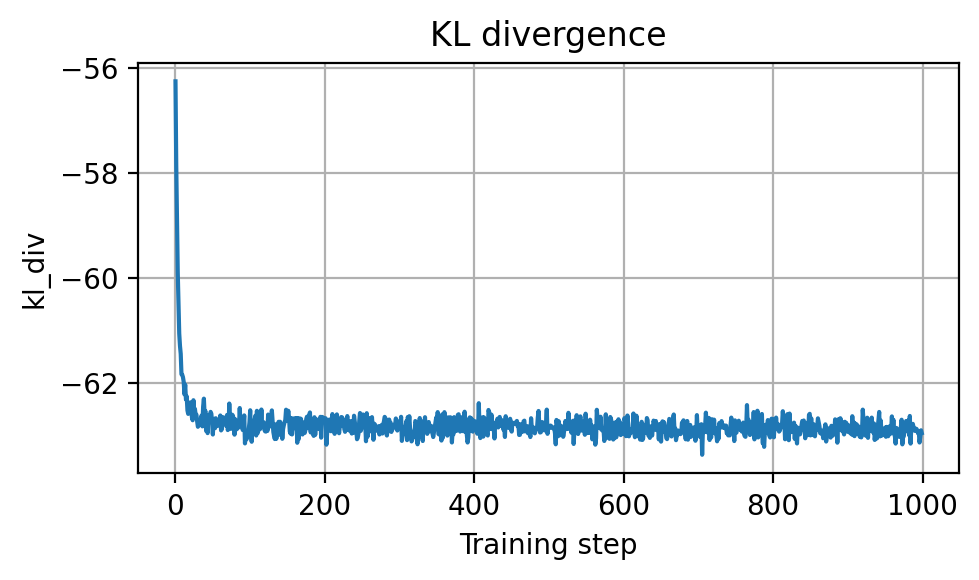

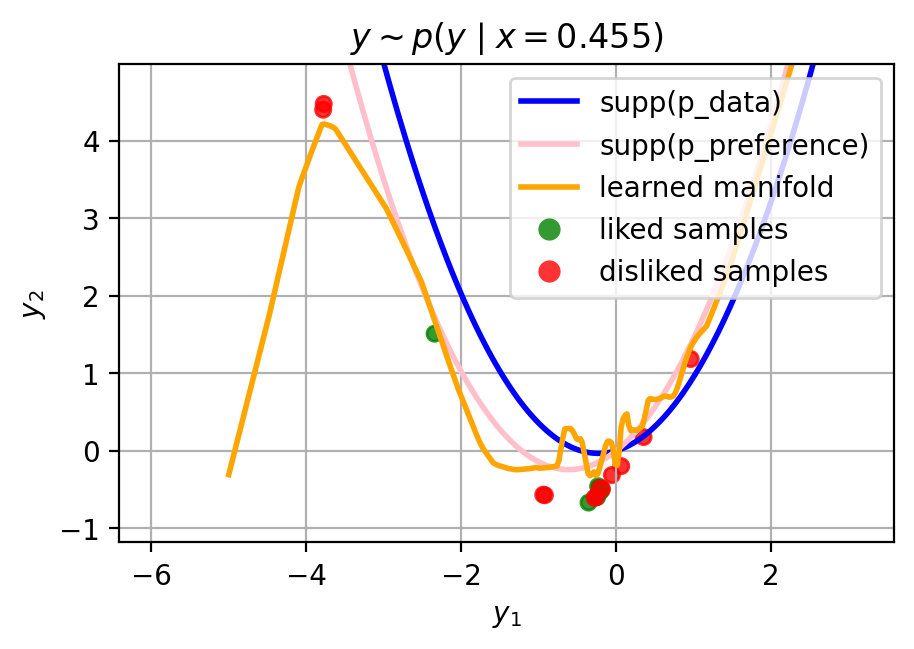

[1/4000] -ELBO = 9.401006698608398
[2/4000] -ELBO = 6.191470146179199
[3/4000] -ELBO = 6.735669136047363
[4/4000] -ELBO = 6.8478217124938965
[5/4000] -ELBO = 6.535482883453369
[6/4000] -ELBO = 5.946021556854248
[7/4000] -ELBO = 5.535719871520996
[8/4000] -ELBO = 5.615971088409424
[9/4000] -ELBO = 5.784492015838623
[10/4000] -ELBO = 5.71895694732666
[11/4000] -ELBO = 5.402972221374512
[12/4000] -ELBO = 5.2849273681640625
[13/4000] -ELBO = 5.193288803100586
[14/4000] -ELBO = 5.166998863220215
[15/4000] -ELBO = 5.064329147338867
[16/4000] -ELBO = 4.989673137664795
[17/4000] -ELBO = 4.9678874015808105
[18/4000] -ELBO = 5.010552406311035
[19/4000] -ELBO = 4.917764186859131
[20/4000] -ELBO = 4.8522467613220215
[21/4000] -ELBO = 4.805269241333008
[22/4000] -ELBO = 4.806804656982422
[23/4000] -ELBO = 4.768284320831299
[24/4000] -ELBO = 4.757228851318359
[25/4000] -ELBO = 4.714573860168457
[26/4000] -ELBO = 4.708498954772949
[27/4000] -ELBO = 4.71875524520874
[28/4000] -ELBO = 4.703579425811768

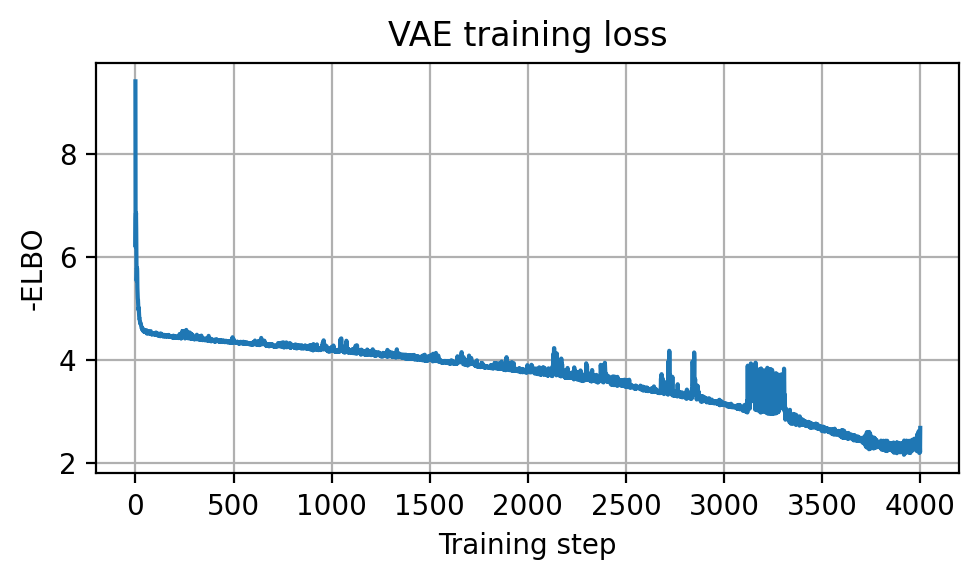

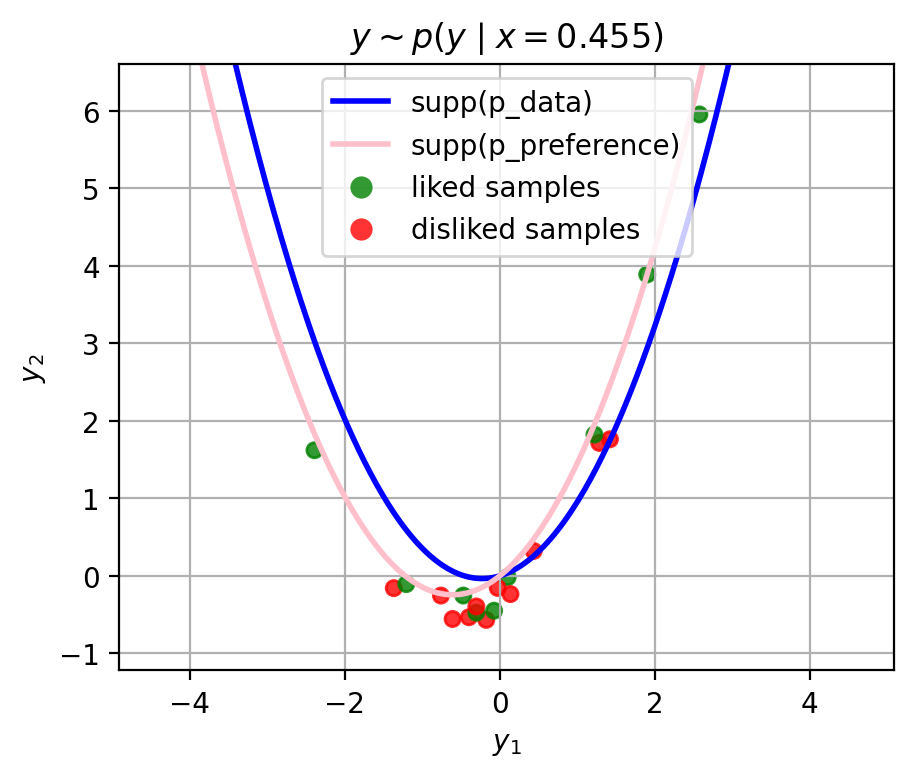

[1/2000] NLL = 0.4932
[2/2000] NLL = 0.9732
[3/2000] NLL = 0.8654
[4/2000] NLL = 0.5669
[5/2000] NLL = 0.5389
[6/2000] NLL = 0.5805
[7/2000] NLL = 0.5201
[8/2000] NLL = 0.5620
[9/2000] NLL = 0.5040
[10/2000] NLL = 0.5435
[11/2000] NLL = 0.5124
[12/2000] NLL = 0.5147
[13/2000] NLL = 0.5382
[14/2000] NLL = 0.4735
[15/2000] NLL = 0.5086
[16/2000] NLL = 0.4304
[17/2000] NLL = 0.4722
[18/2000] NLL = 0.4600
[19/2000] NLL = 0.4499
[20/2000] NLL = 0.4812
[21/2000] NLL = 0.4816
[22/2000] NLL = 0.4794
[23/2000] NLL = 0.4801
[24/2000] NLL = 0.4834
[25/2000] NLL = 0.4854
[26/2000] NLL = 0.4715
[27/2000] NLL = 0.4517
[28/2000] NLL = 0.4903
[29/2000] NLL = 0.4714
[30/2000] NLL = 0.4681
[31/2000] NLL = 0.4859
[32/2000] NLL = 0.4535
[33/2000] NLL = 0.4837
[34/2000] NLL = 0.4958
[35/2000] NLL = 0.4588
[36/2000] NLL = 0.4768
[37/2000] NLL = 0.4669
[38/2000] NLL = 0.4823
[39/2000] NLL = 0.4997
[40/2000] NLL = 0.4775
[41/2000] NLL = 0.4889
[42/2000] NLL = 0.5146
[43/2000] NLL = 0.5193
[44/2000] NLL = 0.53

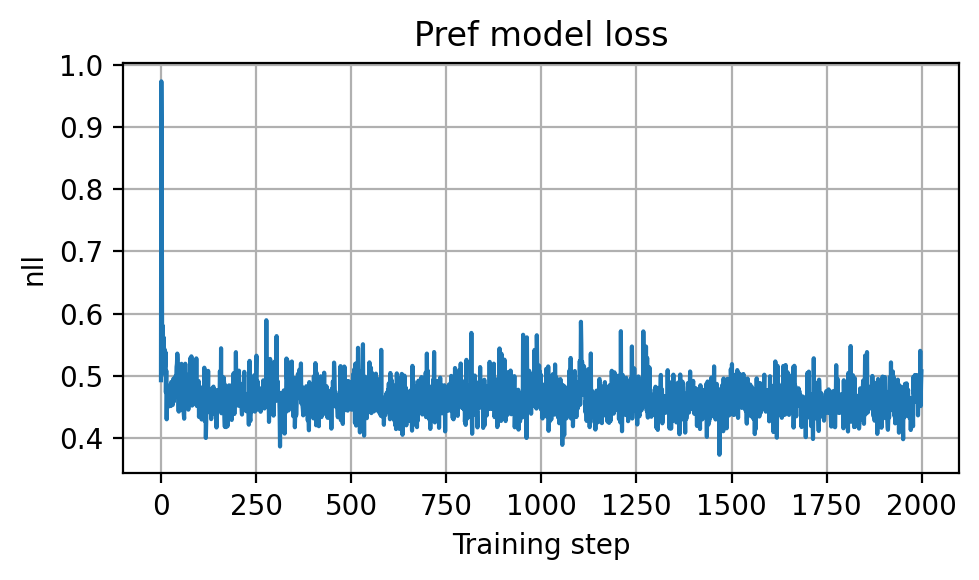

Dataset composition (likes/dislikes):   0.6875500082969666 / 0.31244999170303345
ACC(learned vs GT):   0.7774549722671509 / 0.7933250069618225


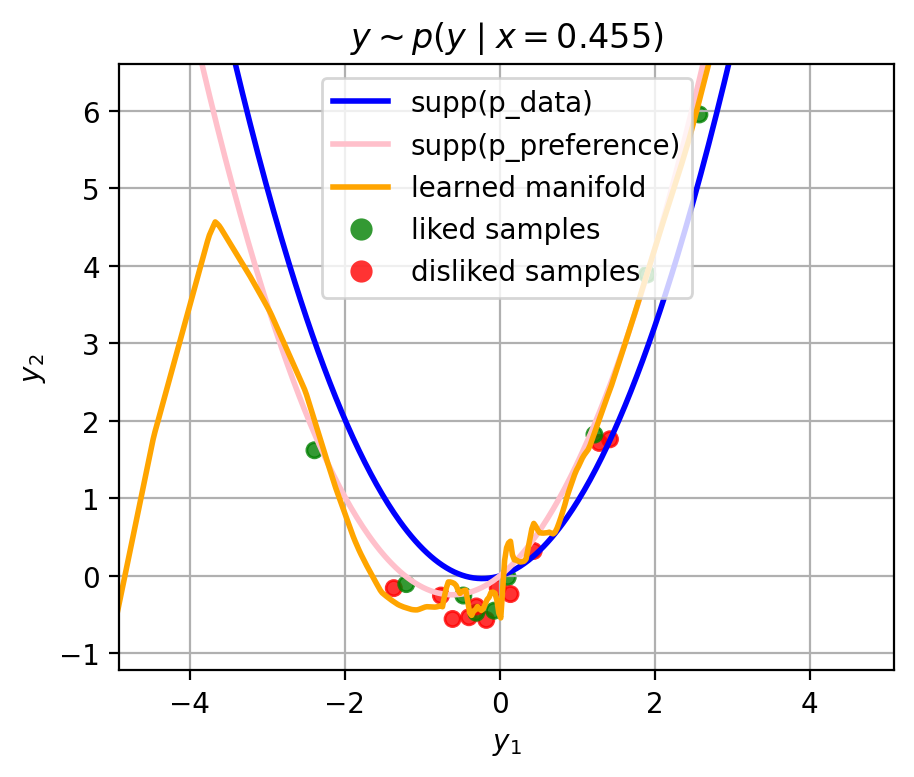

[1/1000] loss = -61.6811
[2/1000] loss = -62.8207
[3/1000] loss = -63.5301
[4/1000] loss = -64.4509
[5/1000] loss = -64.8572
[6/1000] loss = -65.3776
[7/1000] loss = -65.5827
[8/1000] loss = -65.9716
[9/1000] loss = -65.8814
[10/1000] loss = -66.2447
[11/1000] loss = -66.1508
[12/1000] loss = -66.2638
[13/1000] loss = -66.1474
[14/1000] loss = -66.4052
[15/1000] loss = -66.4591
[16/1000] loss = -66.3515
[17/1000] loss = -66.4725
[18/1000] loss = -66.3759
[19/1000] loss = -66.7266
[20/1000] loss = -66.6476
[21/1000] loss = -66.3722
[22/1000] loss = -66.6766
[23/1000] loss = -66.5231
[24/1000] loss = -66.7813
[25/1000] loss = -66.3539
[26/1000] loss = -66.8978
[27/1000] loss = -66.6561
[28/1000] loss = -66.6059
[29/1000] loss = -66.6753
[30/1000] loss = -66.6158
[31/1000] loss = -66.5648
[32/1000] loss = -66.6363
[33/1000] loss = -66.7985
[34/1000] loss = -66.8711
[35/1000] loss = -66.7536
[36/1000] loss = -66.7524
[37/1000] loss = -66.7775
[38/1000] loss = -66.7750
[39/1000] loss = -67.

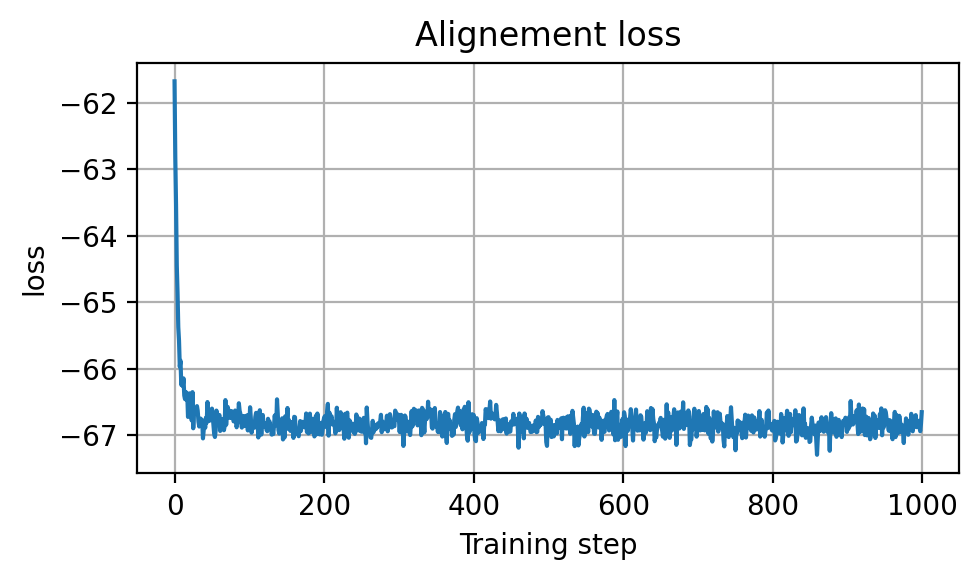

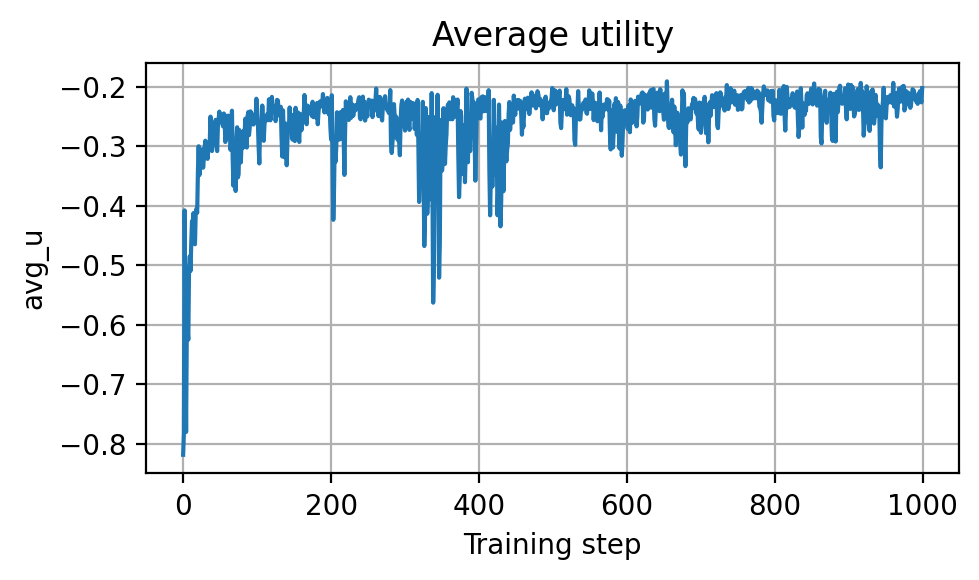

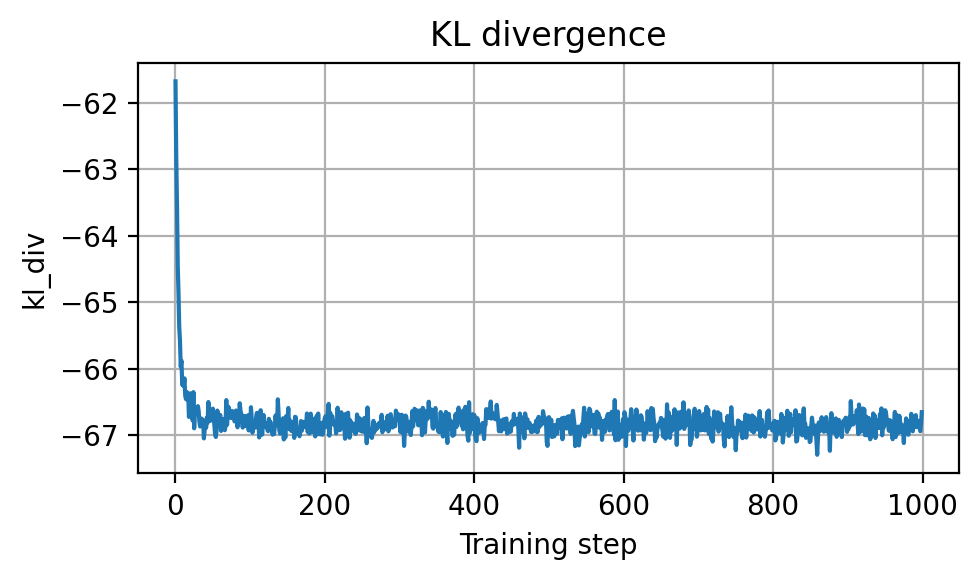

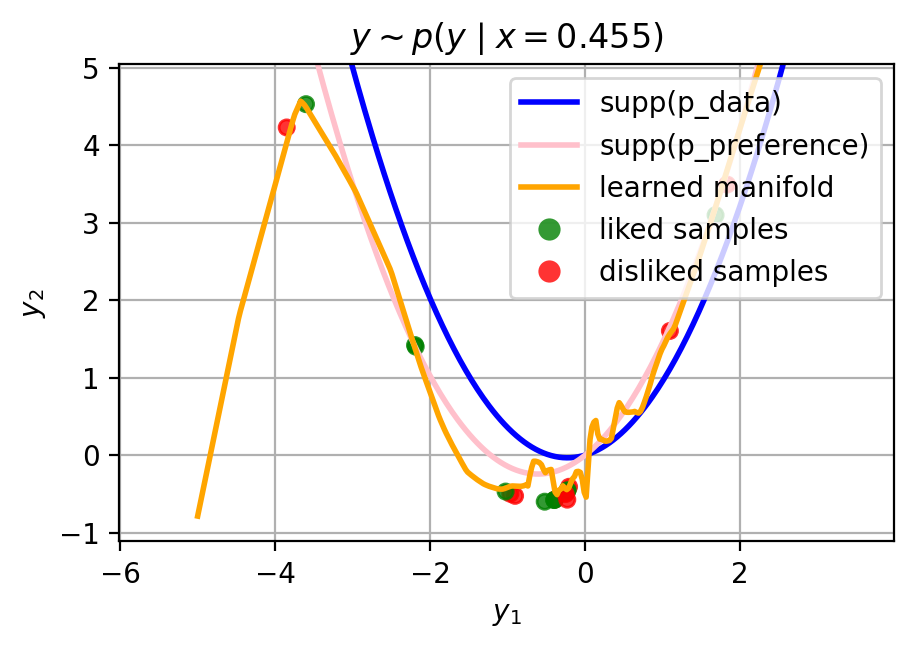

[1/4000] -ELBO = 8.723809242248535
[2/4000] -ELBO = 6.223464488983154
[3/4000] -ELBO = 6.439188003540039
[4/4000] -ELBO = 6.635732650756836
[5/4000] -ELBO = 6.299590110778809
[6/4000] -ELBO = 5.8062639236450195
[7/4000] -ELBO = 5.4707865715026855
[8/4000] -ELBO = 5.4812798500061035
[9/4000] -ELBO = 5.566318035125732
[10/4000] -ELBO = 5.4646100997924805
[11/4000] -ELBO = 5.260960578918457
[12/4000] -ELBO = 5.2052741050720215
[13/4000] -ELBO = 5.190640449523926
[14/4000] -ELBO = 5.121753215789795
[15/4000] -ELBO = 5.039036750793457
[16/4000] -ELBO = 4.981661796569824
[17/4000] -ELBO = 4.981871128082275
[18/4000] -ELBO = 4.96295690536499
[19/4000] -ELBO = 4.896636486053467
[20/4000] -ELBO = 4.862173080444336
[21/4000] -ELBO = 4.861282825469971
[22/4000] -ELBO = 4.819511413574219
[23/4000] -ELBO = 4.791628837585449
[24/4000] -ELBO = 4.778371810913086
[25/4000] -ELBO = 4.740070343017578
[26/4000] -ELBO = 4.726530075073242
[27/4000] -ELBO = 4.728886604309082
[28/4000] -ELBO = 4.7513709068298

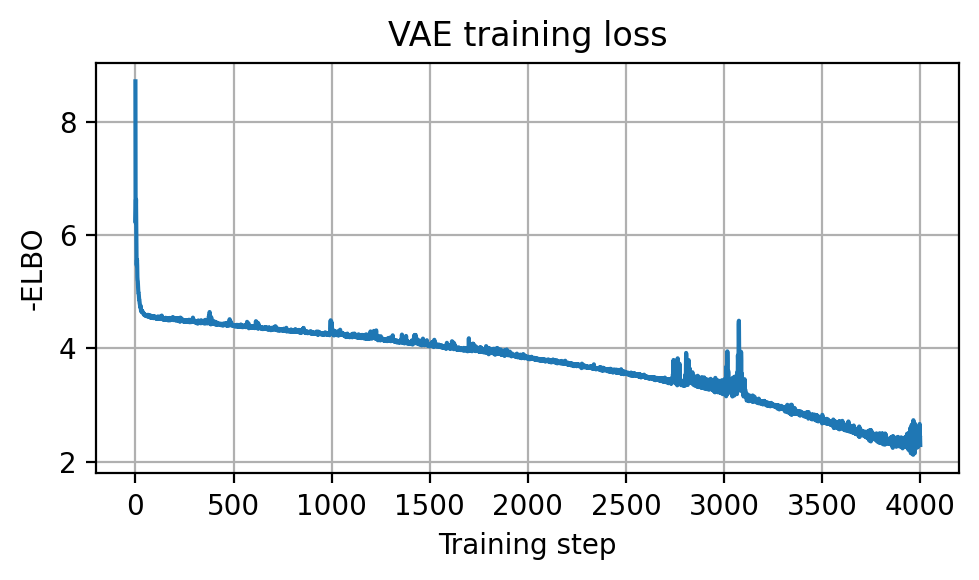

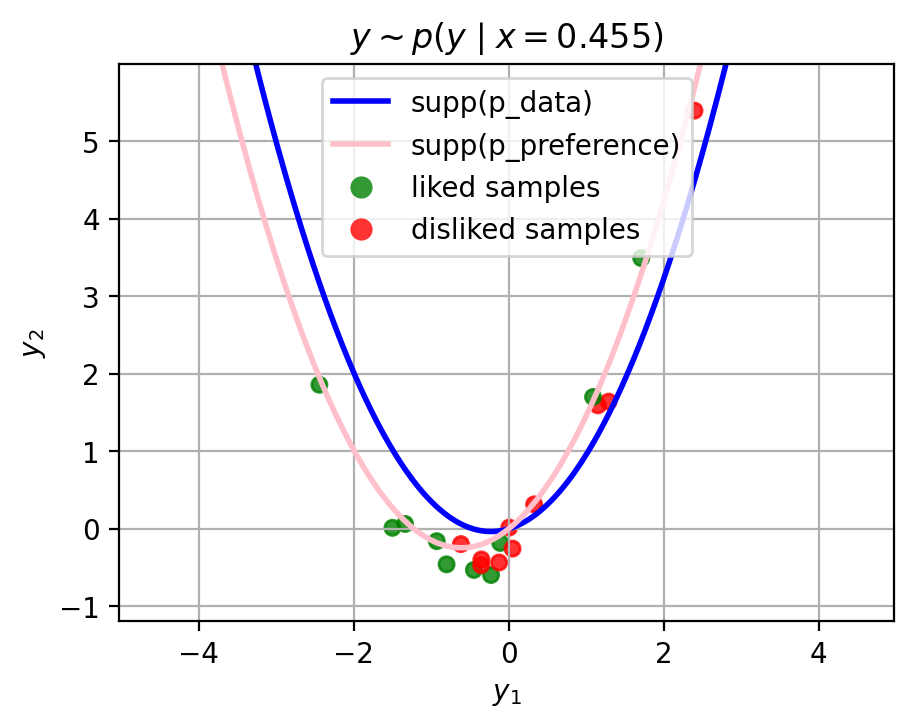

[1/2000] NLL = 0.5789
[2/2000] NLL = 1.4646
[3/2000] NLL = 1.4691
[4/2000] NLL = 0.9198
[5/2000] NLL = 0.5336
[6/2000] NLL = 0.7045
[7/2000] NLL = 0.7342
[8/2000] NLL = 0.5833
[9/2000] NLL = 0.6442
[10/2000] NLL = 0.7617
[11/2000] NLL = 0.7178
[12/2000] NLL = 0.6302
[13/2000] NLL = 0.5784
[14/2000] NLL = 0.6206
[15/2000] NLL = 0.6663
[16/2000] NLL = 0.5243
[17/2000] NLL = 0.4743
[18/2000] NLL = 0.5162
[19/2000] NLL = 0.5098
[20/2000] NLL = 0.4960
[21/2000] NLL = 0.4716
[22/2000] NLL = 0.5573
[23/2000] NLL = 0.5364
[24/2000] NLL = 0.5229
[25/2000] NLL = 0.4998
[26/2000] NLL = 0.5932
[27/2000] NLL = 0.5058
[28/2000] NLL = 0.4831
[29/2000] NLL = 0.5176
[30/2000] NLL = 0.5093
[31/2000] NLL = 0.4837
[32/2000] NLL = 0.4906
[33/2000] NLL = 0.4468
[34/2000] NLL = 0.5357
[35/2000] NLL = 0.5115
[36/2000] NLL = 0.4996
[37/2000] NLL = 0.4662
[38/2000] NLL = 0.5342
[39/2000] NLL = 0.5418
[40/2000] NLL = 0.4792
[41/2000] NLL = 0.5083
[42/2000] NLL = 0.4814
[43/2000] NLL = 0.4478
[44/2000] NLL = 0.48

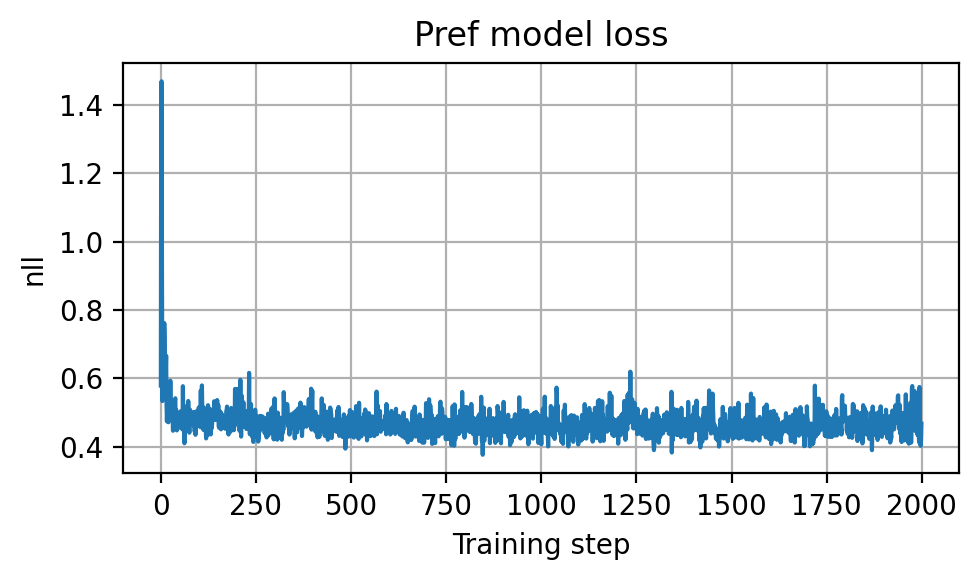

Dataset composition (likes/dislikes):   0.6890649795532227 / 0.31093502044677734
ACC(learned vs GT):   0.870199978351593 / 0.7949949502944946


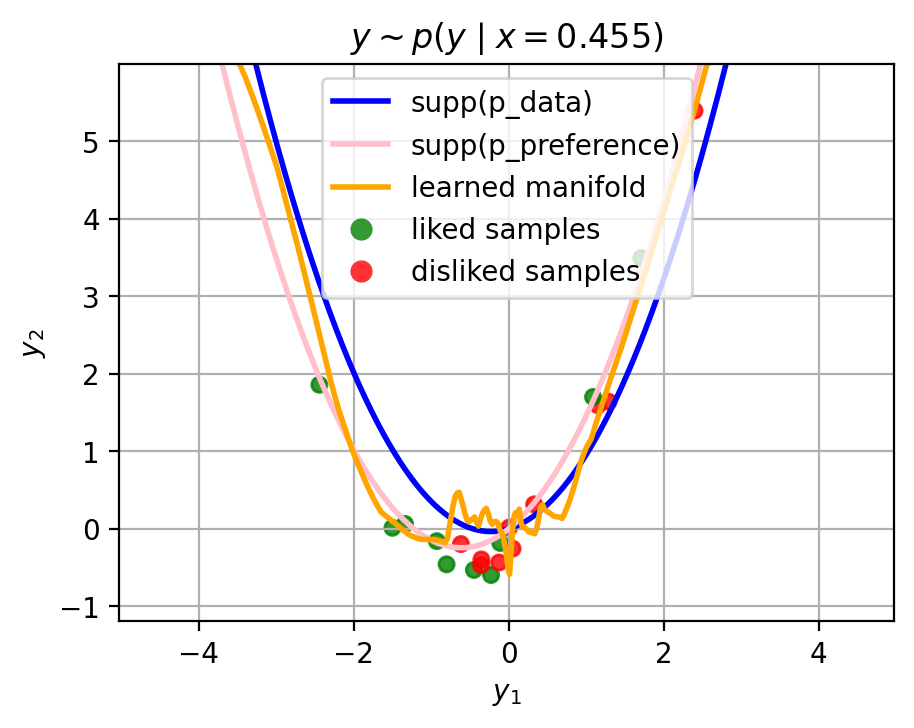

[1/1000] loss = -64.5543
[2/1000] loss = -64.6944
[3/1000] loss = -65.6407
[4/1000] loss = -66.6009
[5/1000] loss = -66.9050
[6/1000] loss = -67.1367
[7/1000] loss = -68.0012
[8/1000] loss = -68.1408
[9/1000] loss = -68.1791
[10/1000] loss = -68.6968
[11/1000] loss = -68.8183
[12/1000] loss = -68.7601
[13/1000] loss = -68.8864
[14/1000] loss = -68.9911
[15/1000] loss = -69.1083
[16/1000] loss = -69.1470
[17/1000] loss = -69.1321
[18/1000] loss = -69.3512
[19/1000] loss = -69.3774
[20/1000] loss = -69.3576
[21/1000] loss = -69.2502
[22/1000] loss = -69.3555
[23/1000] loss = -69.6575
[24/1000] loss = -69.5221
[25/1000] loss = -69.4680
[26/1000] loss = -69.6651
[27/1000] loss = -69.7944
[28/1000] loss = -69.6115
[29/1000] loss = -69.6786
[30/1000] loss = -69.7401
[31/1000] loss = -69.7294
[32/1000] loss = -69.6004
[33/1000] loss = -69.8715
[34/1000] loss = -69.6501
[35/1000] loss = -69.5524
[36/1000] loss = -69.5089
[37/1000] loss = -69.7142
[38/1000] loss = -69.6830
[39/1000] loss = -69.

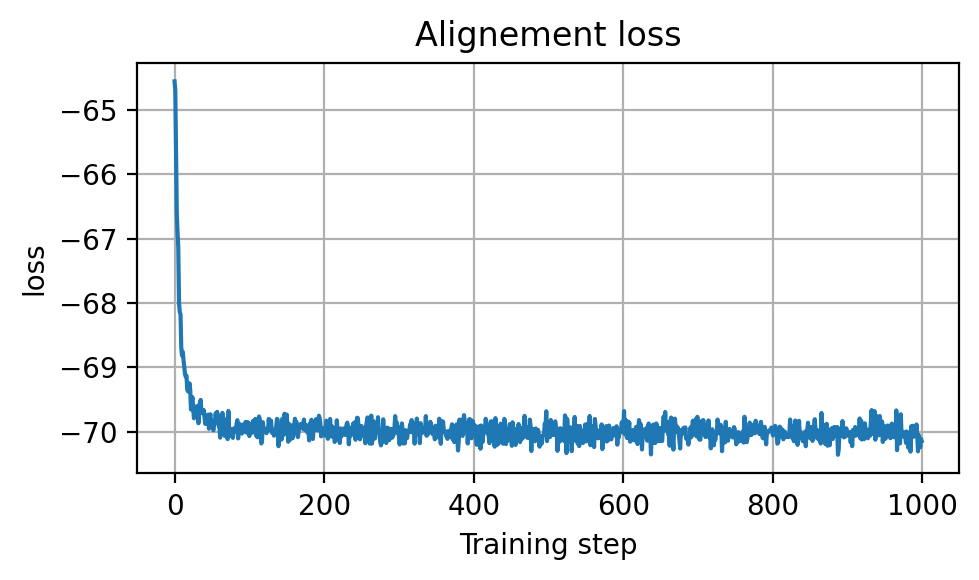

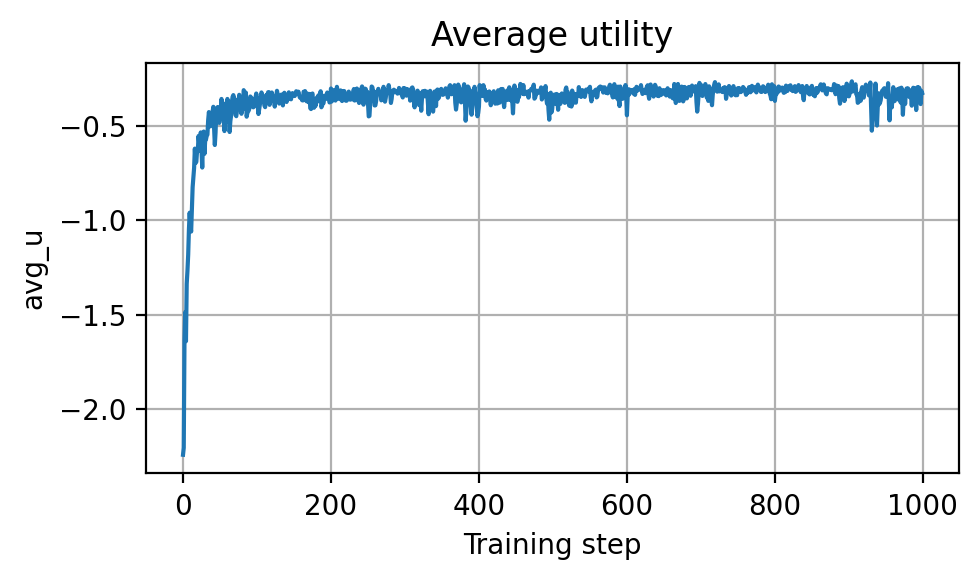

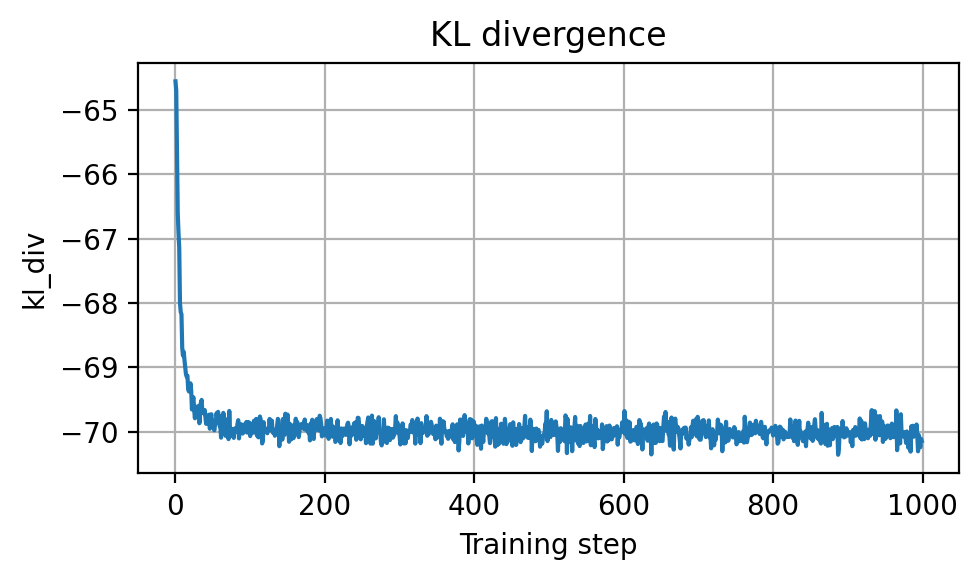

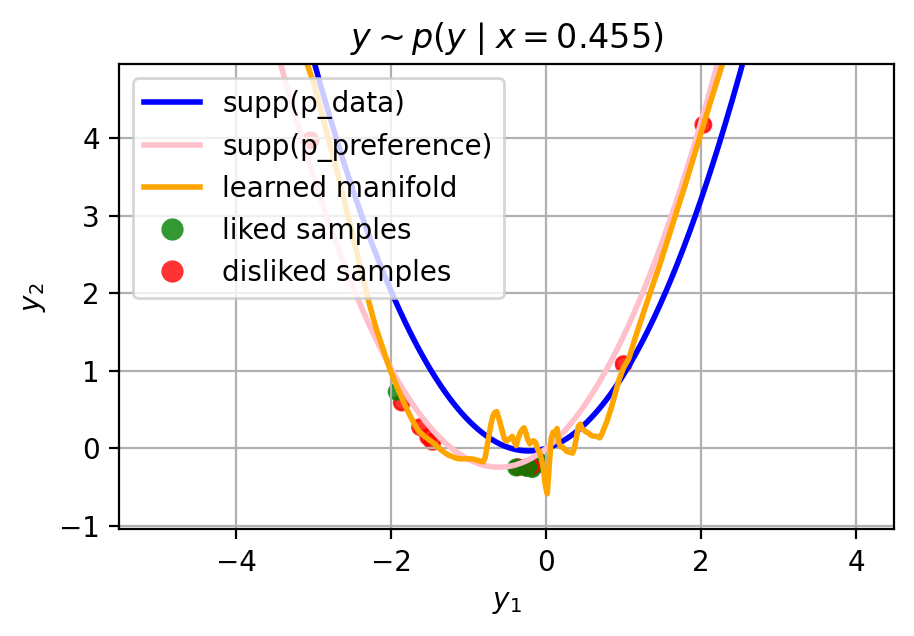

[1/4000] -ELBO = 8.531913757324219
[2/4000] -ELBO = 6.314279556274414
[3/4000] -ELBO = 6.536652088165283
[4/4000] -ELBO = 6.458141803741455
[5/4000] -ELBO = 6.079263687133789
[6/4000] -ELBO = 5.561448097229004
[7/4000] -ELBO = 5.569173336029053
[8/4000] -ELBO = 5.611410617828369
[9/4000] -ELBO = 5.437934398651123
[10/4000] -ELBO = 5.224417209625244
[11/4000] -ELBO = 5.177396774291992
[12/4000] -ELBO = 5.204747676849365
[13/4000] -ELBO = 5.1044602394104
[14/4000] -ELBO = 5.030918598175049
[15/4000] -ELBO = 4.969228744506836
[16/4000] -ELBO = 4.954951286315918
[17/4000] -ELBO = 4.920708656311035
[18/4000] -ELBO = 4.888485908508301
[19/4000] -ELBO = 4.853539943695068
[20/4000] -ELBO = 4.829521656036377
[21/4000] -ELBO = 4.803769588470459
[22/4000] -ELBO = 4.763113021850586
[23/4000] -ELBO = 4.756444931030273
[24/4000] -ELBO = 4.722949028015137
[25/4000] -ELBO = 4.70602560043335
[26/4000] -ELBO = 4.735105991363525
[27/4000] -ELBO = 4.712010860443115
[28/4000] -ELBO = 4.66554594039917
[29/4

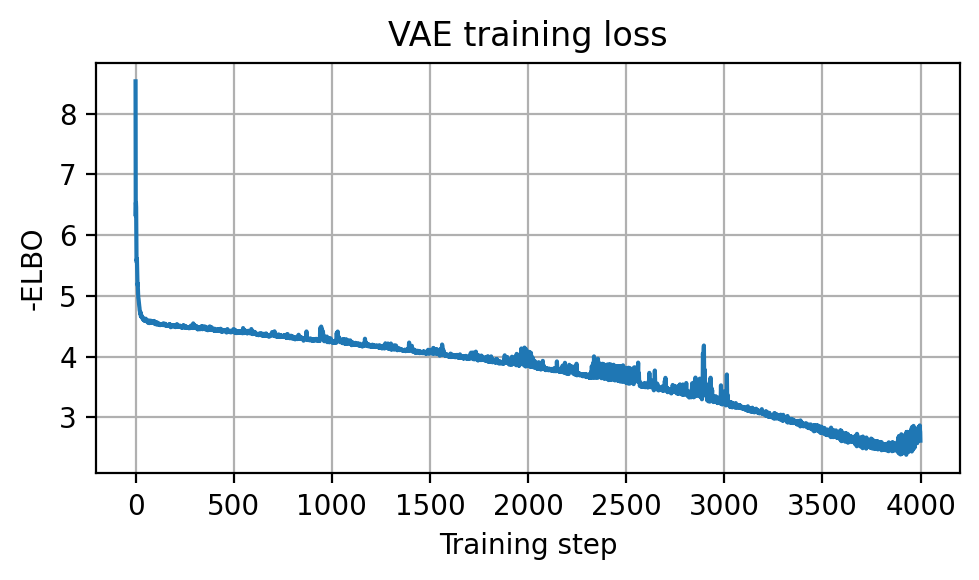

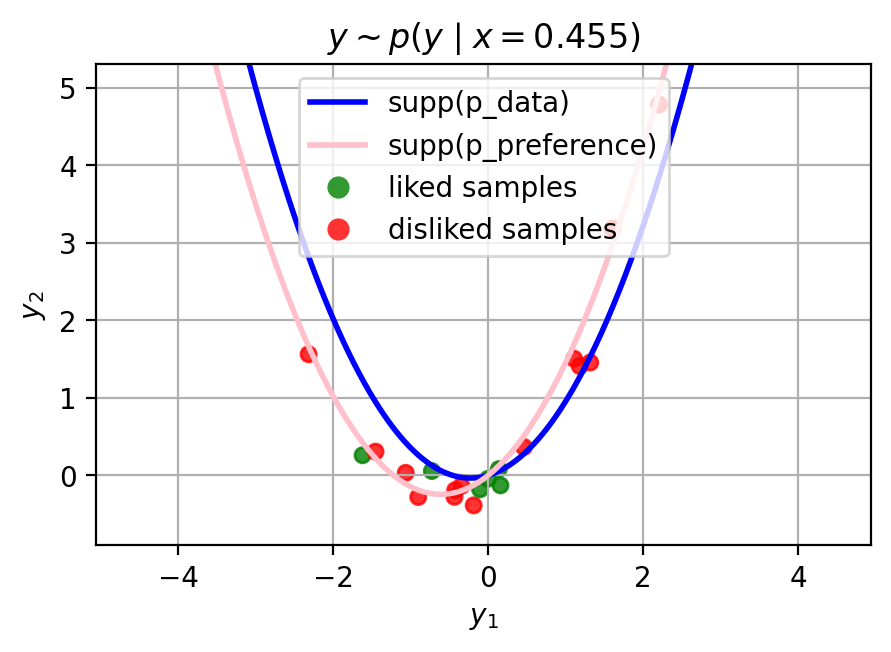

[1/2000] NLL = 0.5882
[2/2000] NLL = 2.3465
[3/2000] NLL = 2.3794
[4/2000] NLL = 1.1297
[5/2000] NLL = 1.0717
[6/2000] NLL = 0.8556
[7/2000] NLL = 0.9609
[8/2000] NLL = 0.7860
[9/2000] NLL = 0.6501
[10/2000] NLL = 0.6147
[11/2000] NLL = 0.7062
[12/2000] NLL = 0.5863
[13/2000] NLL = 0.5119
[14/2000] NLL = 0.5272
[15/2000] NLL = 0.5516
[16/2000] NLL = 0.6171
[17/2000] NLL = 0.5694
[18/2000] NLL = 0.5478
[19/2000] NLL = 0.5171
[20/2000] NLL = 0.5117
[21/2000] NLL = 0.5352
[22/2000] NLL = 0.5685
[23/2000] NLL = 0.5253
[24/2000] NLL = 0.5062
[25/2000] NLL = 0.5070
[26/2000] NLL = 0.4659
[27/2000] NLL = 0.4708
[28/2000] NLL = 0.5336
[29/2000] NLL = 0.4870
[30/2000] NLL = 0.5122
[31/2000] NLL = 0.4659
[32/2000] NLL = 0.4655
[33/2000] NLL = 0.4748
[34/2000] NLL = 0.5200
[35/2000] NLL = 0.4790
[36/2000] NLL = 0.5015
[37/2000] NLL = 0.4903
[38/2000] NLL = 0.4741
[39/2000] NLL = 0.4979
[40/2000] NLL = 0.4802
[41/2000] NLL = 0.4360
[42/2000] NLL = 0.4865
[43/2000] NLL = 0.5029
[44/2000] NLL = 0.45

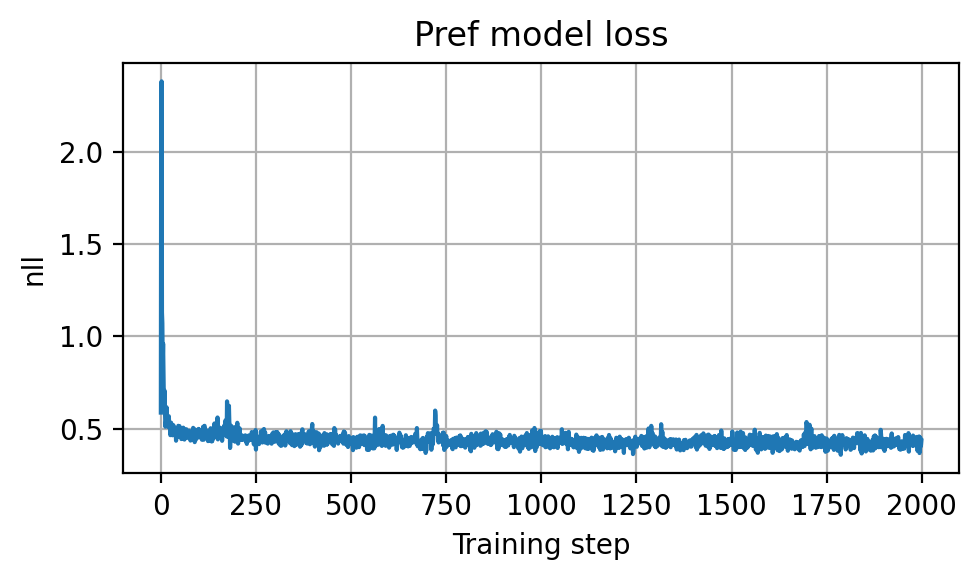

Dataset composition (likes/dislikes):   0.6490049958229065 / 0.3509950041770935
ACC(learned vs GT):   0.9551949501037598 / 0.7515699863433838


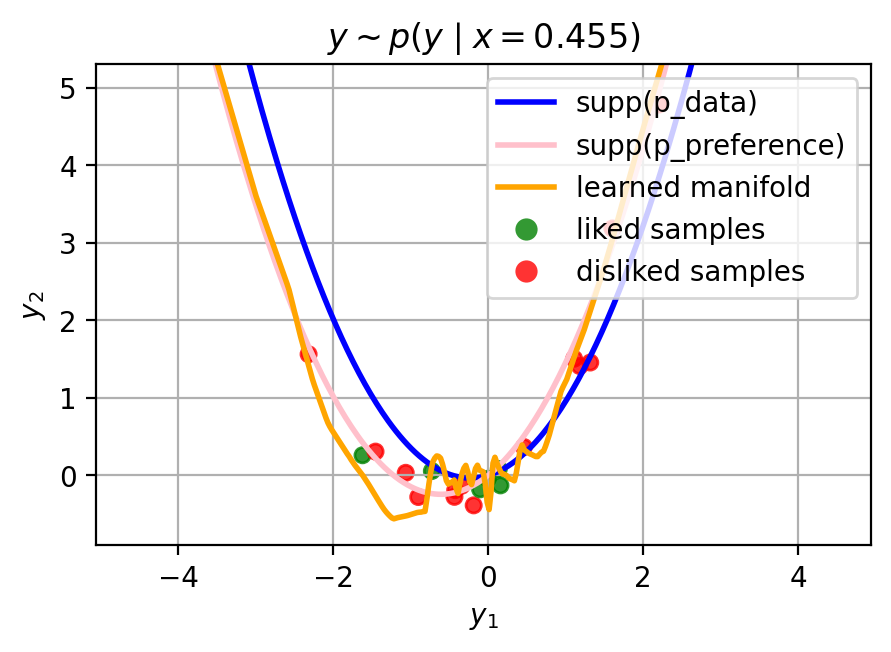

[1/1000] loss = -54.4630
[2/1000] loss = -58.7426
[3/1000] loss = -60.2586
[4/1000] loss = -60.8437
[5/1000] loss = -60.8793
[6/1000] loss = -61.6321
[7/1000] loss = -62.5900
[8/1000] loss = -63.8629
[9/1000] loss = -64.2482
[10/1000] loss = -64.4486
[11/1000] loss = -64.8627
[12/1000] loss = -65.2028
[13/1000] loss = -66.4874
[14/1000] loss = -66.1802
[15/1000] loss = -66.7446
[16/1000] loss = -67.0250
[17/1000] loss = -67.4728
[18/1000] loss = -67.2736
[19/1000] loss = -67.7873
[20/1000] loss = -68.2179
[21/1000] loss = -68.6028
[22/1000] loss = -68.7484
[23/1000] loss = -68.9636
[24/1000] loss = -69.2048
[25/1000] loss = -69.4898
[26/1000] loss = -69.8585
[27/1000] loss = -69.6979
[28/1000] loss = -69.7627
[29/1000] loss = -70.0404
[30/1000] loss = -70.3993
[31/1000] loss = -70.5042
[32/1000] loss = -70.4963
[33/1000] loss = -70.6671
[34/1000] loss = -70.7428
[35/1000] loss = -70.7299
[36/1000] loss = -70.8416
[37/1000] loss = -70.8899
[38/1000] loss = -71.0690
[39/1000] loss = -71.

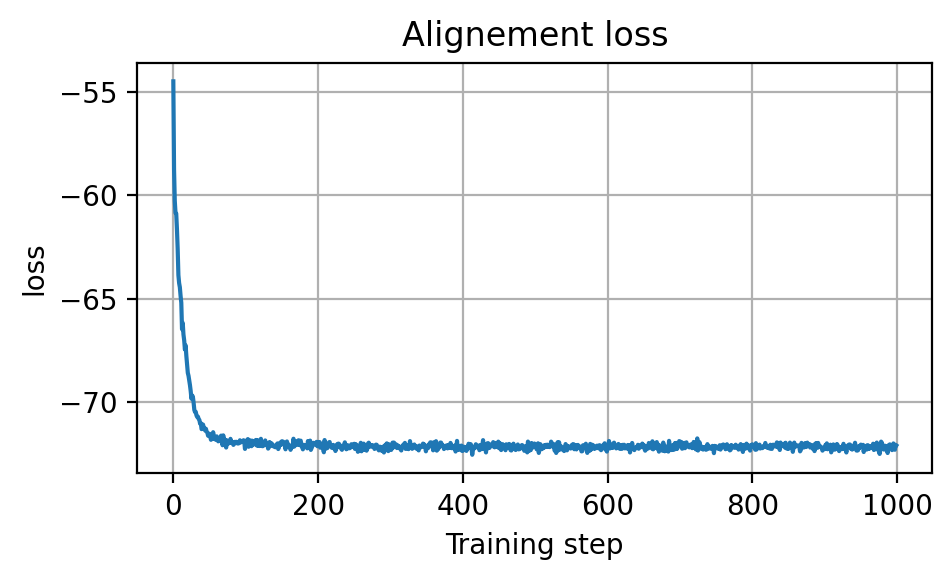

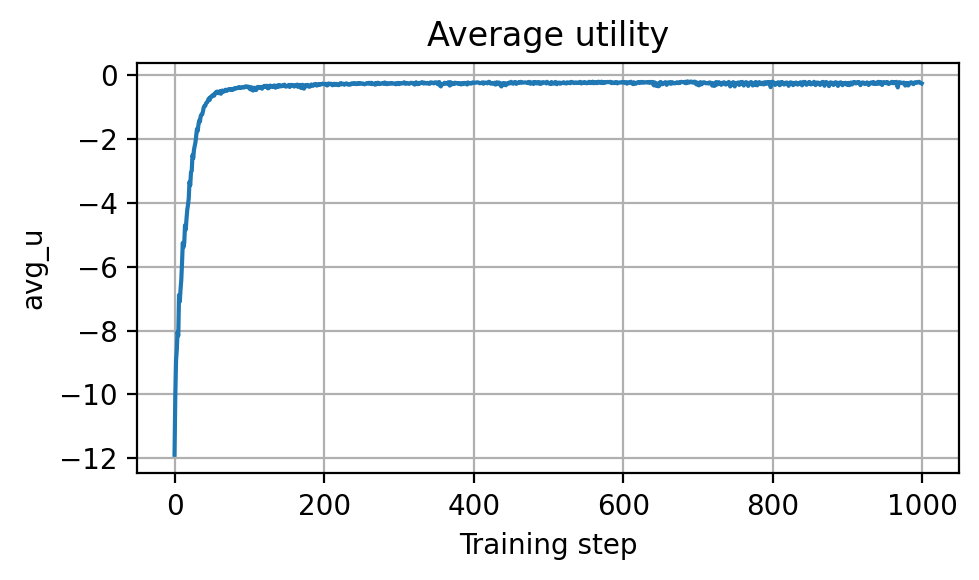

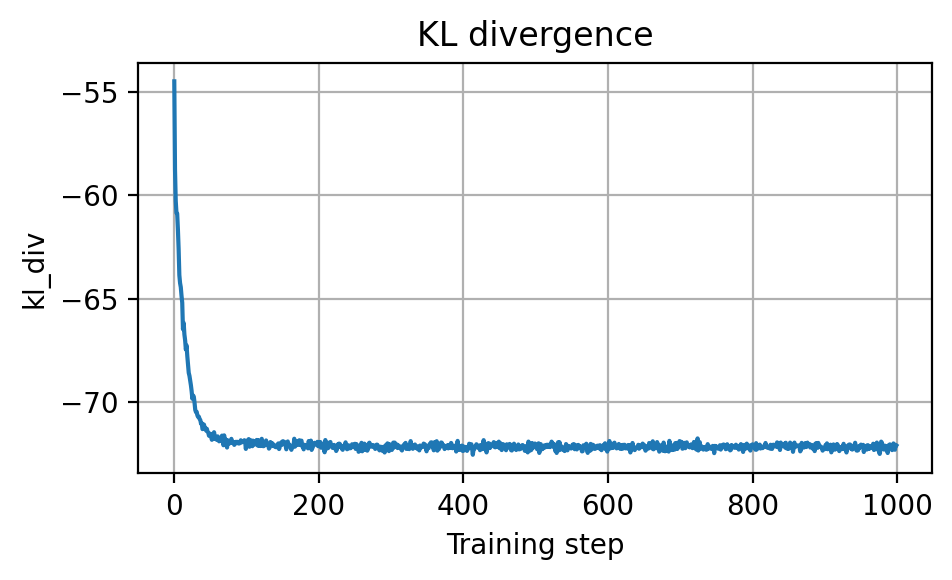

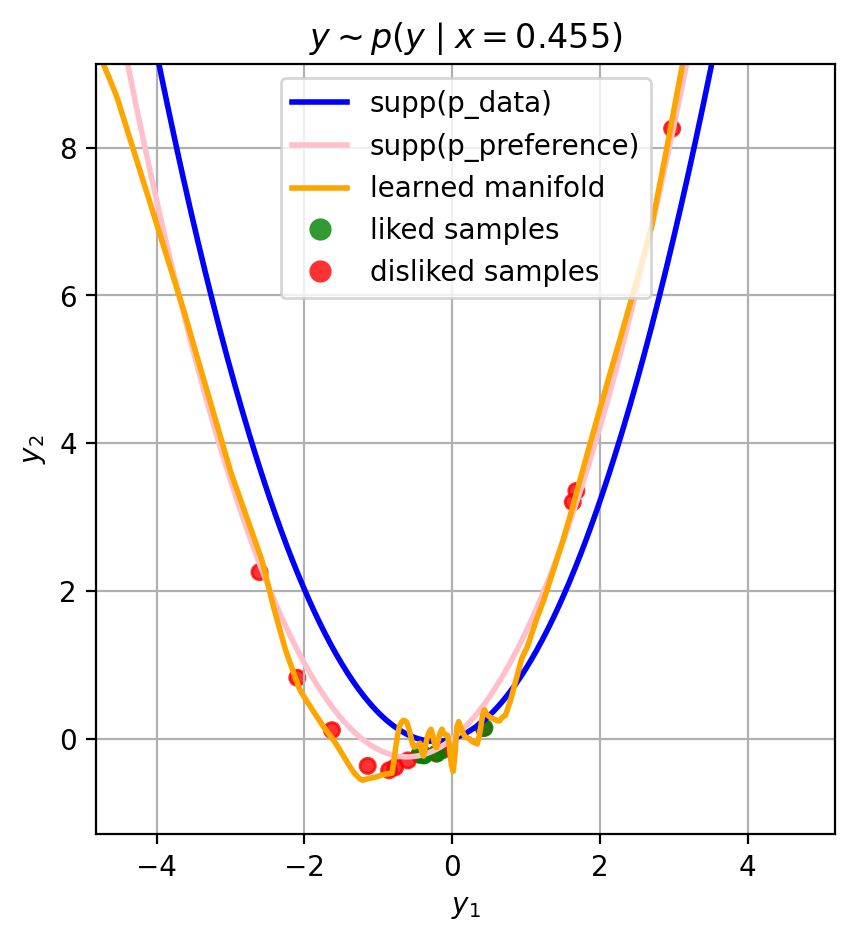

[1/4000] -ELBO = 10.632091522216797
[2/4000] -ELBO = 7.192724704742432
[3/4000] -ELBO = 6.51735782623291
[4/4000] -ELBO = 6.460881233215332
[5/4000] -ELBO = 6.322705268859863
[6/4000] -ELBO = 5.960123062133789
[7/4000] -ELBO = 5.578568458557129
[8/4000] -ELBO = 5.501873016357422
[9/4000] -ELBO = 5.5650153160095215
[10/4000] -ELBO = 5.4646992683410645
[11/4000] -ELBO = 5.266925811767578
[12/4000] -ELBO = 5.205856800079346
[13/4000] -ELBO = 5.125335693359375
[14/4000] -ELBO = 5.08234977722168
[15/4000] -ELBO = 5.014177322387695
[16/4000] -ELBO = 4.9724578857421875
[17/4000] -ELBO = 4.969627857208252
[18/4000] -ELBO = 4.906503200531006
[19/4000] -ELBO = 4.863346576690674
[20/4000] -ELBO = 4.852549076080322
[21/4000] -ELBO = 4.837052822113037
[22/4000] -ELBO = 4.8036041259765625
[23/4000] -ELBO = 4.793460369110107
[24/4000] -ELBO = 4.765974521636963
[25/4000] -ELBO = 4.762285232543945
[26/4000] -ELBO = 4.743896961212158
[27/4000] -ELBO = 4.726586818695068
[28/4000] -ELBO = 4.73419380187988

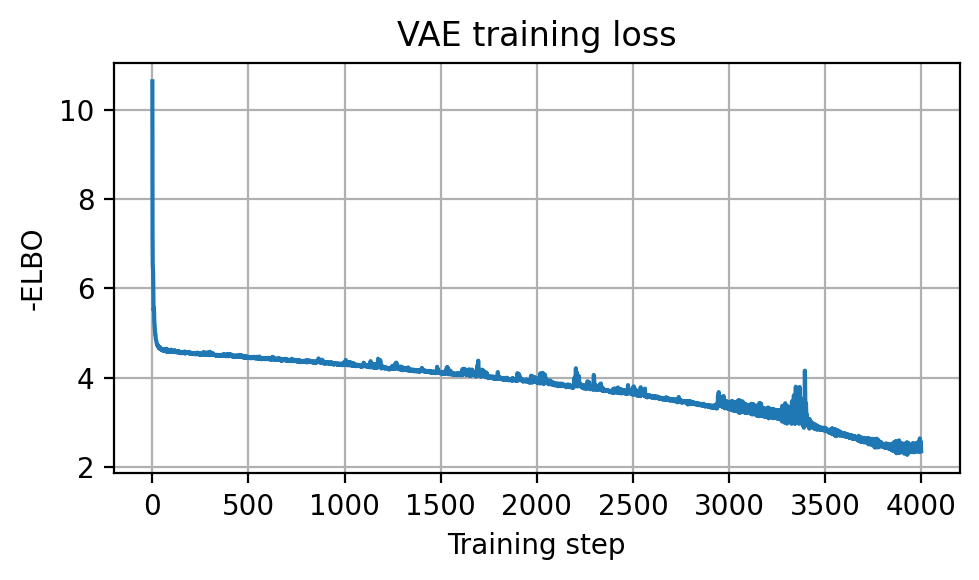

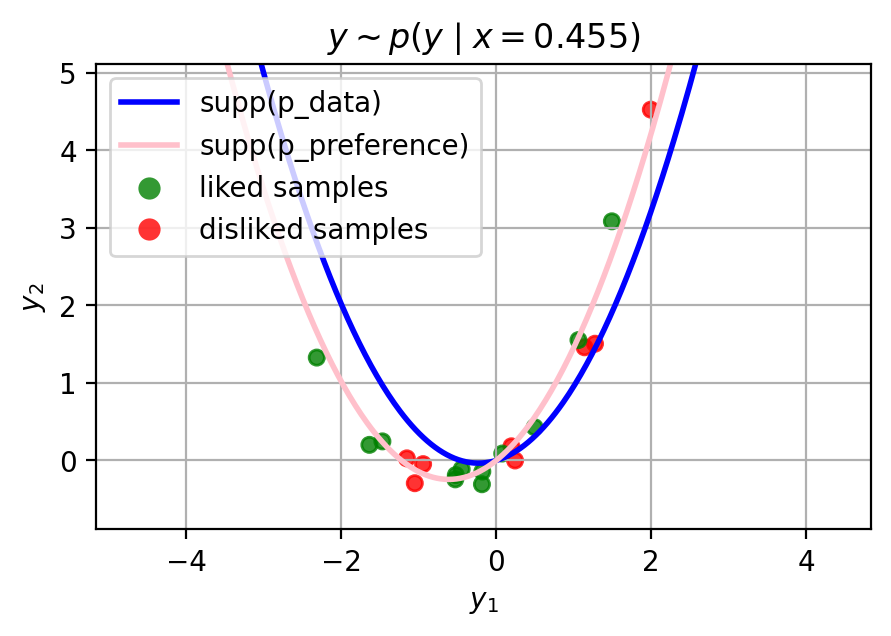

[1/2000] NLL = 0.4740
[2/2000] NLL = 1.3219
[3/2000] NLL = 0.8767
[4/2000] NLL = 0.6339
[5/2000] NLL = 0.4977
[6/2000] NLL = 0.4429
[7/2000] NLL = 0.5415
[8/2000] NLL = 0.6767
[9/2000] NLL = 0.5867
[10/2000] NLL = 0.5085
[11/2000] NLL = 0.4718
[12/2000] NLL = 0.4278
[13/2000] NLL = 0.4570
[14/2000] NLL = 0.5210
[15/2000] NLL = 0.5520
[16/2000] NLL = 0.4540
[17/2000] NLL = 0.4661
[18/2000] NLL = 0.4438
[19/2000] NLL = 0.4175
[20/2000] NLL = 0.4471
[21/2000] NLL = 0.4606
[22/2000] NLL = 0.4777
[23/2000] NLL = 0.4364
[24/2000] NLL = 0.4368
[25/2000] NLL = 0.4383
[26/2000] NLL = 0.4329
[27/2000] NLL = 0.4622
[28/2000] NLL = 0.5149
[29/2000] NLL = 0.4534
[30/2000] NLL = 0.4451
[31/2000] NLL = 0.4351
[32/2000] NLL = 0.4207
[33/2000] NLL = 0.4454
[34/2000] NLL = 0.4670
[35/2000] NLL = 0.4320
[36/2000] NLL = 0.4283
[37/2000] NLL = 0.4463
[38/2000] NLL = 0.4241
[39/2000] NLL = 0.4289
[40/2000] NLL = 0.4410
[41/2000] NLL = 0.4410
[42/2000] NLL = 0.4302
[43/2000] NLL = 0.4680
[44/2000] NLL = 0.41

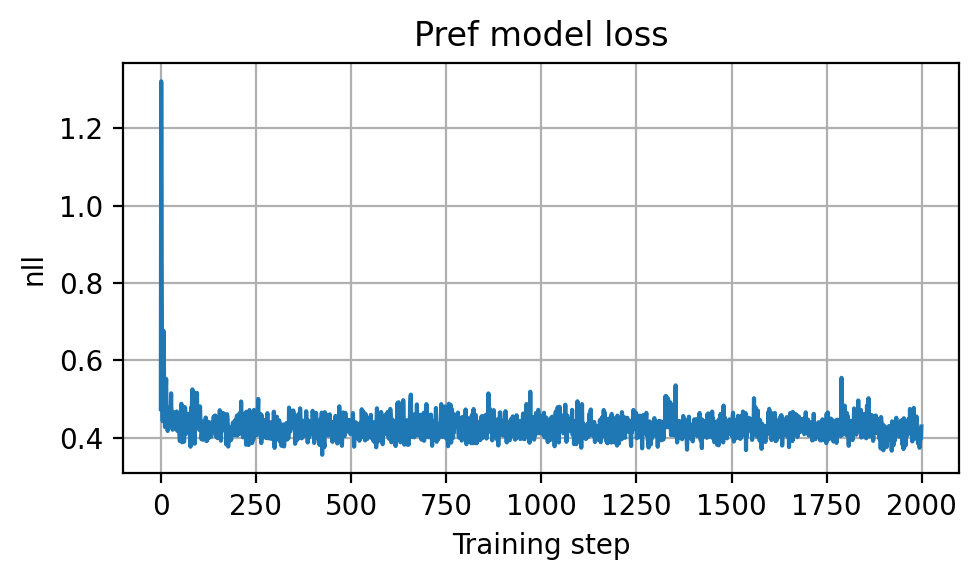

Dataset composition (likes/dislikes):   0.6391800045967102 / 0.3608199954032898
ACC(learned vs GT):   0.9614650011062622 / 0.730679988861084


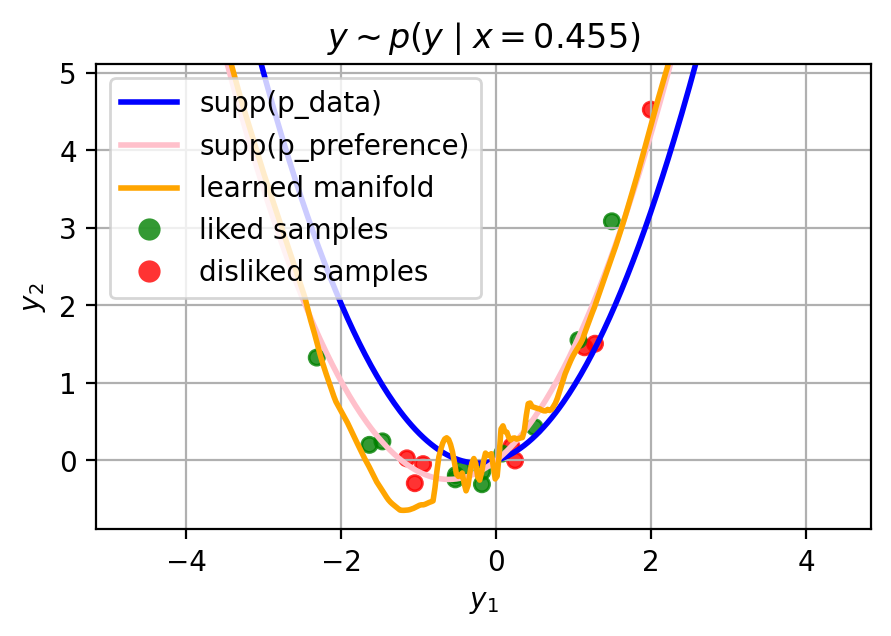

[1/1000] loss = -64.2453
[2/1000] loss = -66.1388
[3/1000] loss = -67.2524
[4/1000] loss = -68.0947
[5/1000] loss = -68.2873
[6/1000] loss = -69.3212
[7/1000] loss = -70.2859
[8/1000] loss = -70.7545
[9/1000] loss = -70.7696
[10/1000] loss = -71.2000
[11/1000] loss = -71.2757
[12/1000] loss = -71.8115
[13/1000] loss = -72.4522
[14/1000] loss = -72.2065
[15/1000] loss = -72.4681
[16/1000] loss = -72.9217
[17/1000] loss = -72.9336
[18/1000] loss = -73.0598
[19/1000] loss = -73.2402
[20/1000] loss = -73.1805
[21/1000] loss = -73.5396
[22/1000] loss = -73.4250
[23/1000] loss = -73.5626
[24/1000] loss = -73.3877
[25/1000] loss = -73.5684
[26/1000] loss = -73.5803
[27/1000] loss = -73.6347
[28/1000] loss = -73.9470
[29/1000] loss = -73.9428
[30/1000] loss = -73.9883
[31/1000] loss = -73.8730
[32/1000] loss = -74.0279
[33/1000] loss = -74.0218
[34/1000] loss = -74.0493
[35/1000] loss = -73.9155
[36/1000] loss = -73.9678
[37/1000] loss = -74.0499
[38/1000] loss = -73.8479
[39/1000] loss = -73.

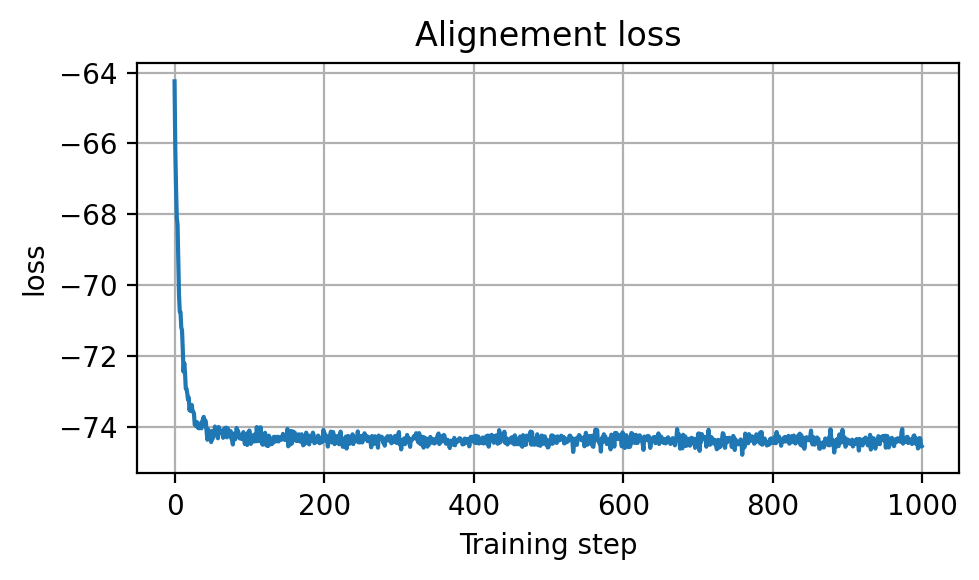

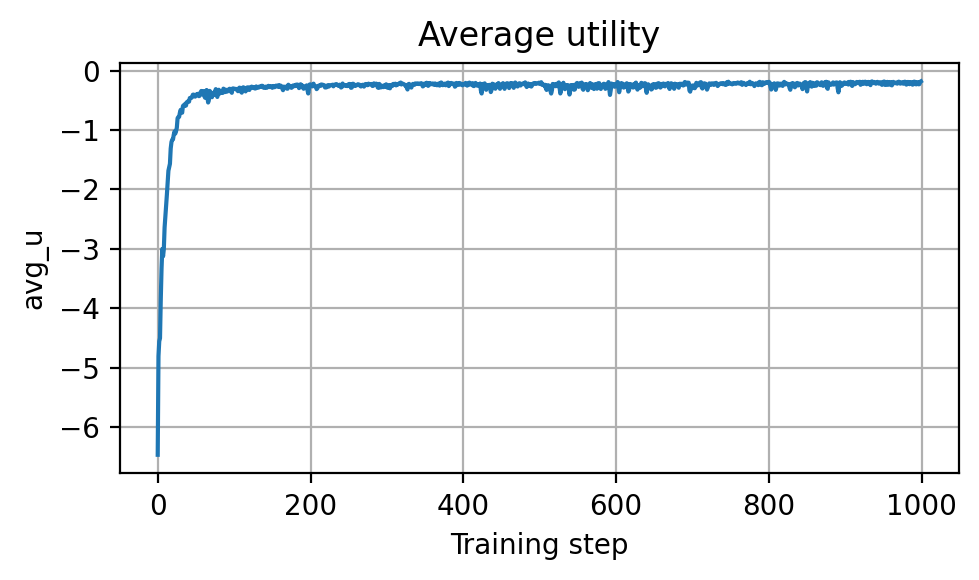

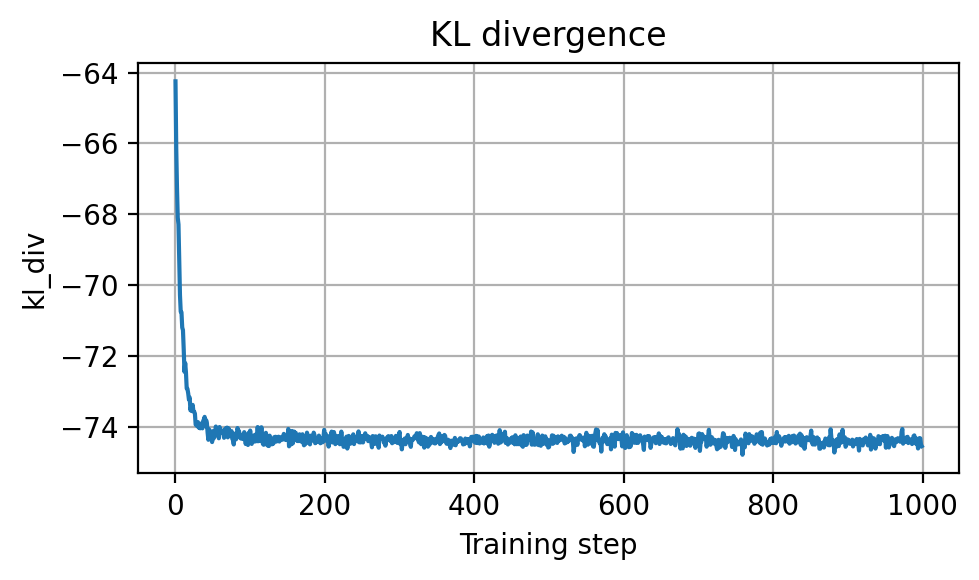

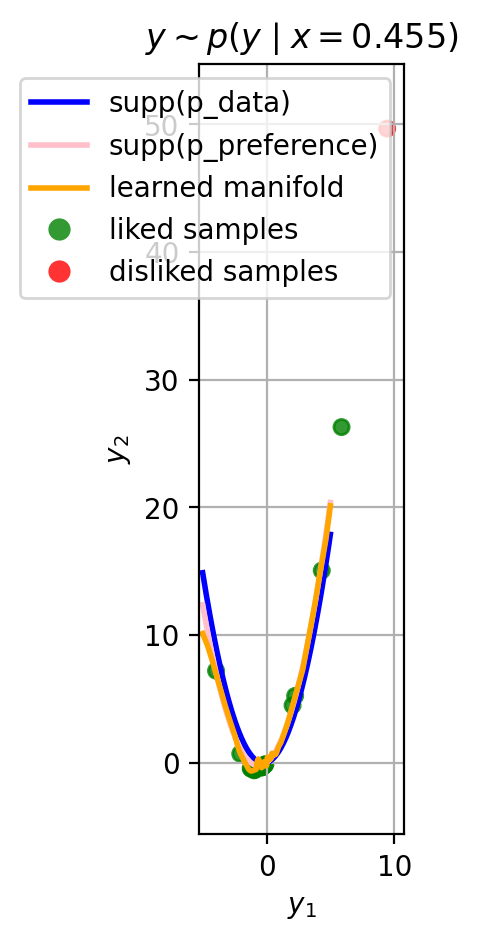

[1/4000] -ELBO = 8.29715633392334
[2/4000] -ELBO = 6.405167102813721
[3/4000] -ELBO = 6.593474864959717
[4/4000] -ELBO = 6.5196099281311035
[5/4000] -ELBO = 6.069532871246338
[6/4000] -ELBO = 5.729569911956787
[7/4000] -ELBO = 5.693935871124268
[8/4000] -ELBO = 5.598559379577637
[9/4000] -ELBO = 5.39007043838501
[10/4000] -ELBO = 5.290004730224609
[11/4000] -ELBO = 5.271853923797607
[12/4000] -ELBO = 5.198723316192627
[13/4000] -ELBO = 5.151005744934082
[14/4000] -ELBO = 5.162148475646973
[15/4000] -ELBO = 5.096004486083984
[16/4000] -ELBO = 5.029023170471191
[17/4000] -ELBO = 4.970344543457031
[18/4000] -ELBO = 4.952755451202393
[19/4000] -ELBO = 4.916679382324219
[20/4000] -ELBO = 4.895695686340332
[21/4000] -ELBO = 4.876869201660156
[22/4000] -ELBO = 4.8320207595825195
[23/4000] -ELBO = 4.852499485015869
[24/4000] -ELBO = 4.839667797088623
[25/4000] -ELBO = 4.804540157318115
[26/4000] -ELBO = 4.803821563720703
[27/4000] -ELBO = 4.801245212554932
[28/4000] -ELBO = 4.780629634857178
[

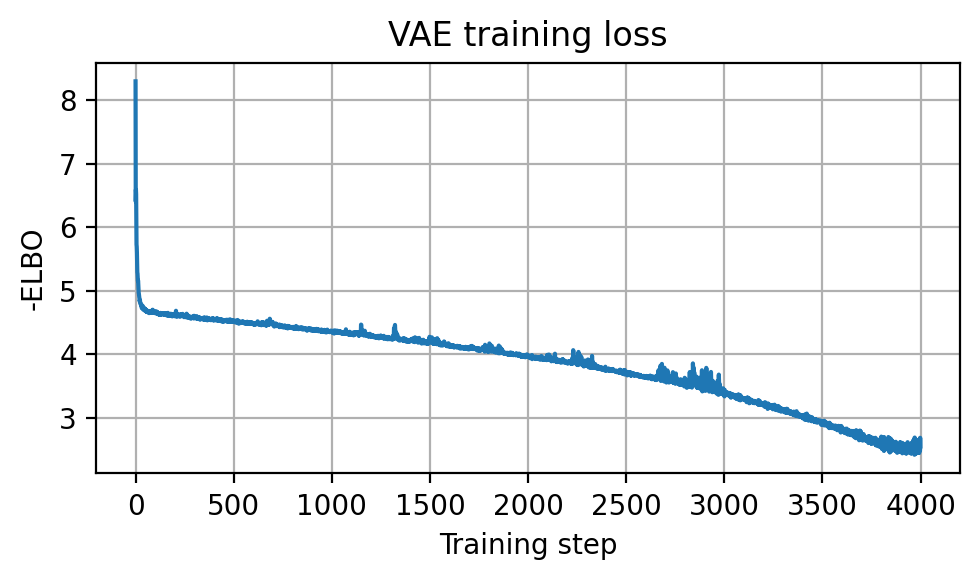

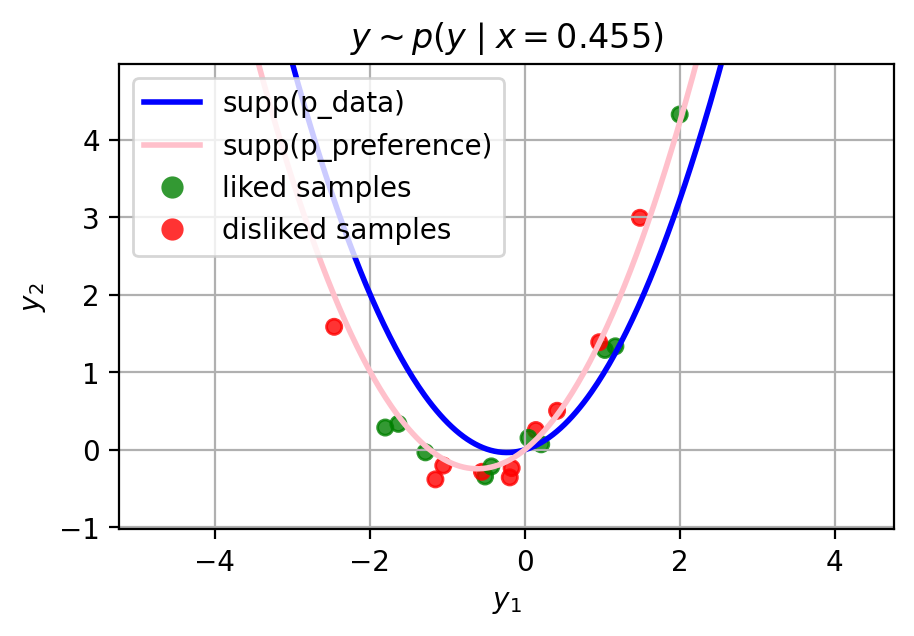

[1/2000] NLL = 0.4646
[2/2000] NLL = 0.5493
[3/2000] NLL = 0.4737
[4/2000] NLL = 0.5054
[5/2000] NLL = 0.4746
[6/2000] NLL = 0.4519
[7/2000] NLL = 0.4415
[8/2000] NLL = 0.4135
[9/2000] NLL = 0.4440
[10/2000] NLL = 0.4801
[11/2000] NLL = 0.4083
[12/2000] NLL = 0.4207
[13/2000] NLL = 0.4000
[14/2000] NLL = 0.4875
[15/2000] NLL = 0.4755
[16/2000] NLL = 0.4663
[17/2000] NLL = 0.4347
[18/2000] NLL = 0.4504
[19/2000] NLL = 0.4590
[20/2000] NLL = 0.4436
[21/2000] NLL = 0.4547
[22/2000] NLL = 0.4627
[23/2000] NLL = 0.4297
[24/2000] NLL = 0.4033
[25/2000] NLL = 0.4310
[26/2000] NLL = 0.4357
[27/2000] NLL = 0.4169
[28/2000] NLL = 0.4387
[29/2000] NLL = 0.4606
[30/2000] NLL = 0.4534
[31/2000] NLL = 0.4655
[32/2000] NLL = 0.4523
[33/2000] NLL = 0.4848
[34/2000] NLL = 0.4295
[35/2000] NLL = 0.4312
[36/2000] NLL = 0.4145
[37/2000] NLL = 0.4640
[38/2000] NLL = 0.4390
[39/2000] NLL = 0.4788
[40/2000] NLL = 0.4378
[41/2000] NLL = 0.4637
[42/2000] NLL = 0.4302
[43/2000] NLL = 0.4466
[44/2000] NLL = 0.44

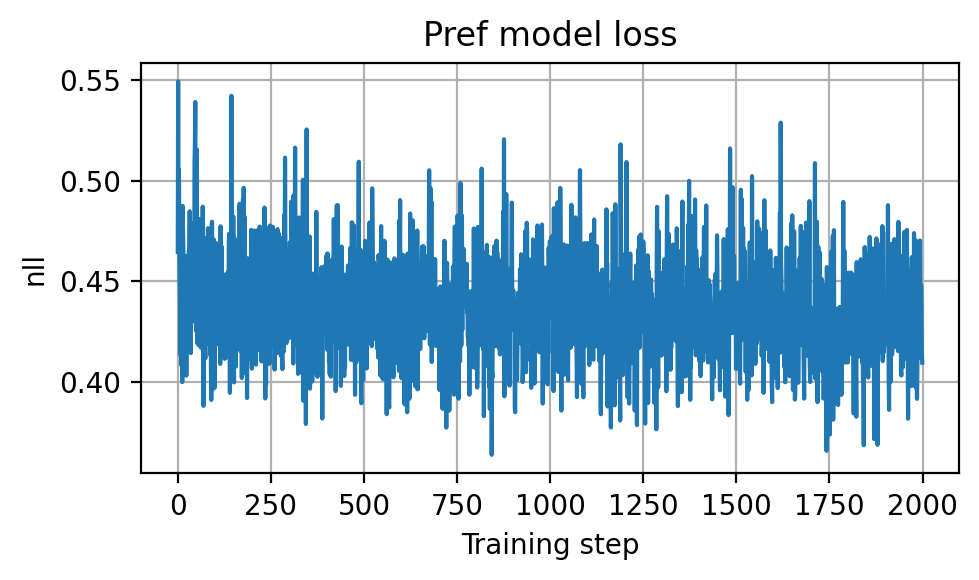

Dataset composition (likes/dislikes):   0.6420449614524841 / 0.35795503854751587
ACC(learned vs GT):   0.9113099575042725 / 0.7254649996757507


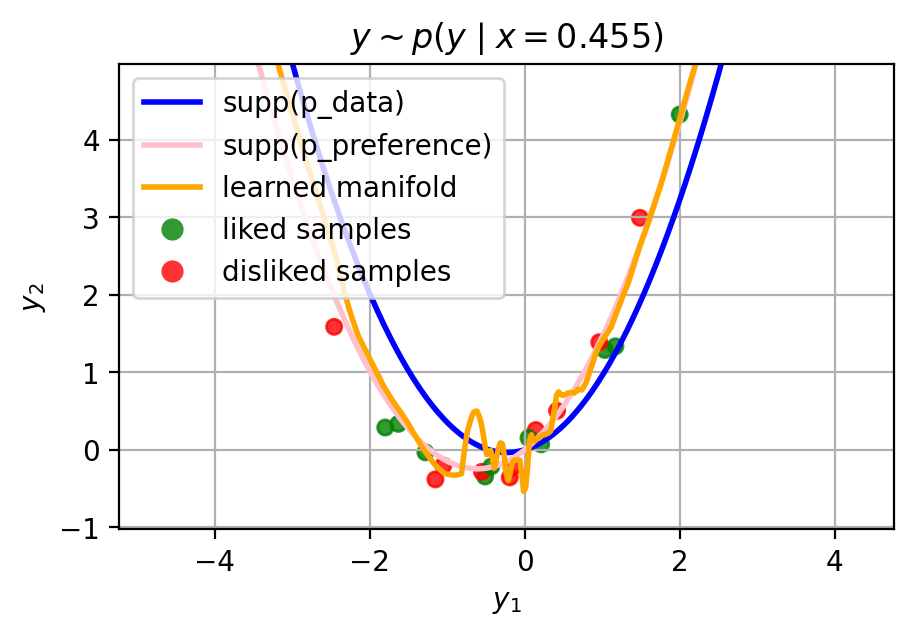

[1/1000] loss = -73.2011
[2/1000] loss = -73.3893
[3/1000] loss = -73.6769
[4/1000] loss = -74.1841
[5/1000] loss = -74.6384
[6/1000] loss = -75.0416
[7/1000] loss = -75.5594
[8/1000] loss = -75.2870
[9/1000] loss = -75.4517
[10/1000] loss = -75.7474
[11/1000] loss = -75.5507
[12/1000] loss = -75.9104
[13/1000] loss = -76.0849
[14/1000] loss = -76.2698
[15/1000] loss = -76.3217
[16/1000] loss = -76.4316
[17/1000] loss = -76.4233
[18/1000] loss = -76.5762
[19/1000] loss = -76.4914
[20/1000] loss = -76.3255
[21/1000] loss = -76.4578
[22/1000] loss = -76.5608
[23/1000] loss = -76.6174
[24/1000] loss = -76.6696
[25/1000] loss = -76.6943
[26/1000] loss = -76.5472
[27/1000] loss = -76.6652
[28/1000] loss = -76.9026
[29/1000] loss = -77.0314
[30/1000] loss = -76.8399
[31/1000] loss = -76.9296
[32/1000] loss = -76.7103
[33/1000] loss = -77.0204
[34/1000] loss = -76.8530
[35/1000] loss = -76.9614
[36/1000] loss = -76.8482
[37/1000] loss = -76.8328
[38/1000] loss = -76.8785
[39/1000] loss = -76.

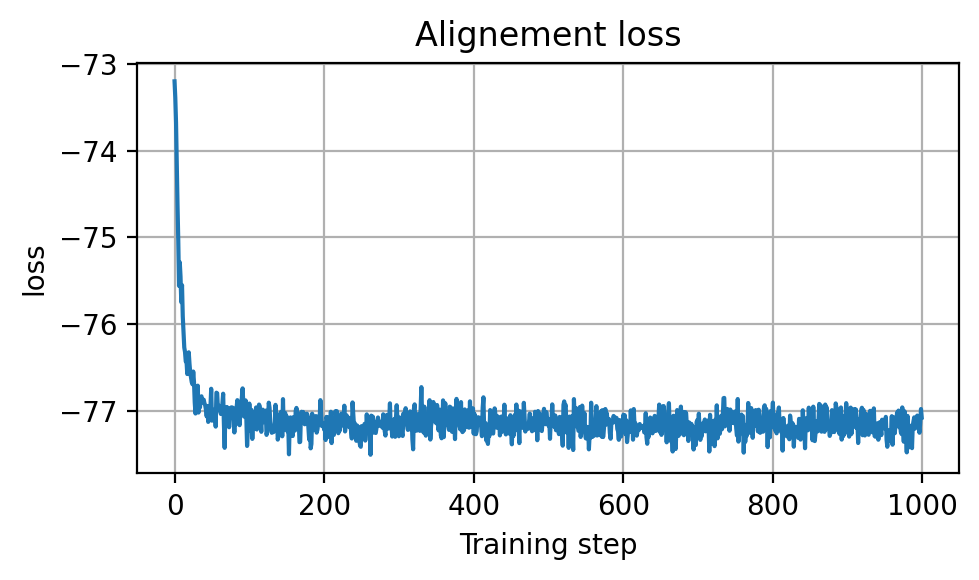

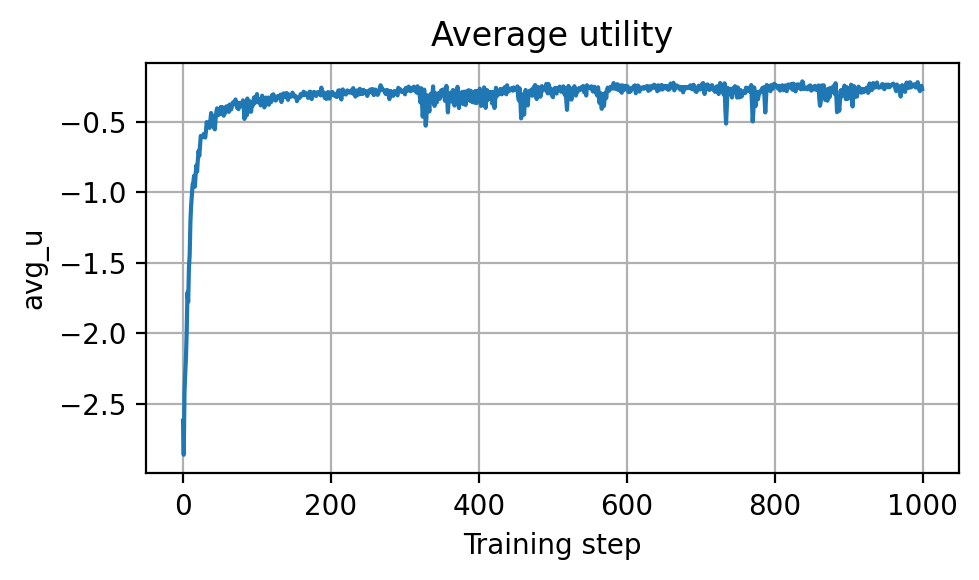

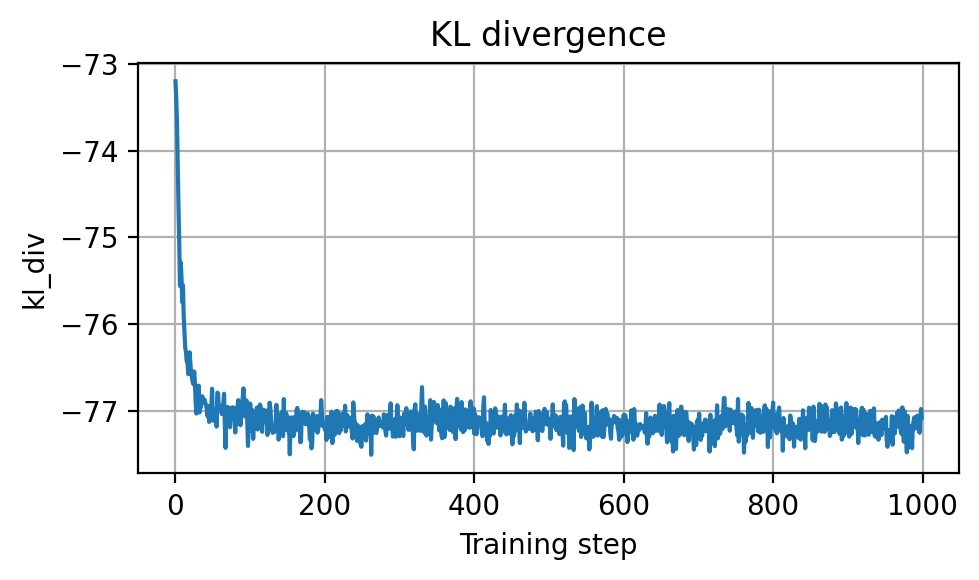

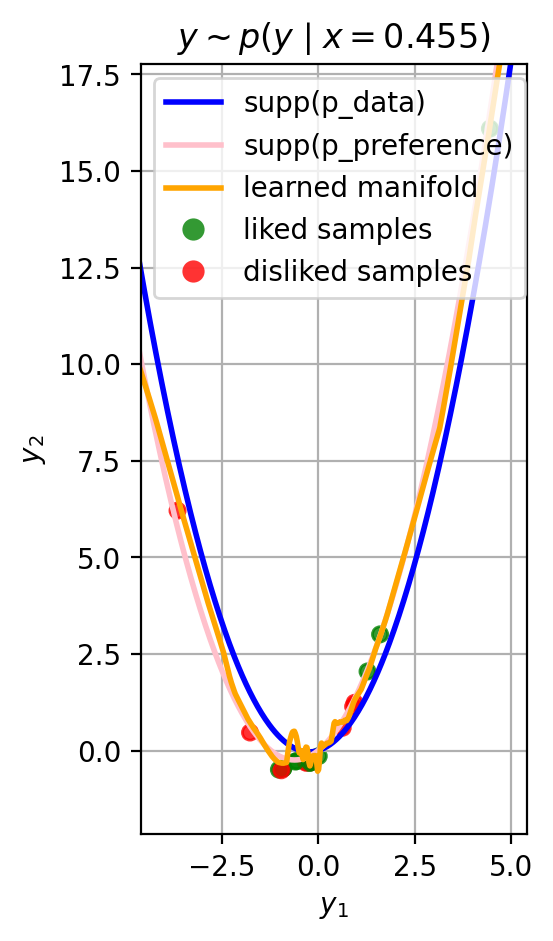

[1/4000] -ELBO = 7.894896507263184
[2/4000] -ELBO = 6.461743354797363
[3/4000] -ELBO = 6.43073844909668
[4/4000] -ELBO = 6.254352569580078
[5/4000] -ELBO = 5.892650604248047
[6/4000] -ELBO = 5.830803871154785
[7/4000] -ELBO = 5.846798896789551
[8/4000] -ELBO = 5.695532321929932
[9/4000] -ELBO = 5.489634037017822
[10/4000] -ELBO = 5.3362250328063965
[11/4000] -ELBO = 5.328643798828125
[12/4000] -ELBO = 5.314334869384766
[13/4000] -ELBO = 5.202523231506348
[14/4000] -ELBO = 5.165368556976318
[15/4000] -ELBO = 5.135695934295654
[16/4000] -ELBO = 5.0837202072143555
[17/4000] -ELBO = 5.0268988609313965
[18/4000] -ELBO = 4.980137348175049
[19/4000] -ELBO = 4.946760177612305
[20/4000] -ELBO = 4.9067888259887695
[21/4000] -ELBO = 4.92002534866333
[22/4000] -ELBO = 4.906205177307129
[23/4000] -ELBO = 4.857850074768066
[24/4000] -ELBO = 4.85735559463501
[25/4000] -ELBO = 4.837198257446289
[26/4000] -ELBO = 4.822170734405518
[27/4000] -ELBO = 4.819241046905518
[28/4000] -ELBO = 4.808842658996582


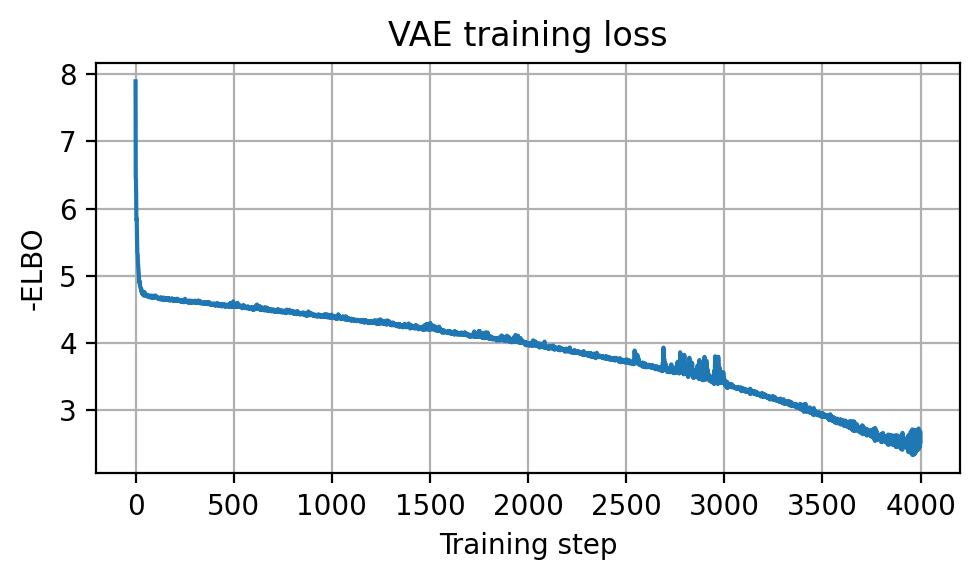

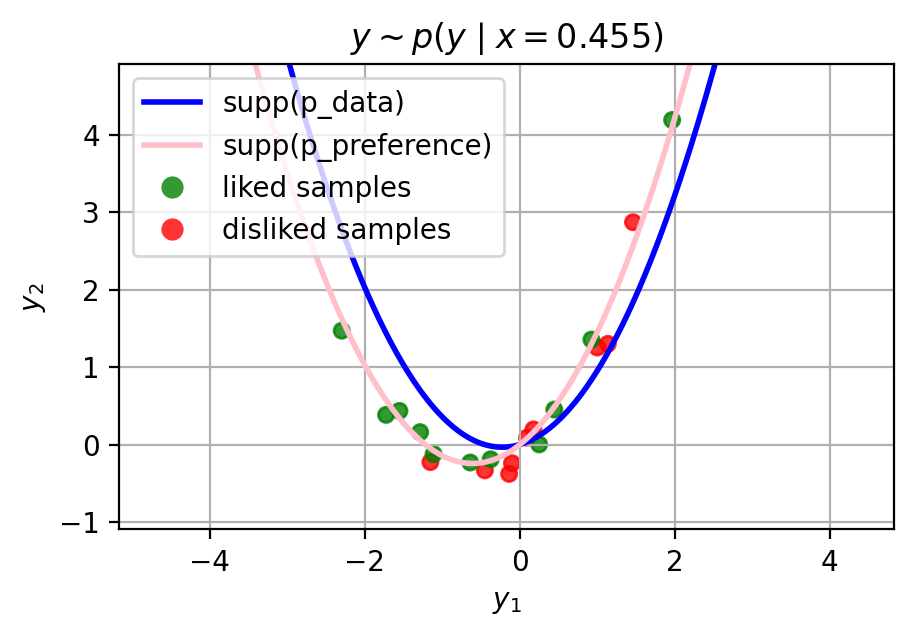

[1/2000] NLL = 0.4703
[2/2000] NLL = 1.4037
[3/2000] NLL = 1.1878
[4/2000] NLL = 0.6469
[5/2000] NLL = 0.7216
[6/2000] NLL = 0.6488
[7/2000] NLL = 0.5732
[8/2000] NLL = 0.5626
[9/2000] NLL = 0.5584
[10/2000] NLL = 0.6255
[11/2000] NLL = 0.6240
[12/2000] NLL = 0.4607
[13/2000] NLL = 0.4855
[14/2000] NLL = 0.5267
[15/2000] NLL = 0.5345
[16/2000] NLL = 0.5010
[17/2000] NLL = 0.4867
[18/2000] NLL = 0.4827
[19/2000] NLL = 0.4614
[20/2000] NLL = 0.4761
[21/2000] NLL = 0.4421
[22/2000] NLL = 0.4747
[23/2000] NLL = 0.4831
[24/2000] NLL = 0.4520
[25/2000] NLL = 0.4918
[26/2000] NLL = 0.4584
[27/2000] NLL = 0.5014
[28/2000] NLL = 0.4753
[29/2000] NLL = 0.4514
[30/2000] NLL = 0.4136
[31/2000] NLL = 0.4676
[32/2000] NLL = 0.4829
[33/2000] NLL = 0.4502
[34/2000] NLL = 0.4167
[35/2000] NLL = 0.4619
[36/2000] NLL = 0.4820
[37/2000] NLL = 0.4671
[38/2000] NLL = 0.4307
[39/2000] NLL = 0.4793
[40/2000] NLL = 0.4975
[41/2000] NLL = 0.3962
[42/2000] NLL = 0.4566
[43/2000] NLL = 0.4286
[44/2000] NLL = 0.46

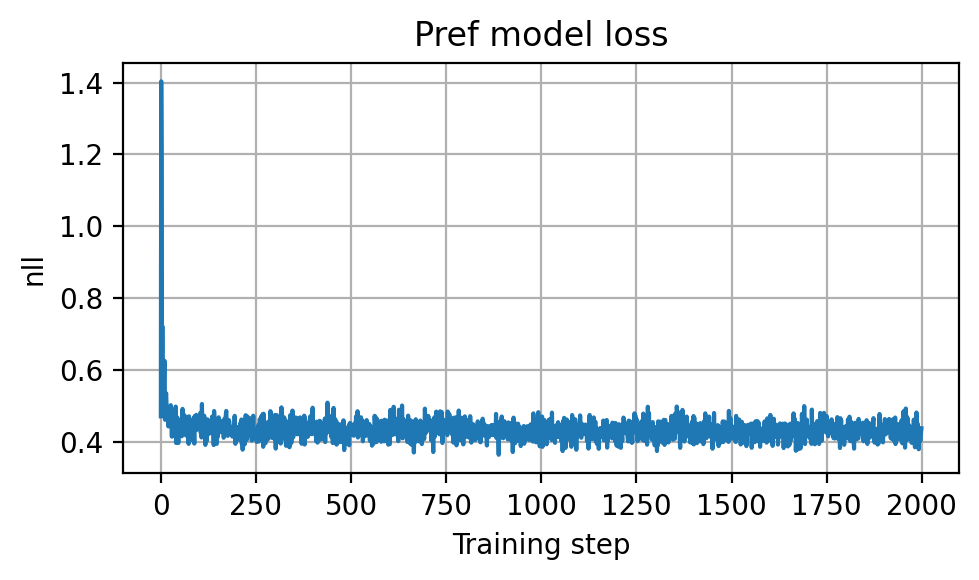

Dataset composition (likes/dislikes):   0.6474449634552002 / 0.3525550365447998
ACC(learned vs GT):   0.9269099831581116 / 0.7311399579048157


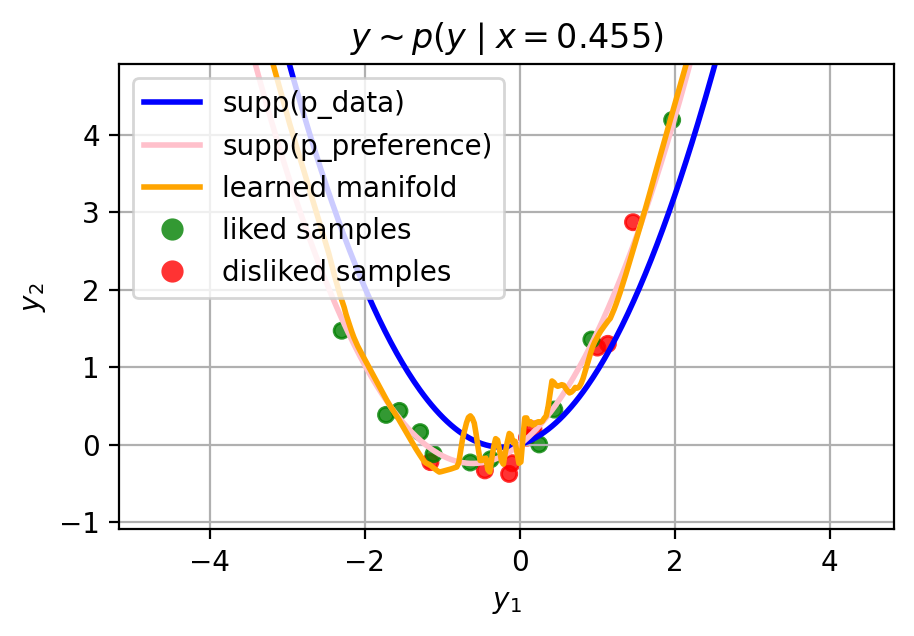

[1/1000] loss = -59.7194
[2/1000] loss = -69.0895
[3/1000] loss = -69.8587
[4/1000] loss = -70.2379
[5/1000] loss = -71.9856
[6/1000] loss = -73.3511
[7/1000] loss = -74.8929
[8/1000] loss = -74.9585
[9/1000] loss = -75.8568
[10/1000] loss = -76.3895
[11/1000] loss = -76.9567
[12/1000] loss = -77.1192
[13/1000] loss = -77.1151
[14/1000] loss = -77.6906
[15/1000] loss = -77.8196
[16/1000] loss = -77.7951
[17/1000] loss = -78.1673
[18/1000] loss = -78.0959
[19/1000] loss = -78.2340
[20/1000] loss = -78.4127
[21/1000] loss = -78.3936
[22/1000] loss = -78.3201
[23/1000] loss = -78.3405
[24/1000] loss = -78.5884
[25/1000] loss = -78.5965
[26/1000] loss = -78.6624
[27/1000] loss = -78.6584
[28/1000] loss = -78.5924
[29/1000] loss = -78.8020
[30/1000] loss = -78.7771
[31/1000] loss = -78.6948
[32/1000] loss = -78.6205
[33/1000] loss = -78.6069
[34/1000] loss = -78.6405
[35/1000] loss = -78.5117
[36/1000] loss = -78.6682
[37/1000] loss = -78.7147
[38/1000] loss = -78.8413
[39/1000] loss = -78.

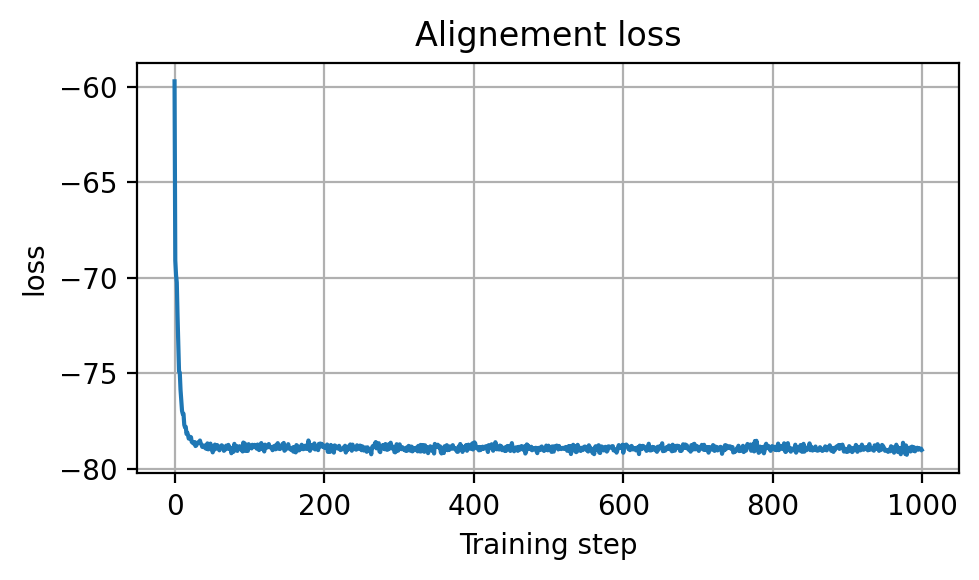

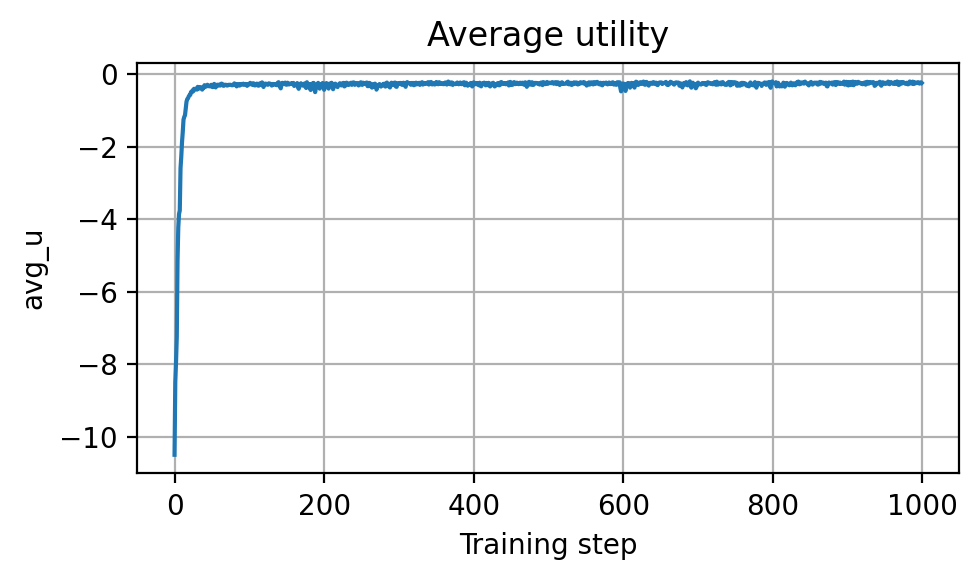

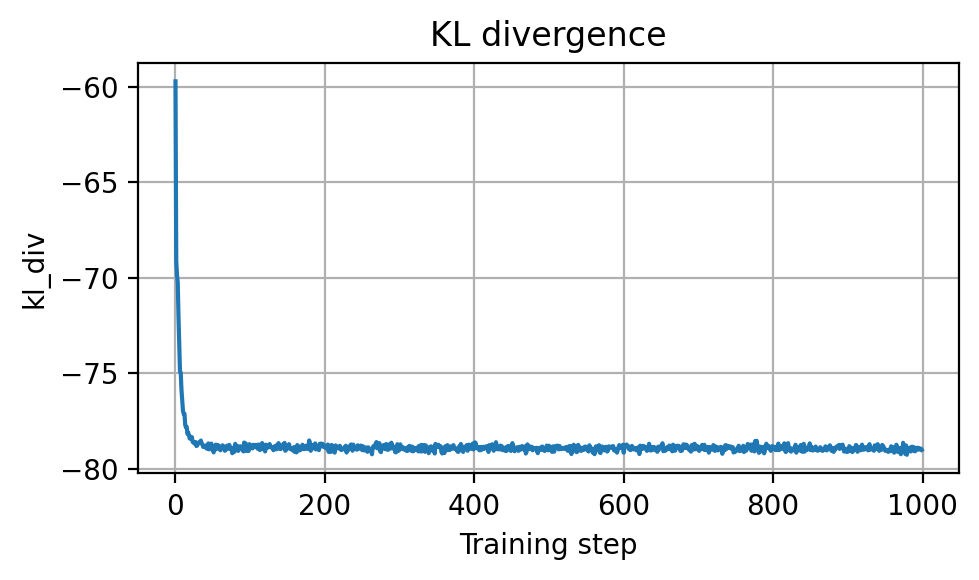

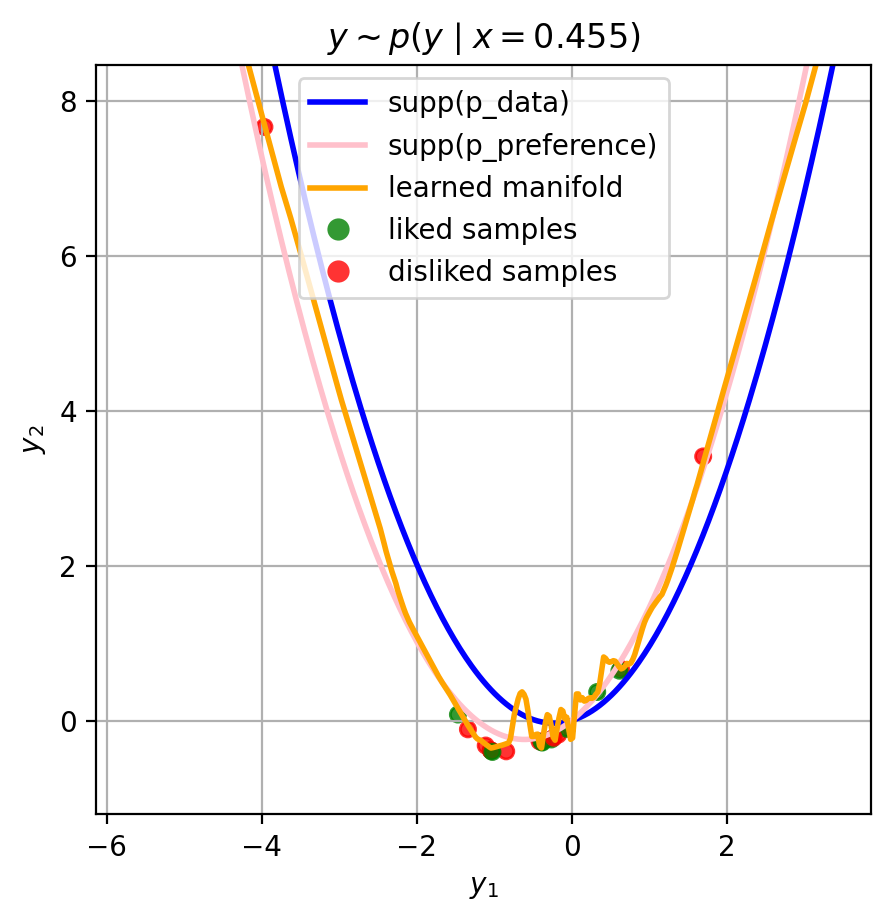

In [ ]:
for iter in range(num_iter):
    log_folder = Path(f"iter_{iter}")
    # Step 1: Pre-training
    #opt = optax.adam(pre_train_lr)
    opt = optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(pre_train_lr),
    )
    opt_state = opt.init(vae_params)

    loss_history = []

    for step in range(pre_train_epochs):
        key, subkey = jax.random.split(key)
        vae_params, opt_state, loss = pre_train_step(
            vae_params, step, opt_state, subkey, xs[:,0], jax.lax.stop_gradient(ys[:,0])
        )
        loss_val = float(loss)          # convert from JAX scalar
        loss_history.append(loss_val)

        print(f"[{step+1}/{pre_train_epochs}] -ELBO = {loss_val}")

    logger.log_data(vae_params, log_folder / "vae_params.npz")

    # Plot loss
    fig = plt.figure(figsize=(5, 3), dpi=200)
    plt.plot(loss_history)
    plt.xlabel("Training step")
    plt.ylabel("-ELBO")
    plt.title("VAE training loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    logger.log_data(fig, log_folder / "vae_pre_training_loss.png")

    ys = sample_many(vae_params, ys_key, xs[:,0], m)
    ys_query = ys[:n_queries]
    y_history.append(ys_query)   # ys for queries

    logits = logpdf_labels(
        xs,
        ys,
        alpha=target_p.alpha,
        beta=target_p.beta,
        gamma=target_p.gamma,
        tau=tau,
    )
    gt_labels = jax.random.categorical(
        l_key,
        logits,
        axis=-1,
    )
    ls = gt_labels[:n_queries]
    l_history.append(ls)   # labels used for queries

    if ys_tot is None:
        ys_tot = ys_query
        l_tot = ls
        xs_tot = xs[:n_queries]
    else:
        ys_tot = jnp.concatenate([ys_tot, ys_query], axis=0)
        l_tot = jnp.concatenate([l_tot, ls], axis=0)
        xs_tot = jnp.concatenate([xs_tot, xs[:n_queries]], axis=0)

    u = utility_vmapped(
        xs,
        ys,
        target_p.alpha,
        target_p.beta,
        target_p.gamma,
    )

    mean_u = jnp.mean(u)
    gt_u_history.append(mean_u)

    fig = task_vis.visualize(
        xs[0, 0, 0],
        ys[0],
        base_manifold=base_p,
        target_manifold=target_p,
        labels=gt_labels[0],
        scale="free"
    )
    logger.log_data(fig, log_folder / "pre_trained_samples.png")


    # Step 2: Learn preference model
    #opt = optax.adam(pref_lr)
    opt = optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(pref_lr),
    )
    opt_state = opt.init(pref_params)

    loss_history = []

    n_tot = xs_tot.shape[0]
    for step in range(pref_train_epochs):
        key, subkey = jax.random.split(key)
        idx = jax.random.randint(
            subkey,
            (pref_batch_dim,),
            minval=0,
            maxval=n_tot
        )
        xs_batch = xs_tot[idx]
        ys_batch = ys_tot[idx]
        l_batch = l_tot[idx]
        pref_params, opt_state, loss = pref_train_step(
            pref_params,
            opt_state,
            xs_batch,        # (pref_batch_dim, m, 1)
            ys_batch,        # (pref_batch_dim, m, 2)
            l_batch,   # (pref_batch_dim, m)
        )

        loss_val = float(loss)
        loss_history.append(loss_val)

        print(f"[{step+1}/{pref_train_epochs}] NLL = {loss_val:.4f}")

    logger.log_data(pref_params, log_folder / "pref_params.npz")

    # Plot loss
    fig = plt.figure(figsize=(5, 3), dpi=200)
    plt.plot(loss_history)
    plt.xlabel("Training step")
    plt.ylabel("nll")
    plt.title("Pref model loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    logger.log_data(fig, log_folder / "pref_training_loss.png")

    pred_logits = pref_model.logpdf(
        pref_params,
        xs,
        ys,
        tau=tau
    )

    pred_labels = jax.random.categorical(
        l_key,
        pred_logits,
        axis=-1,
    )

    gt_logits = logpdf_labels(
        xs,
        ys,
        alpha=target_p.alpha,
        beta=target_p.beta,
        gamma=target_p.gamma,
        tau=tau,
    )

    gt_new_labels = jax.random.categorical(
        gt_l_key,
        gt_logits,
        axis=-1,
    )

    acc_gt = jnp.mean(gt_new_labels == gt_labels)
    acc_learned = jnp.mean(pred_labels == gt_labels)

    perc_likes = jnp.mean(gt_labels == 1)

    print(f"Dataset composition (likes/dislikes):   {perc_likes} / {1 - perc_likes}")

    print(f"ACC(learned vs GT):   {acc_learned} / {acc_gt}")

    #y2_fn = lambda x, y: y2_learned(pref_params["y2_fn"], x, y) / (jax.nn.softplus(pref_params["log_tau"]) + 1e-6)
    y2_fn = lambda x, y: y2_learned(pref_params["y2_fn"], x, y)

    fig = task_vis.visualize(
        xs[0, 0, 0],
        ys[0],
        base_manifold=base_p,
        target_manifold=target_p,
        learned_manifold=y2_fn,
        labels=gt_labels[0],
        scale="free"
    )
    logger.log_data(fig, log_folder / "learned_maifold.png")


    # Step 3: Improve VAE

    base_vae_params = jax.lax.stop_gradient(vae_params)

    #y2_fn = lambda x, y: y2_learned(pref_params["y2_fn"], x, y) / (jax.nn.softplus(pref_params["log_tau"]) + 1e-6)
    y2_fn = lambda x, y: y2_learned(pref_params["y2_fn"], x, y)
    """ y2_fn = lambda x, y1: manifold(
        x,
        y1,
        target_p.alpha,
        target_p.beta,
        target_p.gamma,
    ) """

    #opt = optax.adam(align_lr)
    opt = optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(align_lr),
    )
    opt_state = opt.init(vae_params)

    loss_history = []
    u_history = []
    kl_history = []

    for step in range(align_epochs):
        key, subkey = jax.random.split(key, 2)
        vae_params, opt_state, loss = align_train_step(
            vae_params,
            base_vae_params,
            pref_params["y2_fn"],
            opt_state,
            subkey,
            xs[:,0],        # (B, 1)
            sigma_y_T
        )

        loss_val = float(loss)
        u_val = float(
            avg_u(
                vae_params,
                key,
                pref_params["y2_fn"],
                xs[:,0],
                sigma_y_T
            )
        )
        kl_val = float(
            kl_div(
                vae_params,
                base_vae_params,
                key,
                xs[:,0],
                sigma_y_T
            )
        )
        loss_history.append(loss_val)
        u_history.append(u_val)
        kl_history.append(kl_val)

        print(f"[{step+1}/{align_epochs}] loss = {loss_val:.4f}")

    logger.log_data(vae_params, log_folder / "improved_vae_params.npz")

    # Plot loss
    loss_fig = plt.figure(figsize=(5, 3), dpi=200)
    plt.plot(loss_history)
    plt.xlabel("Training step")
    plt.ylabel("loss")
    plt.title("Alignement loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot utility
    u_fig = plt.figure(figsize=(5, 3), dpi=200)
    plt.plot(u_history)
    plt.xlabel("Training step")
    plt.ylabel("avg_u")
    plt.title("Average utility")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot KL divergence
    d_kl_fig = plt.figure(figsize=(5, 3), dpi=200)
    plt.plot(loss_history)
    plt.xlabel("Training step")
    plt.ylabel("kl_div")
    plt.title("KL divergence")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    logger.log_data(fig, log_folder / "vae_alignement_loss.png")
    logger.log_data(fig, log_folder / "align_u.png")
    logger.log_data(fig, log_folder / "align_d_kl.png")

    (
        key,
        y_key,
        l_key,
        gt_l_key
    ) = jax.random.split(key, 4)

    ys = vmapped_vae_sample(
        vae_params,
        xs,
        jax.random.split(y_key, (m,))
    )

    gt_logits = logpdf_labels(
        xs,
        ys,
        alpha=target_p.alpha,
        beta=target_p.beta,
        gamma=target_p.gamma,
        tau=tau,
    )

    gt_new_labels = jax.random.categorical(
        gt_l_key,
        gt_logits,
        axis=-1,
    )

    #y2_fn = lambda x, y: y2_learned(pref_params["y2_fn"], x, y) / (jax.nn.softplus(pref_params["log_tau"]) + 1e-6)
    y2_fn = lambda x, y: y2_learned(pref_params["y2_fn"], x, y)

    fig = task_vis.visualize(
        xs[0, 0, 0],
        ys[0],
        base_manifold=base_p,
        target_manifold=target_p,
        learned_manifold=y2_fn,
        labels=gt_new_labels[0],
        scale="free"
    )
    logger.log_data(fig, log_folder / "aligned_samples.png")

[1/4000] -ELBO = 7.521004676818848
[2/4000] -ELBO = 6.4372429847717285
[3/4000] -ELBO = 6.254602909088135
[4/4000] -ELBO = 5.971935272216797
[5/4000] -ELBO = 5.782268047332764
[6/4000] -ELBO = 5.70687198638916
[7/4000] -ELBO = 5.533654689788818
[8/4000] -ELBO = 5.404243469238281
[9/4000] -ELBO = 5.338473320007324
[10/4000] -ELBO = 5.257648468017578
[11/4000] -ELBO = 5.194153785705566
[12/4000] -ELBO = 5.144474506378174
[13/4000] -ELBO = 5.100918769836426
[14/4000] -ELBO = 5.043994426727295
[15/4000] -ELBO = 5.006509304046631
[16/4000] -ELBO = 4.967319965362549
[17/4000] -ELBO = 4.936681747436523
[18/4000] -ELBO = 4.9331536293029785
[19/4000] -ELBO = 4.922162055969238
[20/4000] -ELBO = 4.903033256530762
[21/4000] -ELBO = 4.875970363616943
[22/4000] -ELBO = 4.855618476867676
[23/4000] -ELBO = 4.846972942352295
[24/4000] -ELBO = 4.86279821395874
[25/4000] -ELBO = 4.826737403869629
[26/4000] -ELBO = 4.824225425720215
[27/4000] -ELBO = 4.82957649230957
[28/4000] -ELBO = 4.805558681488037
[2

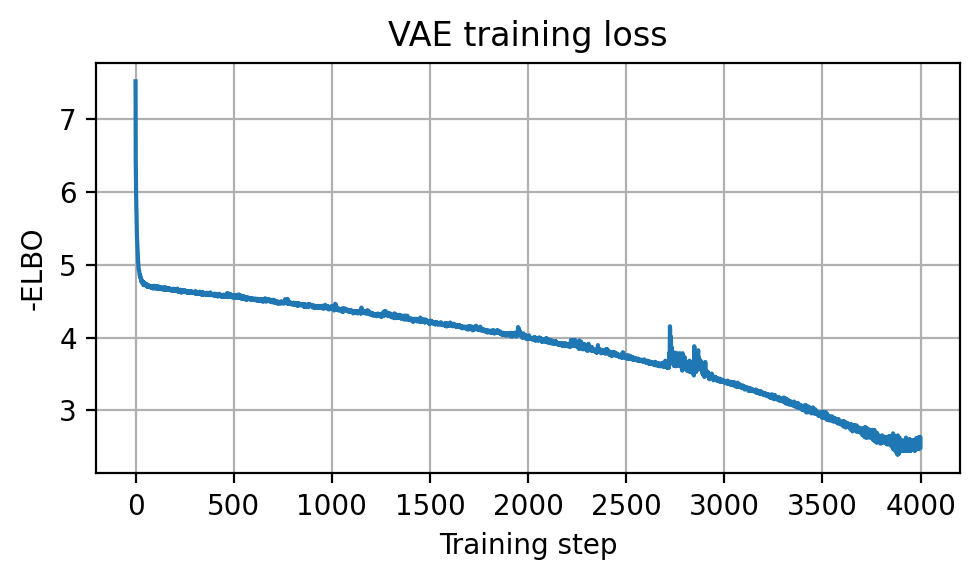

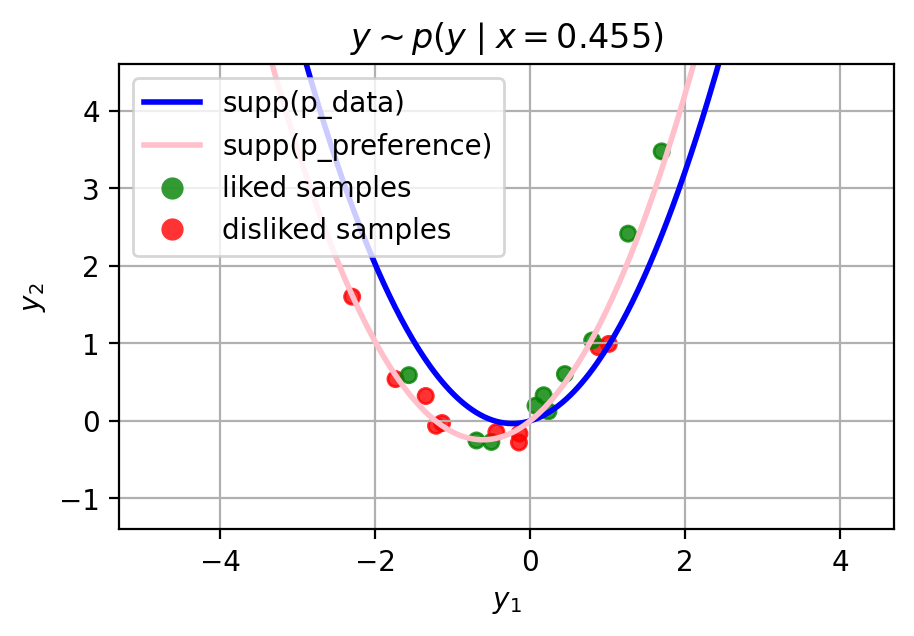

In [ ]:
# Step 1: Pre-training
#opt = optax.adam(pre_train_lr)
opt = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.adam(pre_train_lr),
)
opt_state = opt.init(vae_params)

loss_history = []

for step in range(pre_train_epochs):
    key, subkey = jax.random.split(key)
    vae_params, opt_state, loss = pre_train_step(
        vae_params, step, opt_state, subkey, xs[:,0], ys[:,0]
    )
    loss_val = float(loss)          # convert from JAX scalar
    loss_history.append(loss_val)

    print(f"[{step+1}/{pre_train_epochs}] -ELBO = {loss_val}")

logger.log_data(vae_params, Path("final") / "vae_params.npz")

# Plot loss
fig = plt.figure(figsize=(5, 3), dpi=200)
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("-ELBO")
plt.title("VAE training loss")
plt.grid(True)
plt.tight_layout()
plt.show()
logger.log_data(fig, Path("final") / "samples.png")

ys = sample_many(vae_params, ys_key, xs[:,0], m)

u = utility_vmapped(
    xs,
    ys,
    target_p.alpha,
    target_p.beta,
    target_p.gamma,
)

mean_u = jnp.mean(u)
gt_u_history.append(mean_u)

logits = logpdf_labels(
    xs,
    ys,
    alpha=target_p.alpha,
    beta=target_p.beta,
    gamma=target_p.gamma,
    tau=tau,
)

labels = jax.random.categorical(
    l_key,
    logits,
    axis=-1,
)

l_history.append(labels)   # labels used for queries

fig = task_vis.visualize(
    xs[0, 0, 0],
    ys[0],
    base_manifold=base_p,
    target_manifold=target_p,
    labels=labels[0],
    scale="free"
)
logger.log_data(fig, Path("final") / "samples.png")

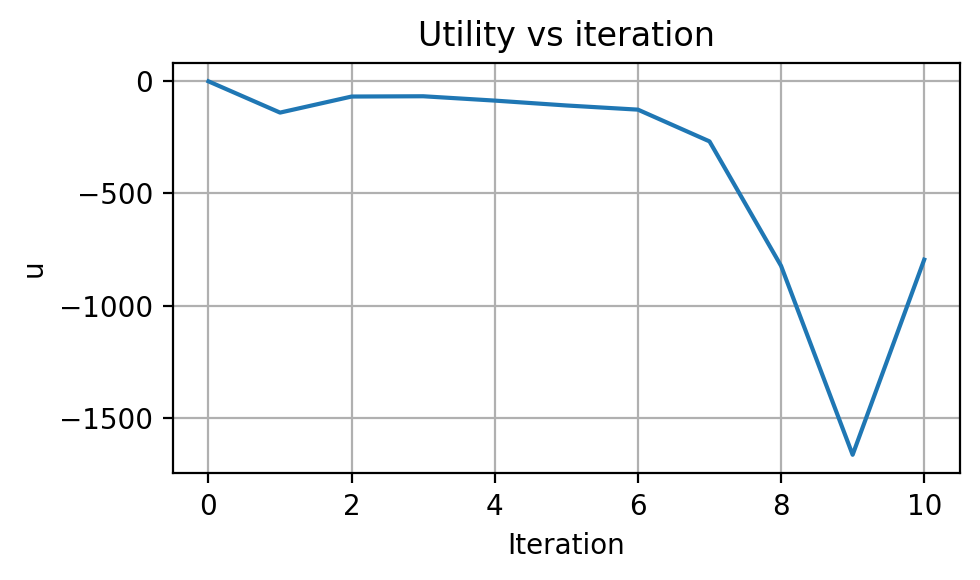

In [ ]:
fig = plt.figure(figsize=(5, 3), dpi=200)
plt.plot(gt_u_history)
plt.xlabel("Iteration")
plt.ylabel("u")
plt.title("Utility vs iteration")
plt.grid(True)
plt.tight_layout()
plt.show()
logger.log_data(fig, "gt_u_vs_iter.png")